 #  **Practica 06: Análisis de Dataset DonorsChoose, Visualización con Python y Jupiter Notebook**


* **Programa de Estudios:** Ingeniería en Desarrollo y Gestión de Software
* **Asignatura:** Extracción de Conocimiento en Bases de Datos
* **Profesor:** M.T.I. Marco Antonio Ramírez Hernández
* **Periodo:** Mayo - Agosto 2026

## **Unidad 2: Preparación de los datos**

* **Nombre del Estudiante**  Karen Lizbeth Negrete Hernandez
* **Matricula**  230570
* **Grado y Grupo**  9B IDGS


# **Análisis en Profundidad y Visualizaciones: DonorsChoose**
## **Acerca de DonorsChoose.org**

DonorsChoose.org es una organización sin fines de lucro con sede en los Estados Unidos que permite a las personas donar directamente a proyectos de aulas de escuelas públicas. Fundada en el año 2000 por el exdocente de escuela pública Charles Best, DonorsChoose.org fue una de las primeras plataformas de financiamiento colectivo (crowdfunding) de carácter cívico.

La organización ha recibido la calificación más alta de Charity Navigator cada año desde 2005. En enero de 2018, anunció que se había financiado más de 1 millón de proyectos. En el 77 % de las escuelas públicas de Estados Unidos, al menos un proyecto ha sido publicado en DonorsChoose.org.

Las escuelas ubicadas en zonas con mayores recursos económicos tienden a solicitar más proyectos relacionados con tecnología, mientras que las escuelas de comunidades menos favorecidas suelen solicitar suministros básicos. Además, se ha observado que los donantes recurrentes de DonorsChoose generalmente contribuyen a proyectos con los que no tienen una relación previa y, con mayor frecuencia, apoyan iniciativas destinadas a estudiantes con dificultades económicas.

## **Ciencia de Datos para el Bien Social: DonorsChoose**

DonorsChoose.org ha financiado más de 1,1 millones de solicitudes de aulas escolares gracias al apoyo de 3 millones de donantes, la mayoría de los cuales realizaron su primera donación a una escuela pública a través de la plataforma.

Si DonorsChoose.org logra motivar incluso a una pequeña fracción de estos donantes para que vuelvan a realizar una donación, el impacto en la cantidad de proyectos financiados podría ser enorme.

Una buena solución permitiría a DonorsChoose.org crear campañas de correo electrónico segmentadas, recomendando proyectos específicos de aulas a donantes anteriores. Parte del desafío consiste en evaluar las necesidades de la organización, descubrir información valiosa a partir de los datos disponibles y desarrollar la solución adecuada para este problema.
## **Librerías a utilizar**
Librerías instaladas:

* plotly - Visualización interactiva
* wordcloud - Nubes de palabras
* pandas - Manipulación de datos
* numpy - Operaciones numéricas
* seaborn - Gráficos estadísticos

  
**Módulos importados:**

* plotly.offline - init_notebook_mode, iplot
* wordcloud - WordCloud
* plotly.graph_objs - go
* matplotlib.pyplot - plt
* plotly - tools
* datetime - date
* pandas - pd
* numpy - np
* seaborn - sns
* random
* warnings - para filtrar alertas
* operator

# **1. Instalar las librerías necesarias para realizar el EDA**
Preparación del entorno con las dependencias requeridas para trabajar con el conjunto de datos.

Comenzamos por importar las librerías que nos permitirán manipular los datos del dataset extraídos de una fuente de datos.

In [1]:
# ==========================================
# Instalación de librerías
# ==========================================

!pip install -U plotly
!pip install wordcloud
!pip install folium
!pip install pyarrow

# ==========================================
# Importaciones
# ==========================================

import nltk
nltk.download("stopwords", quiet=True)

from plotly.offline import init_notebook_mode, iplot
from wordcloud import WordCloud
import plotly.graph_objs as go
import matplotlib.pyplot as plt
from plotly import tools

from datetime import date
from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
import warnings
import operator

warnings.filterwarnings("ignore")

init_notebook_mode(connected=True)

# ==========================================
# Ruta de los datasets
# ==========================================

path = Path(r"G:\Mi unidad\Practica_06\datasets")

# ==========================================
# Verificar que existen los archivos
# ==========================================

archivos = [
    "Donors.csv",
    "Donations.csv",
    "Teachers.csv",
    "Schools.csv",
    "Projects.csv",
    "Resources.csv"
]

print("Verificando archivos...\n")

for archivo in archivos:
    ruta = path / archivo
    print(f"{archivo}: {'OK' if ruta.exists() else 'NO ENCONTRADO'}")

# ==========================================
# Cargar datasets
# ==========================================

donors_df = pd.read_csv(path / "Donors.csv")
donations_df = pd.read_csv(path / "Donations.csv")
teachers_df = pd.read_csv(path / "Teachers.csv")
schools_df = pd.read_csv(path / "Schools.csv")
projects_df = pd.read_csv(path / "Projects.csv")
resources_df = pd.read_csv(path / "Resources.csv")

print("\nDatasets cargados correctamente.")

# ==========================================
# Revisar dimensiones
# ==========================================

print("\nDimensiones de los datasets:\n")

print("Donors:", donors_df.shape)
print("Donations:", donations_df.shape)
print("Teachers:", teachers_df.shape)
print("Schools:", schools_df.shape)
print("Projects:", projects_df.shape)
print("Resources:", resources_df.shape)

# ==========================================
# Mostrar primeras filas
# ==========================================

donors_df.head(5)

Verificando archivos...

Donors.csv: OK
Donations.csv: OK
Teachers.csv: OK
Schools.csv: OK
Projects.csv: OK
Resources.csv: OK

Datasets cargados correctamente.

Dimensiones de los datasets:

Donors: (2122640, 5)
Donations: (4687884, 7)
Teachers: (402900, 3)
Schools: (72993, 9)
Projects: (1110017, 18)
Resources: (7210448, 5)


,Donor ID,Donor City,Donor State,Donor Is Teacher,Donor Zip
0,00000ce845c00cbf0686c992fc369df4,Evanston,Illinois,No,602
1,00002783bc5d108510f3f9666c8b1edd,Appomattox,other,No,245
2,00002d44003ed46b066607c5455a999a,Winton,California,Yes,953
3,00002eb25d60a09c318efbd0797bffb5,Indianapolis,Indiana,No,462
4,0000300773fe015f870914b42528541b,Paterson,New Jersey,No,075


# **2. Exploración de los donantes**
Análisis detallado de la demografía de donantes mediante visualización de conteos por estado y ciudad, comparación entre donantes docentes y no docentes, y representación geográfica interactiva mediante mapas de calor (HeatMap) y mapas de coropletas con escala de colores.

## **2.1 Resumen de los donantes**
Inspección inicial del DataFrame de donantes (head) para validar estructura de datos, columnas disponibles y primeros registros.

In [2]:
donors_df.head(5)



,Donor ID,Donor City,Donor State,Donor Is Teacher,Donor Zip
0,00000ce845c00cbf0686c992fc369df4,Evanston,Illinois,No,602
1,00002783bc5d108510f3f9666c8b1edd,Appomattox,other,No,245
2,00002d44003ed46b066607c5455a999a,Winton,California,Yes,953
3,00002eb25d60a09c318efbd0797bffb5,Indianapolis,Indiana,No,462
4,0000300773fe015f870914b42528541b,Paterson,New Jersey,No,075


## **2.2 Número de donantes por estado**
Visualización mediante mapa de coropletas (choropleth) que colorea cada estado según la cantidad total de donantes con escala de 6 colores (púrpura claro a oscuro). Incluye gráficos de barras horizontales comparando estados con máxima y mínima cantidad de donantes.

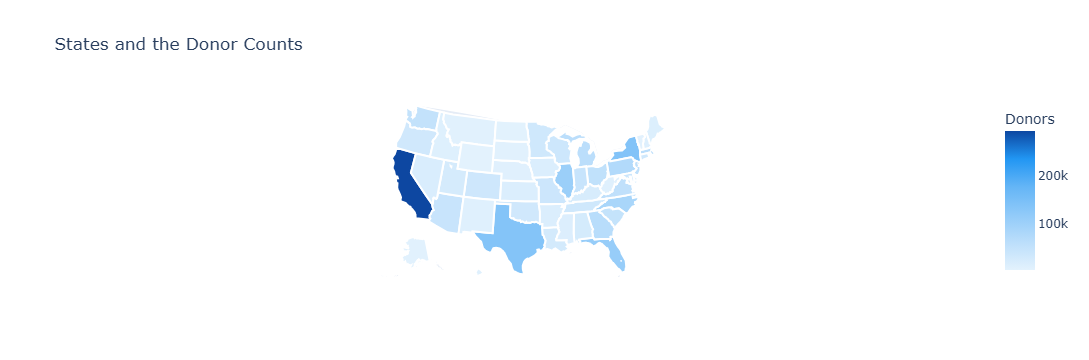

In [15]:
def bar_hor(df, col, title, color, w=None, h=None, lm=0, limit=100, return_trace=False, rev=False):
    cnt_srs = df[col].value_counts()
    yy = cnt_srs.head(limit).index[::-1]
    xx = cnt_srs.head(limit).values[::-1]
    if rev:
        yy = cnt_srs.tail(limit).index[::-1]
        xx = cnt_srs.tail(limit).values[::-1]


    trace = go.Bar(y=yy, x=xx, orientation = 'h', marker=dict(color=color))
    if return_trace:
        return trace
    layout = dict(title=title, margin=dict(l=lm), width=w, height=h)
    data = [trace]
    fig = go.Figure(data=data, layout=layout)
    iplot(fig)

def bar_hor_noagg(x, y, title, color, w=None, h=None, lm=0, limit=100, rt=False):
    trace = go.Bar(y=x, x=y, orientation = 'h', marker=dict(color=color))
    if rt:
        return trace
    layout = dict(title=title, margin=dict(l=lm), width=w, height=h)
    data = [trace]
    fig = go.Figure(data=data, layout=layout)
    iplot(fig)


def bar_ver_noagg(x, y, title, color, w=None, h=None, lm=0, rt = False):
    trace = go.Bar(y=y, x=x, marker=dict(color=color))
    if rt:
        return trace
    layout = dict(title=title, margin=dict(l=lm), width=w, height=h)
    data = [trace]
    fig = go.Figure(data=data, layout=layout)
    iplot(fig)


trace1 = bar_hor(donors_df, 'Donor City', "Top Cities with maximum Donors", '#c2d2ed', 600, 400, 200, limit = 10, return_trace=True)
trace2 = bar_hor(donors_df, 'Donor State', "Top States with maximum Donors", '#c2d2ed', 600, 400, 200, limit = 10, return_trace=True)
# trace3 = bar_hor(donors_df, 'Donor City', "Top Cities with maximum Donors", '#4fe4f9', 600, 400, 200, limit = 10, return_trace=True, rev=True)
trace4 = bar_hor(donors_df, 'Donor State', "Top States with maximum Donors", '#c2d2ed', 600, 400, 200, limit = 10, return_trace=True, rev=True)


states_df = donors_df['Donor State'].value_counts()
statesdf = pd.DataFrame()
statesdf['state'] = states_df.index
statesdf['counts'] = states_df.values


# Escala de color azul
scl = [
    [0.0, '#E3F2FD'],
    [0.2, '#BBDEFB'],
    [0.4, '#90CAF9'],
    [0.6, '#64B5F6'],
    [0.8, '#2196F3'],
    [1.0, '#0D47A1']
]
state_to_code = {'District of Columbia' : 'dc','Mississippi': 'MS', 'Oklahoma': 'OK', 'Delaware': 'DE', 'Minnesota': 'MN', 'Illinois': 'IL', 'Arkansas': 'AR', 'New Mexico': 'NM', 'Indiana': 'IN', 'Maryland': 'MD', 'Louisiana': 'LA', 'Idaho': 'ID', 'Wyoming': 'WY', 'Tennessee': 'TN', 'Arizona': 'AZ', 'Iowa': 'IA', 'Michigan': 'MI', 'Kansas': 'KS', 'Utah': 'UT', 'Virginia': 'VA', 'Oregon': 'OR', 'Connecticut': 'CT', 'Montana': 'MT', 'California': 'CA', 'Massachusetts': 'MA', 'West Virginia': 'WV', 'South Carolina': 'SC', 'New Hampshire': 'NH', 'Wisconsin': 'WI', 'Vermont': 'VT', 'Georgia': 'GA', 'North Dakota': 'ND', 'Pennsylvania': 'PA', 'Florida': 'FL', 'Alaska': 'AK', 'Kentucky': 'KY', 'Hawaii': 'HI', 'Nebraska': 'NE', 'Missouri': 'MO', 'Ohio': 'OH', 'Alabama': 'AL', 'Rhode Island': 'RI', 'South Dakota': 'SD', 'Colorado': 'CO', 'New Jersey': 'NJ', 'Washington': 'WA', 'North Carolina': 'NC', 'New York': 'NY', 'Texas': 'TX', 'Nevada': 'NV', 'Maine': 'ME'}
statesdf['state_code'] = statesdf['state'].apply(lambda x : state_to_code[x] if x in state_to_code else "")

data = [ dict(
        type='choropleth',
        colorscale = scl,
        autocolorscale = False,
        locations = statesdf['state_code'],
        z = statesdf['counts'],
        locationmode = 'USA-states',
        text = statesdf['state'],
        marker = dict(
            line = dict (
                color = 'rgb(255,255,255)',
                width = 2
            ) ),
        colorbar = dict(
            title = "Donors")
        ) ]

layout = dict(
        title = 'States and the Donor Counts',
        geo = dict(
            scope='usa',
            projection=dict( type='albers usa' ),
            showlakes = True,
            lakecolor = 'rgb(255, 255, 255)'),
             )

fig = dict( data=data, layout=layout )
iplot( fig, filename='d3-cloropleth-map' )



## **2.3 Estados y ciudades con mayor número de donantes**
Layout de 4 gráficos de barras que muestra: top 10 estados con máxima cantidad de donantes, top 10 estados con mínima cantidad y top 10 ciudades con mayor concentración de donantes en el país.

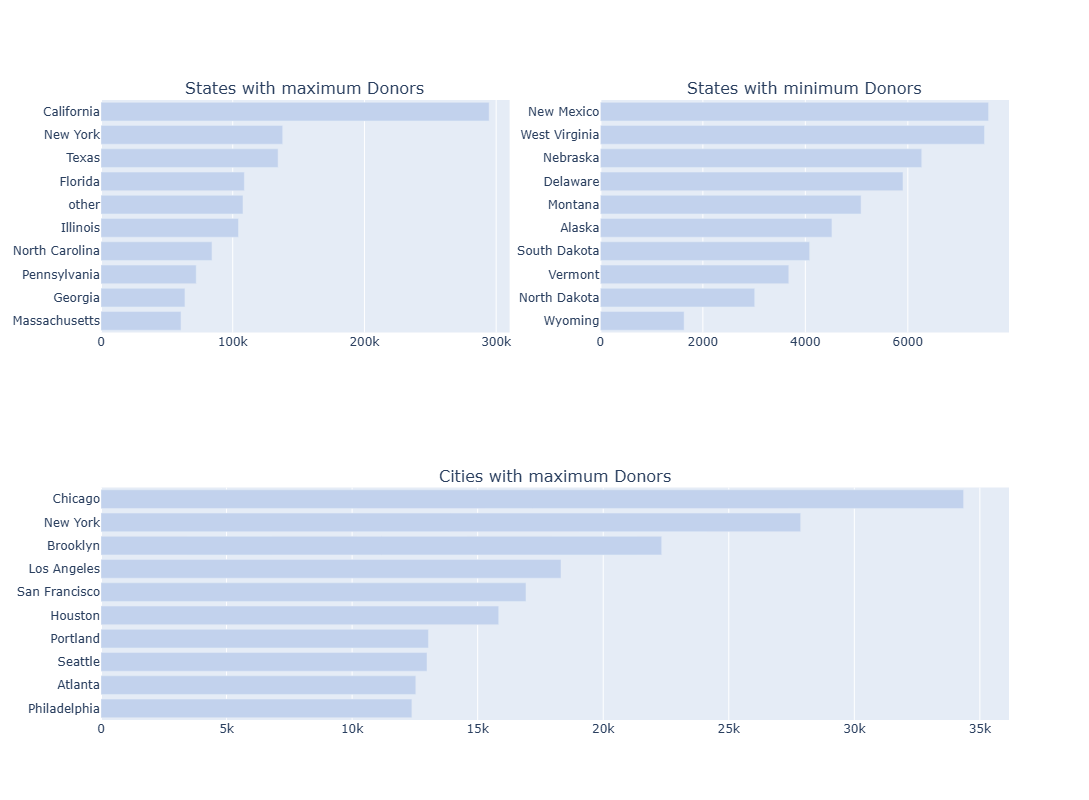

In [4]:
fig = tools.make_subplots(rows=2, cols=2, specs=[[{}, {}], [{'colspan': 2}, None]], print_grid=False, subplot_titles = ['States with maximum Donors','States with minimum Donors', 'Cities with maximum Donors'])
fig.append_trace(trace2, 1, 1);
fig.append_trace(trace4, 1, 2);
fig.append_trace(trace1, 2, 1);
# fig.append_trace(trace4, 2, 2);

fig['layout'].update(height=800, showlegend=False);
iplot(fig);


## **2.4 Donantes docentes y no docentes por estado**
Gráfico de barras agrupado que compara la distribución de donantes identificados como maestros vs. no maestros en cada estado, permitiendo visualizar en qué regiones hay mayor participación de docentes como donantes.

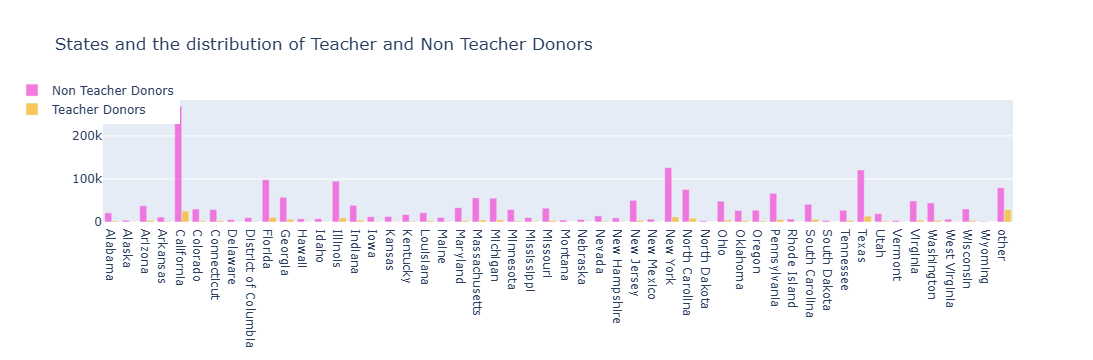

In [5]:
# which city and state has maximum teacher donors
tempdf = donors_df.groupby(['Donor State', 'Donor Is Teacher']).agg({'Donor Is Teacher' : 'count' }).rename(columns={'Donor Is Teacher' : 'Teacher Donor Counts'}).reset_index()

no_df = tempdf[tempdf['Donor Is Teacher']=='No']
no_x = no_df['Donor State']
no_y = no_df['Teacher Donor Counts']
yes_df = tempdf[tempdf['Donor Is Teacher']=='Yes']
yes_x = yes_df['Donor State']
yes_y = yes_df['Teacher Donor Counts']

trace1 = go.Bar(
    x=no_x,
    y=no_y,
    name='Non Teacher Donors',
    marker=dict(color='#f259d6'),
    opacity=0.8
)
trace2 = go.Bar(
    x=yes_x,
    y=yes_y,
    name='Teacher Donors',
    marker=dict(color='#f7bb31'),
    opacity=0.8
)

data = [trace1, trace2]
layout = go.Layout(
    barmode='group',
    legend=dict(dict(x=-.1, y=1.2)),
    title = 'States and the distribution of Teacher and Non Teacher Donors',
)

fig = go.Figure(data=data, layout=layout)
iplot(fig, filename='grouped-bar')

## **2.5 Visualización de la ubicación de los donantes**
Mapas interactivos de calor (HeatMap usando Folium) que muestran la densidad y concentración de donantes en diferentes regiones del país. Los mapas se centran en coordenadas específicas y utilizan un sistema de capas para visualizar intensidad de donantes.

### **2.5.1 Donantes de California**
Mapa de calor interactivo centrado en California mostrando la concentración de donantes por ciudad. Los datos se cargan desde un CSV con coordenadas geográficas y se utiliza un HeatMap con radio personalizado para visualizar hotspots de donantes.

In [6]:
from io import StringIO
import folium

calcit = StringIO(u"""Name,Latitude,Longitude,Total Donors,Color,Size
Los Angeles,34.052233,-118.243686,"17,922.000000",#0061ff,10
San Francisco,37.774931,-122.419417,"16,553.000000",#0061ff,10
San Diego,32.715328,-117.157256,"9,072.000000",#0061ff,10
San Jose,37.339386,-121.894956,"7,674.000000",#0061ff,10
Oakland,37.804364,-122.271114,"6,783.000000",#0061ff,10
Sacramento,38.581572,-121.494400,"4,701.000000",#0061ff,10
Bakersfield,35.373292,-119.018711,"3,758.000000",#0061ff,10
Long Beach,33.768322,-118.195617,"3,120.000000",#0061ff,10
Berkeley,37.871592,-122.272747,"2,898.000000",#0061ff,10
Irvine,33.683947,-117.794694,"2,765.000000",#0061ff,10
Fremont,37.548269,-121.988572,"2,716.000000",#0061ff,10
Walnut Creek,37.910078,-122.065183,"2,255.000000",#0061ff,10
Huntington Beach,33.660297,-117.999225,"2,185.000000",#0061ff,10
Murrieta,33.553914,-117.213922,"1,982.000000",#0061ff,10
Pleasanton,37.662431,-121.874678,"1,970.000000",#0061ff,10
Torrance,33.83585,-118.340628,"1,957.000000",#0061ff,10
San Mateo,37.562992,-122.325525,"1,956.000000",#0061ff,10
Santa Monica,34.019453,-118.491192,"1,780.000000",#0061ff,10
Livermore,37.681875,-121.768008,"1,776.000000",#0061ff,10
Santa Rosa,38.440467,-122.714431,"1,752.000000",#0061ff,10
Concord,37.977978,-122.031072,"1,623.000000",#0061ff,10
Alameda,37.765206,-122.241636,"1,548.000000",#0061ff,10
Fresno,36.746842,-119.772586,"1,543.000000",#0061ff,10
San Ramon,37.779928,-121.978014,"1,533.000000",#0061ff,10
Anaheim,33.835292,-117.914503,"1,475.000000",#0061ff,10
Pasadena,34.147786,-118.144517,"1,429.000000",#0061ff,10
Glendale,34.142508,-118.255075,"1,427.000000",#0061ff,10
Riverside,33.95335,-117.396156,"1,425.000000",#0061ff,10
Sunnyvale,37.368831,-122.036350,"1,406.000000",#0061ff,10
Chula Vista,32.640053,-117.084197,"1,398.000000",#0061ff,10
Mountain View,37.386053,-122.083850,"1,398.000000",#0061ff,10
Elk Grove,38.4088,-121.371617,"1,397.000000",#0061ff,10
Santa Clarita,34.391664,-118.542586,"1,382.000000",#0061ff,10
Burbank,34.180839,-118.308967,"1,357.000000",#0061ff,10
Redwood City,37.485214,-122.236356,"1,323.000000",#0061ff,10
Chico,39.728494,-121.837478,"1,322.000000",#0061ff,10
Whittier,33.979178,-118.032844,"1,280.000000",#0061ff,10
Corona,33.875294,-117.566439,"1,239.000000",#0061ff,10
Santa Clara,37.354108,-121.955236,"1,233.000000",#0061ff,10
Orange,33.787794,-117.853111,"1,229.000000",#0061ff,10
Palo Alto,37.441883,-122.143019,"1,219.000000",#0061ff,10
Hayward,37.668819,-122.080797,"1,162.000000",#0061ff,10
Oceanside,33.195869,-117.379483,"1,157.000000",#0061ff,10
Fullerton,33.870292,-117.925339,"1,151.000000",#0061ff,10
San Rafael,37.973536,-122.531086,"1,136.000000",#0061ff,10
Folsom,38.677958,-121.176058,"1,125.000000",#0061ff,10
Simi Valley,34.269447,-118.781483,"1,069.000000",#0061ff,10
Escondido,33.119208,-117.086422,"1,062.000000",#0061ff,10
Santa Ana,33.745572,-117.867833,"1,054.000000",#0061ff,10
Redondo Beach,33.849183,-118.388408,"1,048.000000",#34ef6c,8
Stockton,37.957703,-121.290781,"1,041.000000",#34ef6c,8
Santa Cruz,36.974117,-122.030797,"1,029.000000",#34ef6c,8
Culver City,34.021122,-118.396467,"1,019.000000",#34ef6c,8
Salinas,36.677736,-121.655500,"1,017.000000",#34ef6c,8
Martinez,38.019367,-122.134133,975.000000,#34ef6c,8
Santa Barbara,34.420831,-119.698189,936.000000,#34ef6c,8
San Leandro,37.724931,-122.156078,929.000000,#34ef6c,8
Ventura,34.274639,-119.229006,922.000000,#34ef6c,8
Roseville,38.752122,-121.288006,888.000000,#34ef6c,8
Yorba Linda,33.888625,-117.813111,888.000000,#34ef6c,8
Costa Mesa,33.641133,-117.918669,887.000000,#34ef6c,8
San Marcos,33.143372,-117.166144,866.000000,#34ef6c,8
Brentwood,34.057361,-118.480511,853.000000,#34ef6c,8
South San Francisco,37.654656,-122.407750,841.000000,#34ef6c,8
Modesto,37.639097,-120.996878,837.000000,#34ef6c,8
Temecula,33.493639,-117.148364,837.000000,#34ef6c,8
Novato,38.107419,-122.569703,831.000000,#34ef6c,8
Carlsbad,33.158092,-117.350594,822.000000,#34ef6c,8
Mission Viejo,33.600022,-117.671994,817.000000,#34ef6c,8
Brea,33.916681,-117.900061,802.000000,#34ef6c,8
Garden Grove,33.773906,-117.941447,792.000000,#34ef6c,8
Dublin,37.702153,-121.935792,784.000000,#34ef6c,8
El Cajon,32.794772,-116.962528,783.000000,#34ef6c,8
Menlo Park,37.453828,-122.182186,768.000000,#34ef6c,8
Fairfield,38.249358,-122.039967,751.000000,#34ef6c,8
Pleasant Hill,37.947978,-122.060797,725.000000,#34ef6c,8
Napa,38.297539,-122.286864,711.000000,#34ef6c,8
Richmond,37.935758,-122.347750,707.000000,#34ef6c,8
Los Altos,33.796331,-118.118119,703.000000,#34ef6c,8
Daly City,37.687925,-122.470208,702.000000,#34ef6c,8
West Covina,34.068622,-117.938953,688.000000,#34ef6c,8
Lafayette,37.885758,-122.118019,660.000000,#34ef6c,8
La Mesa,32.767828,-117.023083,649.000000,#34ef6c,8
Milpitas,37.428272,-121.906625,649.000000,#34ef6c,8
Carson,33.831406,-118.282017,647.000000,#34ef6c,8
Camarillo,34.216394,-119.037603,643.000000,#34ef6c,8
Petaluma,38.232417,-122.636653,629.000000,#34ef6c,8
Newport Beach,33.618911,-117.928947,626.000000,#34ef6c,8
Pacifica,37.613825,-122.486919,619.000000,#34ef6c,8
Gilroy,37.005783,-121.568275,618.000000,#34ef6c,8
Encinitas,33.036986,-117.291983,607.000000,#34ef6c,8
El Segundo,33.919181,-118.416464,595.000000,#34ef6c,8
Downey,33.940014,-118.132569,592.000000,#34ef6c,8
Rancho Palos Verdes,33.744461,-118.387017,592.000000,#34ef6c,8
San Clemente,33.426972,-117.611992,589.000000,#34ef6c,8
Vacaville,38.356578,-121.987744,584.000000,#34ef6c,8
Chino Hills,33.989819,-117.732586,583.000000,#34ef6c,8
Campbell,37.287164,-121.949958,580.000000,#34ef6c,8
Mill Valley,37.906036,-122.544975,578.000000,#34ef6c,8
El Cerrito,37.916133,-122.310764,576.000000,#f2ae93,6
Emeryville,37.831317,-122.285247,572.000000,#f2ae93,6
Thousand Oaks,34.107231,-118.057847,572.000000,#f2ae93,6
Burlingame,37.584103,-122.366083,570.000000,#f2ae93,6
Antioch,38.004922,-121.805789,568.000000,#f2ae93,6
Beverly Hills,34.073619,-118.400356,568.000000,#f2ae93,6
Lakewood,33.853628,-118.133956,560.000000,#f2ae93,6
Manhattan Beach,33.884736,-118.410908,557.000000,#f2ae93,6
Lancaster,34.686786,-118.154164,551.000000,#f2ae93,6
Oxnard,34.197506,-119.177053,539.000000,#f2ae93,6
San Carlos,37.507158,-122.260522,527.000000,#f2ae93,6
Rocklin,38.790733,-121.235783,526.000000,#f2ae93,6
Placentia,33.872236,-117.870336,520.000000,#f2ae93,6
Cupertino,37.322997,-122.032183,516.000000,#f2ae93,6
Tustin,33.74585,-117.826167,508.000000,#f2ae93,6
Hermosa Beach,33.862236,-118.399519,507.000000,#f2ae93,6
Rancho Cordova,38.589072,-121.302728,501.000000,#f2ae93,6
Fountain Valley,33.709186,-117.953669,498.000000,#f2ae93,6
Cypress,37.320531,-121.962242,497.000000,#f2ae93,6
Union City,37.593392,-122.043831,494.000000,#f2ae93,6
Morgan Hill,37.1305,-121.654389,488.000000,#f2ae93,6
Vallejo,38.104086,-122.256636,485.000000,#f2ae93,6
Alhambra,34.095286,-118.127014,474.000000,#f2ae93,6
Lake Forest,33.646967,-117.689217,465.000000,#f2ae93,6
Rancho Cucamonga,34.1064,-117.593108,463.000000,#f2ae93,6
Vista,33.200036,-117.242536,463.000000,#f2ae93,6
Fontana,34.092233,-117.435047,459.000000,#f2ae93,6
Moreno Valley,33.942467,-117.229672,455.000000,#f2ae93,6
Hawthorne,33.916403,-118.352575,450.000000,#f2ae93,6
Covina,34.090008,-117.890339,443.000000,#f2ae93,6
San Luis Obispo,35.282753,-120.659617,434.000000,#f2ae93,6
Newark,37.529658,-122.040239,433.000000,#f2ae93,6
Inglewood,33.961681,-118.353131,432.000000,#f2ae93,6
Oakley,37.997422,-121.712453,430.000000,#f2ae93,6
Tracy,37.73965,-121.425222,428.000000,#f2ae93,6
Redding,40.586539,-122.391675,424.000000,#f2ae93,6
Glendora,34.136119,-117.865339,423.000000,#f2ae93,6
San Bruno,37.630489,-122.411083,423.000000,#f2ae93,6
Davis,38.544906,-121.740517,417.000000,#f2ae93,6
Westminster,33.751342,-117.993992,413.000000,#f2ae93,6
Pittsburg,38.027975,-121.884681,412.000000,#f2ae93,6
Palmdale,34.579433,-118.116461,408.000000,#f2ae93,6
Visalia,36.330228,-119.292058,406.000000,#f2ae93,6
Poway,32.962822,-117.035864,403.000000,#f2ae93,6
Santa Maria,34.953033,-120.435719,403.000000,#f2ae93,6
Upland,34.097511,-117.648389,396.000000,#f2ae93,6
Laguna Niguel,33.522525,-117.707553,393.000000,#f2ae93,6
La Mirada,33.917236,-118.012008,392.000000,#f2ae93,6
South Pasadena,34.116119,-118.150350,391.000000,#f2ae93,6
Cerritos,33.858347,-118.064786,383.000000,#f2ae93,6
Lodi,38.134147,-121.272219,380.000000,#f2ae93,6
Ontario,34.063344,-117.650889,380.000000,#bab7b6,4
Lincoln,38.891564,-121.293008,376.000000,#bab7b6,4
Buena Park,33.867514,-117.998117,375.000000,#bab7b6,4
Rancho Santa Margarita,33.640856,-117.603103,373.000000,#bab7b6,4
Santee,32.838383,-116.973917,373.000000,#bab7b6,4
Sonoma,38.291858,-122.458036,372.000000,#bab7b6,4
Monrovia,34.144428,-118.001947,371.000000,#bab7b6,4
Albany,37.886869,-122.297747,368.000000,#bab7b6,4
La Habra,33.931958,-117.946172,366.000000,#bab7b6,4
San Pablo,37.962147,-122.345525,366.000000,#bab7b6,4
Belmont,37.520214,-122.275800,364.000000,#bab7b6,4
Pomona,34.055228,-117.752306,364.000000,#bab7b6,4
Gardena,33.88835,-118.308961,363.000000,#bab7b6,4
Arcadia,34.139728,-118.035344,361.000000,#bab7b6,4
Clovis,36.825228,-119.702919,360.000000,#bab7b6,4
Orinda,37.877147,-122.179689,358.000000,#bab7b6,4
Manteca,37.797428,-121.216053,357.000000,#bab7b6,4
Citrus Heights,38.707125,-121.281061,355.000000,#bab7b6,4
Redlands,34.055569,-117.182539,353.000000,#bab7b6,4
Aliso Viejo,33.575,-117.725556,345.000000,#bab7b6,4
Eureka,40.802072,-124.163672,338.000000,#bab7b6,4
West Hollywood,34.090008,-118.361744,337.000000,#bab7b6,4
Auburn,38.896564,-121.076889,335.000000,#bab7b6,4
Saratoga,37.263833,-122.023014,331.000000,#bab7b6,4
Turlock,37.494658,-120.846594,327.000000,#bab7b6,4
Chino,34.012236,-117.688944,325.000000,#bab7b6,4
Diamond Bar,34.028622,-117.810336,324.000000,#bab7b6,4
South Gate,33.954736,-118.212017,319.000000,#bab7b6,4
San Bernardino,34.108344,-117.289764,318.000000,#bab7b6,4
Claremont,34.096675,-117.719778,316.000000,#bab7b6,4
Calabasas,34.138333,-118.660833,298.000000,#bab7b6,4
Los Alamitos,33.803072,-118.072564,297.000000,#bab7b6,4
Agoura Hills,34.153339,-118.761675,295.000000,#bab7b6,4
San Gabriel,34.096111,-118.105833,295.000000,#bab7b6,4
Paso Robles,35.632278,-120.664186,292.000000,#bab7b6,4
Norwalk,33.902236,-118.081733,286.000000,#bab7b6,4
Indio,33.720578,-116.215561,284.000000,#bab7b6,4
Moorpark,34.144897,-118.268742,284.000000,#bab7b6,4
Monterey,36.600239,-121.894675,275.000000,#bab7b6,4
Arroyo Grande,35.118586,-120.590725,274.000000,#bab7b6,4
San Dimas,34.106675,-117.806725,274.000000,#bab7b6,4
La Puente,34.020011,-117.949508,273.000000,#bab7b6,4
West Sacramento,38.580461,-121.530233,273.000000,#bab7b6,4
Rohnert Park,38.339636,-122.701097,269.000000,#bab7b6,4
Monterey Park,34.062511,-118.122847,266.000000,#bab7b6,4
Laguna Hills,33.599722,-117.699444,260.000000,#bab7b6,4
Watsonville,36.910231,-121.756894,259.000000,#bab7b6,4
Clayton,37.941033,-121.935792,256.000000,#bab7b6,4
Hemet,33.747519,-116.971967,256.000000,#bab7b6,4
La Verne,34.100842,-117.767836,255.000000,#bab7b6,4
Ukiah,39.150172,-123.207783,255.000000,#f477d7,2
Palm Desert,33.722244,-116.374456,251.000000,#f477d7,2
Atascadero,35.489417,-120.670725,241.000000,#f477d7,2
Menifee,33.678333,-117.166944,241.000000,#f477d7,2
Lompoc,34.63915,-120.457942,240.000000,#f477d7,2
Merced,37.302164,-120.482967,240.000000,#f477d7,2
Sebastopol,38.402136,-122.823881,237.000000,#f477d7,2
Lake Elsinore,33.668078,-117.327261,236.000000,#f477d7,2
Millbrae,37.598547,-122.387194,234.000000,#f477d7,2
Yuba City,39.140447,-121.616911,231.000000,#f477d7,2
Woodland,38.678517,-121.773297,228.000000,#f477d7,2
Bellflower,33.881683,-118.117011,227.000000,#f477d7,2
Grass Valley,39.219061,-121.061061,227.000000,#f477d7,2
Seal Beach,33.741406,-118.104786,227.000000,#f477d7,2
Walnut,34.020289,-117.865339,227.000000,#f477d7,2
Montebello,34.016506,-118.113753,225.000000,#f477d7,2
Yucaipa,34.033625,-117.043086,225.000000,#f477d7,2
Hanford,36.32745,-119.645683,224.000000,#f477d7,2
Goleta,34.435828,-119.827639,221.000000,#f477d7,2
Hesperia,34.426389,-117.300878,221.000000,#f477d7,2
Laguna Beach,33.542247,-117.783111,221.000000,#f477d7,2
Ridgecrest,35.622456,-117.670897,218.000000,#f477d7,2
Galt,38.254636,-121.299947,217.000000,#f477d7,2
Victorville,34.536108,-117.291158,217.000000,#f477d7,2
San Juan Capistrano,33.501692,-117.662550,209.000000,#f477d7,2
Atwater,37.347717,-120.609083,208.000000,#f477d7,2
Palm Springs,33.830297,-116.545292,208.000000,#f477d7,2
Azusa,34.133619,-117.907564,203.000000,#f477d7,2
Hercules,38.017144,-122.288581,202.000000,#f477d7,2
Sonora,37.984092,-120.382139,199.000000,#f477d7,2
Beaumont,33.929461,-116.977247,198.000000,#f477d7,2
Half Moon Bay,37.463553,-122.428586,197.000000,#f477d7,2
Hollister,36.852453,-121.401603,196.000000,#f477d7,2
Westlake Village,34.145839,-118.805647,194.000000,#f477d7,2
Pico Rivera,33.983069,-118.096736,190.000000,#f477d7,2
Pinole,38.004367,-122.298858,186.000000,#f477d7,2
Compton,33.89585,-118.220072,185.000000,#f477d7,2
Sausalito,37.859094,-122.485250,183.000000,#f477d7,2
La Quinta,33.646692,-116.310008,181.000000,#f477d7,2
Dana Point,33.466972,-117.698108,175.000000,#f477d7,2
Rialto,34.1064,-117.370325,172.000000,#f477d7,2
Perris,33.782519,-117.228647,171.000000,#f477d7,2
Arcata,40.866517,-124.082839,168.000000,#f477d7,2
Pacific Grove,36.617736,-121.916622,168.000000,#f477d7,2
Lomita,33.792239,-118.315072,167.000000,#f477d7,2
San Fernando,34.281947,-118.438972,165.000000,#f477d7,2
South Lake Tahoe,38.939925,-119.977186,163.000000,#f477d7,2
El Monte,34.068622,-118.027567,158.000000,#f477d7,2
Scotts Valley,37.051061,-122.014683,158.000000,#f477d7,2
Tehachapi,35.132189,-118.448975,157.000000,#f477d7,2
Baldwin Park,34.085286,-117.960897,156.000000,#f477d7,2
Marina,36.684403,-121.802172,155.000000,#f477d7,2
Rosemead,34.080564,-118.072847,155.000000,#f477d7,2
Placerville,38.729625,-120.798547,151.000000,#f477d7,2
Highland,34.128344,-117.208650,148.000000,#f477d7,2
Lawndale,33.887236,-118.352575,143.000000,#f477d7,2
Oroville,39.513775,-121.556358,142.000000,#f477d7,2
Seaside,33.819361,-118.366647,142.000000,#f477d7,2
Wildomar,33.598914,-117.280036,142.000000,#f477d7,2
Duarte,34.13945,-117.977286,141.000000,#f477d7,2
Huntington Park,33.981681,-118.225072,141.000000,#f477d7,2
Larkspur,37.934092,-122.535253,139.000000,#f477d7,2
Del Mar,32.959489,-117.265314,138.000000,#f477d7,2
Winters,38.524906,-121.970803,138.000000,#f477d7,2
Red Bluff,40.178489,-122.235831,137.000000,#f477d7,2
Cathedral City,33.779742,-116.465292,136.000000,#f9e84a,1
Ojai,34.44805,-119.242889,136.000000,#f9e84a,1
Coronado,32.685886,-117.183089,134.000000,#f9e84a,1
Lynwood,33.930292,-118.211461,134.000000,#f9e84a,1
Temple City,34.107231,-118.057847,132.000000,#f9e84a,1
Bell,33.977514,-118.187017,124.000000,#f9e84a,1
Sierra Madre,34.161672,-118.052847,119.000000,#f9e84a,1
Nevada City,39.261561,-121.016058,118.000000,#f9e84a,1
National City,32.678108,-117.099197,117.000000,#f9e84a,1
Ceres,37.594933,-120.957711,116.000000,#f9e84a,1
Solana Beach,32.991156,-117.271147,115.000000,#f9e84a,1
La Palma,33.846403,-118.046731,114.000000,#f9e84a,1
Healdsburg,38.610467,-122.869161,110.000000,#f9e84a,1
Ripon,37.739453,-121.135414,109.000000,#f9e84a,1
Crescent City,41.755947,-124.201747,108.000000,#f9e84a,1
Malibu,34.005008,-118.810172,108.000000,#f9e84a,1
Patterson,37.4716,-121.129656,107.000000,#f9e84a,1
Maywood,33.986681,-118.185350,105.000000,#f9e84a,1
Suisun City,38.238247,-122.040244,105.000000,#f9e84a,1
Dixon,38.445464,-121.823297,104.000000,#f9e84a,1
Fort Bragg,39.445722,-123.805292,103.000000,#f9e84a,1
Oakdale,37.766594,-120.847153,103.000000,#f9e84a,1
American Canyon,38.174917,-122.260803,100.000000,#f9e84a,1
Lemon Grove,32.742553,-117.031417,97.000000,#f9e84a,1
Carpinteria,34.398883,-119.518456,96.000000,#f9e84a,1
Lemoore,36.300783,-119.782911,96.000000,#f9e84a,1
San Jacinto,33.783908,-116.958636,95.000000,#f9e84a,1
San Marino,34.121397,-118.106458,95.000000,#f9e84a,1
Paramount,33.889461,-118.159792,94.000000,#f9e84a,1
Tulare,36.207728,-119.347339,93.000000,#f9e84a,1
Twentynine Palms,34.135558,-116.054169,92.000000,#f9e84a,1
Shafter,35.500514,-119.271775,91.000000,#f9e84a,1
Norco,33.931125,-117.548661,89.000000,#f9e84a,1
Capitola,36.975228,-121.953292,88.000000,#f9e84a,1
Rio Vista,38.15575,-121.691344,88.000000,#f9e84a,1
Colton,34.073903,-117.313656,86.000000,#f9e84a,1
Brisbane,37.680767,-122.399972,85.000000,#f9e84a,1
Taft,35.142467,-119.456508,85.000000,#f9e84a,1
Imperial Beach,32.583944,-117.113086,84.000000,#f9e84a,1
Kingsburg,36.513839,-119.554017,84.000000,#f9e84a,1
Morro Bay,35.365808,-120.849900,83.000000,#f9e84a,1
Santa Fe Springs,33.947236,-118.085344,83.000000,#f9e84a,1
Rancho Mirage,33.739744,-116.412789,78.000000,#f9e84a,1
Stanton,33.802517,-117.993117,78.000000,#f9e84a,1
Madera,36.961336,-120.060717,77.000000,#f9e84a,1
Los Banos,37.058278,-120.849914,76.000000,#f9e84a,1
Riverbank,37.736039,-120.935489,76.000000,#f9e84a,1
Gridley,39.363778,-121.693583,75.000000,#f9e84a,1
Pismo Beach,35.142753,-120.641283,74.000000,#f9e84a,1
Santa Paula,34.354167,-119.059269,74.000000,#f9e84a,1
Cotati,38.327778,-122.709167,73.000000,#f9e84a,1
Port Hueneme,34.180728,-119.208158,73.000000,#f9e84a,1
Selma,36.570783,-119.612075,73.000000,#f9e84a,1
Banning,33.925572,-116.876411,71.000000,#f9e84a,1
King City,36.212744,-121.126028,71.000000,#f9e84a,1
El Centro,32.792,-115.563050,69.000000,#f9e84a,1
Lakeport,39.04295,-122.915828,69.000000,#f9e84a,1
Willits,39.409608,-123.355567,68.000000,#f9e84a,1
Barstow,34.895797,-117.017283,67.000000,#f9e84a,1
Marysville,39.145725,-121.591356,67.000000,#f9e84a,1
Orland,39.747381,-122.196375,66.000000,#f9e84a,1
Grand Terrace,34.033903,-117.313653,63.000000,#f9e84a,1
Montclair,34.077511,-117.689778,63.000000,#f9e84a,1
Villa Park,33.814461,-117.813111,63.000000,#f9e84a,1
Artesia,33.865847,-118.083122,62.000000,#f9e84a,1
Desert Hot Springs,33.961125,-116.501678,61.000000,#f9e84a,1
Fortuna,40.598186,-124.157275,61.000000,#f9e84a,1
Grover Beach,35.121642,-120.621283,61.000000,#f9e84a,1
Loma Linda,34.048347,-117.261153,59.000000,#f9e84a,1
Dinuba,36.543283,-119.387067,58.000000,#f9e84a,1
South El Monte,34.051956,-118.046733,58.000000,#f9e84a,1
Porterville,36.065231,-119.016767,57.000000,#f9e84a,1
Lathrop,37.822706,-121.276611,56.000000,#f9e84a,1
Coalinga,36.139678,-120.360150,55.000000,#f9e84a,1
Fillmore,34.399164,-118.918153,54.000000,#f9e84a,1
Mount Shasta,41.410806,-122.194575,52.000000,#f9e84a,1
Anderson,40.448208,-122.297783,51.000000,#f9e84a,1
Cloverdale,38.805461,-123.017222,50.000000,#f9e84a,1
Exeter,36.296061,-119.142053,50.000000,#f9e84a,1
Wasco,35.594125,-119.340947,50.000000,#f9e84a,1
Reedley,36.596339,-119.450403,47.000000,#f9e84a,1
Sanger,36.708006,-119.555964,47.000000,#f9e84a,1
Adelanto,34.582769,-117.409214,45.000000,#f9e84a,1
Brawley,32.978658,-115.530267,43.000000,#f9e84a,1
Calimesa,34.003903,-117.061975,42.000000,#f9e84a,1
Hughson,37.602725,-120.866481,42.000000,#f9e84a,1
Imperial,32.847553,-115.569439,41.000000,#f9e84a,1
Soledad,32.991156,-117.271147,41.000000,#f9e84a,1
Weed,41.42265,-122.386128,40.000000,#f9e84a,1
Calexico,32.678947,-115.498883,37.000000,#f9e84a,1
Willows,39.524325,-122.193592,36.000000,#f9e84a,1
Big Bear Lake,34.243897,-116.911422,35.000000,#f9e84a,1
Delano,35.768842,-119.247053,34.000000,#f9e84a,1
Newman,37.313828,-121.020761,34.000000,#f9e84a,1
Colfax,39.100731,-120.953275,33.000000,#f9e84a,1
Escalon,37.797428,-120.996603,33.000000,#f9e84a,1
Jackson,38.348803,-120.774103,32.000000,#f9e84a,1
Bishop,37.363539,-118.395111,31.000000,#f9e84a,1
Coachella,33.6803,-116.173894,31.000000,#f9e84a,1
Holtville,32.811161,-115.380264,31.000000,#f9e84a,1
Indian Wells,33.717631,-116.340756,31.000000,#f9e84a,1
San Juan Bautista,36.845511,-121.537997,31.000000,#f9e84a,1
Arvin,35.2018,-118.833106,30.000000,#f9e84a,1
Kerman,36.723558,-120.059878,30.000000,#f9e84a,1
Colusa,39.214333,-122.009417,27.000000,#f9e84a,1
Greenfield,36.3208,-121.243814,27.000000,#f9e84a,1
Waterford,37.641319,-120.760483,26.000000,#f9e84a,1
Ferndale,40.576242,-124.263944,25.000000,#f9e84a,1
Susanville,40.416283,-120.653006,25.000000,#f9e84a,1
Buellton,34.613597,-120.192650,24.000000,#f9e84a,1
Calistoga,38.578797,-122.579706,24.000000,#f9e84a,1
Clearlake,38.958231,-122.626372,24.000000,#f9e84a,1
Shasta Lake,40.680428,-122.370842,24.000000,#f9e84a,1
Yreka,41.735419,-122.634472,23.000000,#f9e84a,1
Biggs,39.412389,-121.712750,22.000000,#f9e84a,1
Chowchilla,37.123,-120.260175,22.000000,#f9e84a,1
Live Oak,36.983561,-121.980517,22.000000,#f9e84a,1
McFarland,35.678011,-119.229275,22.000000,#f9e84a,1
Fowler,36.630506,-119.678469,21.000000,#f9e84a,1
Gonzales,36.506628,-121.444381,21.000000,#f9e84a,1
Solvang,34.595819,-120.137647,21.000000,#f9e84a,1
Angels Camp,38.067783,-120.538531,20.000000,#f9e84a,1
Gustine,37.257717,-120.998814,20.000000,#f9e84a,1
Sutter Creek,38.392967,-120.802436,20.000000,#f9e84a,1
Wheatland,39.009894,-121.423014,20.000000,#f9e84a,1
Hawaiian Gardens,33.831403,-118.072842,19.000000,#f9e84a,1
Lindsay,36.203006,-119.088161,19.000000,#f9e84a,1
Livingston,37.386883,-120.723533,19.000000,#f9e84a,1
California City,35.1258,-117.985903,18.000000,#f9e84a,1
Corning,39.927658,-122.179156,18.000000,#f9e84a,1
Trinidad,41.059292,-124.143125,18.000000,#f9e84a,1
Ione,38.352692,-120.932717,17.000000,#f9e84a,1
Dunsmuir,41.208208,-122.271953,16.000000,#f9e84a,1
Tulelake,41.955989,-121.477492,15.000000,#f9e84a,1
Firebaugh,36.858839,-120.456008,13.000000,#f9e84a,1
Woodlake,36.413561,-119.098717,13.000000,#f9e84a,1
Blue Lake,40.882908,-123.983950,12.000000,#f9e84a,1
Blythe,33.617233,-114.589175,12.000000,#f9e84a,1
Avalon,33.342819,-118.328228,11.000000,#f9e84a,1
Montague,41.728197,-122.527800,11.000000,#f9e84a,1
Williams,39.154614,-122.149419,11.000000,#f9e84a,1
Alturas,41.487114,-120.542456,10.000000,#f9e84a,1
Corcoran,37.977978,-122.031072,9.000000,#f9e84a,1
Isleton,38.161861,-121.611622,9.000000,#f9e84a,1
Piedmont,37.824372,-122.231636,9.000000,#f9e84a,1
Rio Dell,40.4993,-124.106436,9.000000,#f9e84a,1
Huron,36.202731,-120.102917,8.000000,#f9e84a,1
Point Arena,38.908797,-123.693072,8.000000,#f9e84a,1
Dorris,41.967369,-121.918061,7.000000,#f9e84a,1
Dos Palos,36.986058,-120.626572,7.000000,#f9e84a,1
Etna,41.456806,-122.894756,6.000000,#f9e84a,1
Guadalupe,34.971644,-120.571836,6.000000,#f9e84a,1
Needles,34.848061,-114.614133,6.000000,#f9e84a,1
Plymouth,38.481853,-120.844658,5.000000,#f9e84a,1
Avenal,36.004122,-120.129028,4.000000,#f9e84a,1
Fort Jones,41.663864,-124.252892,4.000000,#f9e84a,1
Portola,39.810458,-120.469103,4.000000,#f9e84a,1
Calipatria,33.125597,-115.514153,3.000000,#f9e84a,1
Farmersville,36.297728,-119.206778,3.000000,#f9e84a,1
Loyalton,39.676294,-120.241039,3.000000,#f9e84a,1
Maricopa,35.058858,-119.400950,2.000000,#f9e84a,1
Parlier,36.611617,-119.527072,2.000000,#f9e84a,1
Bell Gardens,33.965292,-118.151458,1.000000,#f9e84a,1
Orange Cove,36.624394,-119.313731,1.000000,#f9e84a,1
San Joaquin,36.606617,-120.189044,1.000000,#f9e84a,1
Westmorland,33.037267,-115.621383,1.000000,#f9e84a,1""")


import folium

cities = pd.read_csv(calcit)
cities = cities.dropna()

# map_osm = folium.Map(location=[36.611617,-119.527072], zoom_start=5)

# for i, row in cities.iterrows():
#     folium.CircleMarker([row['Latitude'], row['Longitude']],
#                         radius=row['Size'],
#                         color=row['Color'],
#                         fill_color=row['Color'],
#                        ).add_to(map_osm)



from folium import plugins
map_osm2 = folium.Map([36.611617,-119.527072], zoom_start=6,tiles='cartodbdark_matter')
ziparr = []
for i, row in cities.iterrows():
    ziparr.append([row['Latitude'],row['Longitude'], float(row['Total Donors'].replace(",",""))])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=12))
map_osm2

# donors_df[donors_df['Donor State'] == 'Texas']['Donor City'].value_counts()[:10]
# donors_df[donors_df['Donor State'] == 'New York']['Donor City'].value_counts()[:10]
# donors_df[donors_df['Donor State'] == 'Florida']['Donor City'].value_counts()[:10]


 Alta densidad alrededor de áreas metropolitanas como San Francisco, Los Ángeles, San Diego y San José con miles de donantes concentrados.

### **2.5.2 Donantes de Florida**
Mapa de calor centrado en Florida que agrupa donantes por ciudad y visualiza su distribución geográfica. Utiliza un merged dataframe con coordenadas de ciudades de Florida para posicionar correctamente el mapa y mostrar la densidad de donantes.

In [16]:

from folium import plugins

# Cargar el archivo desde tu carpeta de datasets
c = pd.read_csv(path / "zip_codes_states.csv")
c = c.dropna()

# Filtrar las ciudades de Florida
fldf = c[c['state'] == 'FL'][['city', 'latitude', 'longitude']]

# Agrupar por ciudad
fldf = fldf.groupby('city').agg({
    'latitude': 'max',
    'longitude': 'max'
}).reset_index()

# Obtener el número de donadores por ciudad en Florida
t = donors_df[donors_df['Donor State'] == 'Florida']['Donor City'].value_counts()

# Crear DataFrame con el conteo
fldons = pd.DataFrame()
fldons['city'] = t.index
fldons['count'] = t.values

# Unir con las coordenadas
florida = fldons.merge(fldf, on='city', how='left').dropna()

# Crear mapa
map_osm2 = folium.Map(
    location=[29.813456, -82.472049],
    zoom_start=6.2,
    tiles='cartodbdark_matter'
)

# Crear datos para el mapa de calor
ziparr = []

for _, row in florida.iterrows():
    ziparr.append([
        row['latitude'],
        row['longitude'],
        row['count']
    ])

# Agregar HeatMap
plugins.HeatMap(ziparr, radius=12).add_to(map_osm2)

# Mostrar el mapa
map_osm2

> - El área tri-condado de Florida (Palm Beach, Miami-Dade, Broward) concentra el mayor número de donantes. Tampa también muestra actividad significativa, así como Key West.

### **2.5.3 Donantes de Nueva York**
Mapa de calor geográficamente centrado en Nueva York que visualiza la distribución de donantes por ciudad. El mapa captura principalmente la concentración en el área metropolitana de Nueva York City y ciudades circundantes.

In [17]:

fldf = c[c['state'] == 'NY'][['city', 'latitude', 'longitude']]
fldf = fldf.groupby('city').agg({'latitude': 'max', 'longitude': 'max'}).reset_index()
fldf
t = donors_df[donors_df['Donor State'] == 'New York']['Donor City'].value_counts()
fldons = pd.DataFrame()
fldons['city'] = t.index
fldons['count'] = t.values
florida = fldons.merge(fldf, on='city', how='left').dropna()


map_osm2 = folium.Map([42.315975, -74.065515], zoom_start=6.2,tiles='cartodbdark_matter')
ziparr = []
for i, row in florida.iterrows():
    ziparr.append([row['latitude'],row['longitude'], row['count']])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=12))

> - Nueva York City es el principal foco de donantes, con contribuciones significativas también de Syracuse, Rochester y Brooklyn.

### **2.5.4 Donantes de Texas**
Mapa de calor centrado en las coordenadas de Texas que muestra la dispersión de donantes por ciudad en todo el estado. Visualiza la intensidad de donantes mediante gradiente de color, con énfasis en centros urbanos principales.

In [18]:
fldf = c[c['state'] == 'TX'][['city', 'latitude', 'longitude']]
fldf = fldf.groupby('city').agg({'latitude': 'max', 'longitude': 'max'}).reset_index()
fldf
t = donors_df[donors_df['Donor State'] == 'Texas']['Donor City'].value_counts()
fldons = pd.DataFrame()
fldons['city'] = t.index
fldons['count'] = t.values
florida = fldons.merge(fldf, on='city', how='left').dropna()


map_osm2 = folium.Map([31.884540, -97.077218], zoom_start=6.2,tiles='cartodbdark_matter')
ziparr = []
for i, row in florida.iterrows():
    ziparr.append([row['latitude'],row['longitude'], row['count']])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=12))


## **2.6 Visualizacion de todos**

In [19]:
fldf = c[['city', 'latitude', 'longitude']]
fldf = fldf.groupby('city').agg({'latitude': 'max', 'longitude': 'max'}).reset_index()
fldf
t = donors_df['Donor City'].value_counts()
fldons = pd.DataFrame()
fldons['city'] = t.index
fldons['count'] = t.values
florida = fldons.merge(fldf, on='city', how='left').dropna()


map_osm2 = folium.Map([39.3714557,-94.3541242], zoom_start=3,tiles='cartodbdark_matter')
ziparr = []
for i, row in florida.iterrows():
    ziparr.append([row['latitude'],row['longitude'], row['count']])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=10))


# **3. Exploración de las donaciones**
Análisis exhaustivo de patrones, montos y distribuciones de donaciones mediante gráficos de barras, gráficos de pastel (pie charts), y mapas de coropletas que muestran máximos y promedios por estado. Se exploran donaciones opcionales, donantes docentes y montos totales recaudados por región.

## **3.1 Resumen de las donaciones**
Inspección inicial del DataFrame de donaciones para validar estructura de datos y primeros registros del dataset.

In [20]:
donations_df.head(5)

,Project ID,Donation ID,Donor ID,Donation Included Optional Donation,Donation Amount,Donor Cart Sequence,Donation Received Date
0,000009891526c0ade7180f8423792063,688729120858666221208529ee3fc18e,1f4b5b6e68445c6c4a0509b3aca93f38,No,178.37,11,2016-08-23 13:15:57
1,000009891526c0ade7180f8423792063,dcf1071da3aa3561f91ac689d1f73dee,4aaab6d244bf3599682239ed5591af8a,Yes,25.00,2,2016-06-06 20:05:23
2,000009891526c0ade7180f8423792063,18a234b9d1e538c431761d521ea7799d,0b0765dc9c759adc48a07688ba25e94e,Yes,20.00,3,2016-06-06 14:08:46
3,000009891526c0ade7180f8423792063,38d2744bf9138b0b57ed581c76c0e2da,377944ad61f72d800b25ec1862aec363,Yes,25.00,1,2016-05-15 10:23:04
4,000009891526c0ade7180f8423792063,5a032791e31167a70206bfb86fb60035,6d5b22d39e68c656071a842732c63a0c,Yes,25.00,2,2016-05-17 01:23:38


## **3.2 Projectos y sus donaciones**
* 3.2.1 Projects hainvg Highest number of donors
* 3.2.2 Projects having Highest Total Amounts Funded
* 3.2.3 Projects having Highest Average Amounts Per Donor
* 3.2.4 Projects having Maximum Single Donated Amount

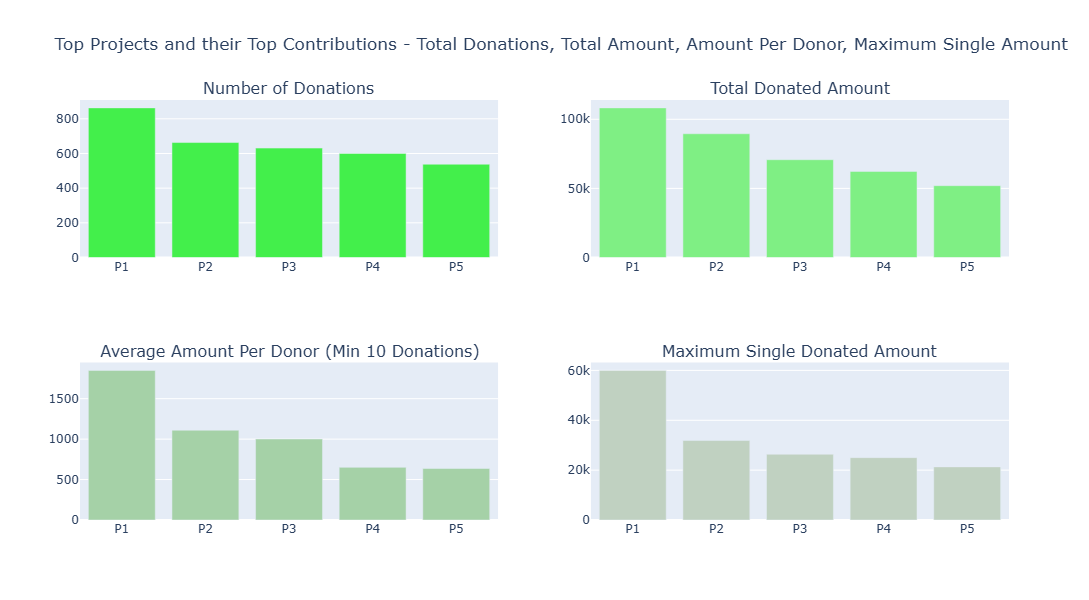

In [21]:


tempdf = donations_df.groupby('Project ID').agg({'Project ID' : 'count', 'Donation Amount' : 'sum'}).rename(columns={'Project ID' : "Total Donations", 'Donation Amount' : "Total Amount"}).reset_index()
tempdf['Average Donation Amount'] = tempdf['Total Amount'] / tempdf['Total Donations']

tempdf1 = tempdf.sort_values(by=['Total Donations'], ascending=[False])
x = tempdf1.head(5)['Project ID']
x = ["P"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Total Donations']
tr1 = bar_ver_noagg(x, y, 'Total Donations', '#43ef4b', lm=None, rt=True)

tempdf1 = tempdf.sort_values(by=['Total Amount'], ascending=[False])
x = tempdf1.head(5)['Project ID']
x = ["P"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Total Amount']
tr2 = bar_ver_noagg(x, y, 'Average Donations', '#7fef84', lm=None, rt=True)

tempdf1 = tempdf.sort_values(by=['Average Donation Amount'], ascending=[False])
x = tempdf1[tempdf1['Total Donations'] > 10].head(5)['Project ID']
x = ["P"+str(i+1) for i in range(len(x))]
y = tempdf1[tempdf1['Total Donations'] > 10].head(5)['Average Donation Amount']
tr3 = bar_ver_noagg(x, y, 'Average Donations (Min: 10 Donations)', '#a5d1a7', lm=None, rt=True)

tempdf = donations_df.groupby('Project ID').agg({'Project ID' : 'count', 'Donation Amount' : 'max'}).rename(columns={'Project ID' : "Total Donations", 'Donation Amount' : "Maximum Donations"}).reset_index()
tempdf1 = tempdf.sort_values(by=['Maximum Donations'], ascending=[False])
x = tempdf1.head(5)['Project ID']
x = ["P"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Maximum Donations']
tr4 = bar_ver_noagg(x, y, 'Maximum Donations', '#c0d1c1', lm=None, rt=True)



fig = tools.make_subplots(rows=2, cols=2, print_grid=False, subplot_titles = ['Number of Donations', "Total Donated Amount", 'Average Amount Per Donor (Min 10 Donations)', 'Maximum Single Donated Amount'])
fig.append_trace(tr1, 1, 1);
fig.append_trace(tr2, 1, 2);
fig.append_trace(tr3, 2, 1);

fig.append_trace(tr4, 2, 2);

fig['layout'].update(height=600, showlegend=False, title='Top Projects and their Top Contributions - Total Donations, Total Amount, Amount Per Donor, Maximum Single Amount');
iplot(fig);

## **3.3 Donantes más activos y generosos**
Layout de 4 gráficos de barras verticales que identifica: donantes con mayor número de donaciones realizadas, donantes que han aportado el monto más alto total, donantes con promedio más alto por donación individual, y máxima donación realizada por un solo donante.

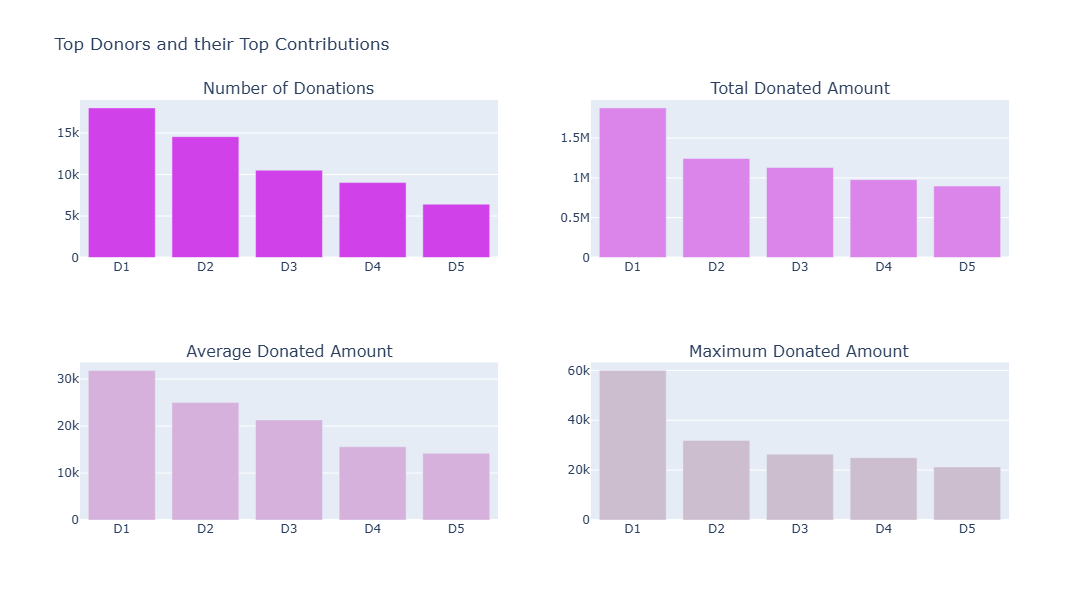

In [22]:


tempdf = donations_df.groupby('Donor ID').agg({'Donor ID' : 'count', 'Donation Amount' : 'sum'}).rename(columns={'Donor ID' : "Total Donations", 'Donation Amount' : "Total Amount"}).reset_index()
tempdf['Average Donation Amount'] = tempdf['Total Amount'] / tempdf['Total Donations']

tempdf1 = tempdf.sort_values(by=['Total Donations'], ascending=[False])
x = tempdf1.head(5)['Donor ID']
x = ["D"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Total Donations']
tr1 = bar_ver_noagg(x, y, 'Total Donations', '#d141ea', lm=None, rt=True)

tempdf1 = tempdf.sort_values(by=['Total Amount'], ascending=[False])
x = tempdf1.head(5)['Donor ID']
x = ["D"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Total Amount']
tr2 = bar_ver_noagg(x, y, 'Average Donations', '#db85ea', lm=None, rt=True)

tempdf1 = tempdf.sort_values(by=['Average Donation Amount'], ascending=[False])
x = tempdf1.head(5)['Donor ID']
x = ["D"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Average Donation Amount']
tr3 = bar_ver_noagg(x, y, 'Average Donations', '#d5b1db', lm=None, rt=True)

tempdf = donations_df.groupby('Donor ID').agg({'Donor ID' : 'count', 'Donation Amount' : 'max'}).rename(columns={'Donor ID' : "Total Donations", 'Donation Amount' : "Maximum Donations"}).reset_index()
tempdf1 = tempdf.sort_values(by=['Maximum Donations'], ascending=[False])
x = tempdf1.head(5)['Donor ID']
x = ["D"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Maximum Donations']
tr4 = bar_ver_noagg(x, y, 'Maximum Donations', '#ccbece', lm=None, rt=True)

fig = tools.make_subplots(rows=2, cols=2, print_grid=False, subplot_titles = ['Number of Donations', "Total Donated Amount", 'Average Donated Amount', 'Maximum Donated Amount'])
fig.append_trace(tr1, 1, 1);
fig.append_trace(tr2, 1, 2);
fig.append_trace(tr3, 2, 1);
fig.append_trace(tr4, 2, 2);

fig['layout'].update(height=600, showlegend=False, title='Top Donors and their Top Contributions');
iplot(fig);

## **3.4 Donaciones opcionales y donantes docentes**
Análisis comparativo mediante gráficos de pastel (pie charts) que contrastan el volumen de donaciones opcionales vs. no opcionales, y el aporte de docentes vs. no docentes. Se calcula el monto promedio para cada categoría.

### **3.4.1 Donaciones opcionales: cantidad y monto promedio**
Dos gráficos de pastel lado a lado muestran la proporción de donaciones con carácter opcional vs. obligatorio, junto con el monto promedio aportado en cada categoría (valores monetarios en USD mostrados directamente en el gráfico).

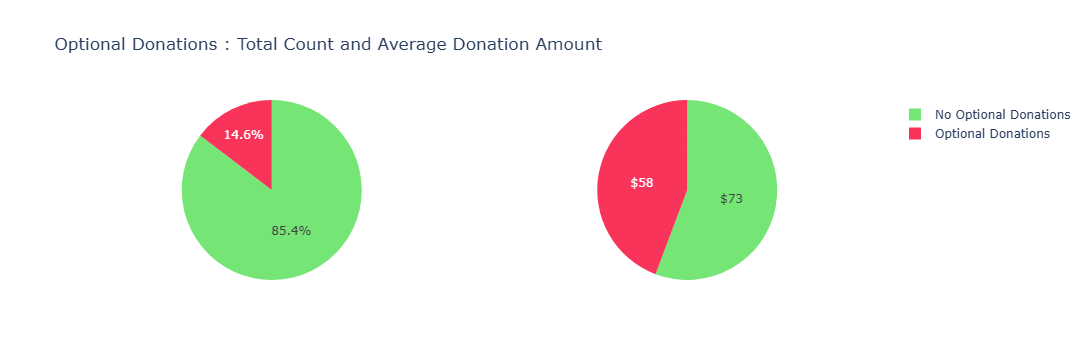

In [23]:
tempdf = donations_df.groupby('Donation Included Optional Donation').agg({'Donation Included Optional Donation' : 'count', 'Donation Amount' : 'mean'})
values1 = list(tempdf['Donation Included Optional Donation'])
values2 = list(tempdf['Donation Amount'])
values2t = [str("$")+str(int(x)) for x in values2]
domain1 = {'x': [0.2, 0.50], 'y': [0.0, 0.33]}
domain2 = {'x': [0.8, 0.50], 'y': [0.0, 0.33]}

labels = list(tempdf.index)
mp={'Yes' : 'Optional Donations', 'No' : 'No Optional Donations'}
labels = [mp[x] for x in labels]
trace1 = go.Pie(labels=labels, values=values1, marker=dict(colors=[  '#75e575', '#ea7c96',]))
trace2 = go.Pie(labels=labels, values=values2, marker=dict(colors=['#75e575', '#ea7c96',]), textinfo = "text", text=values2t)

layout = go.Layout(title='Number of Donations with Optional Donations', width=800, height=400)
# fig = go.Figure(data=[trace1], layout=layout)
# iplot(fig)

layout = go.Layout(title='Average Amount Donated in Optional Donations', width=800, height=400)
# fig = go.Figure(data=[trace2], layout=layout)
# iplot(fig)

fig = {
  "data": [
    {
      "values": values1,
      "labels": list(reversed(labels)),
      "domain": {"x": [0, .48]},
    "marker" : dict(colors=[  '#f9345b',  '#75e575']),
      "name": "No. of donations with Optional Donations",
#       "hoverinfo":"label+percent+name",
#       "hole": .4,

      "type": "pie"
    },
    {
      "values": values2,
      "labels": labels,
        "marker" : dict(colors=['75e575', '#f9345b']),
      "domain": {"x": [.52, 1]},
      "name": "Average Amount Donated in Optional Donations",
        "text" : values2t,
        "textinfo" : "text",
      "type": "pie"
    }],
  "layout": {
        "title":"Optional Donations : Total Count and Average Donation Amount",

    }
}
iplot(fig, filename='donut')

### **3.4.2 Donantes docentes vs. no docentes: volumen y monto promedio**
Dos gráficos de pastel lado a lado que comparan el número total de donaciones realizadas por docentes vs. no docentes, junto con el monto promedio que cada grupo aporta por donación (calculado mediante merge de Donors y Donations).

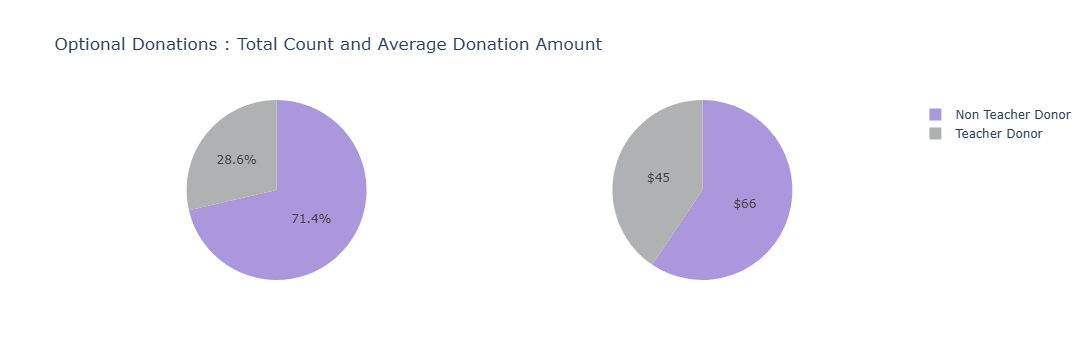

In [24]:
# lets combine donors and donations
combined_df = donations_df.merge(donors_df, on='Donor ID', how='inner')
# combined_df.head(10)

tempdf = combined_df.groupby('Donor Is Teacher').agg({'Donor Is Teacher' : 'count', 'Donation Amount' : 'mean'})
values1 = list(tempdf['Donor Is Teacher'])
values2 = list(tempdf['Donation Amount'])
values2t = [str("$")+str(int(x)) for x in values2]
domain1 = {'x': [0.2, 0.50], 'y': [0.0, 0.33]}
domain2 = {'x': [0.8, 0.50], 'y': [0.0, 0.33]}

labels = list(tempdf.index)
mp={'Yes' : 'Teacher Donor', 'No' : 'Non Teacher Donor'}
labels = [mp[x] for x in labels]
trace1 = go.Pie(labels=labels, values=values1, marker=dict(colors=[  '#75e575', '#ea7c96',]))
trace2 = go.Pie(labels=labels, values=values2, marker=dict(colors=['#75e575', '#ea7c96',]), textinfo = "text", text=values2t)

layout = go.Layout(title='Number of Donations with Optional Donations', width=800, height=400)
# fig = go.Figure(data=[trace1], layout=layout)
# iplot(fig)

layout = go.Layout(title='Average Amount Donated in Optional Donations', width=800, height=400)
# fig = go.Figure(data=[trace2], layout=layout)
# iplot(fig)

fig = {
  "data": [
    {
      "values": values1,
      "labels": labels,
      "domain": {"x": [0, .48]},
    "marker" : dict(colors=[ '#ab97db',  '#b0b1b2']),
      "name": "No. of donations with Optional Donations",
#       "hoverinfo":"label+percent+name",
#       "hole": .4,

      "type": "pie"
    },
    {
      "values": values2,
      "labels": labels,
        "marker" : dict(colors=[ '#ab97db',  '#b0b1b2']),
      "domain": {"x": [.52, 1]},
      "name": "Average Amount Donated in Optional Donations",
        "text" : values2t,
        "textinfo" : "text",
      "type": "pie"
    }],
  "layout": {
        "title":"Optional Donations : Total Count and Average Donation Amount",

    }
}
iplot(fig, filename='donut')

## **3.5 Estados con las donaciones únicas más altas**
Identificación de los estados que recibieron una sola donación de mayor valor.

- 3.5.1 Estados con mayores montos de donación

In [25]:
def mapp(df, scl, t):
    state_to_code = {'District of Columbia' : 'dc','Mississippi': 'MS', 'Oklahoma': 'OK', 'Delaware': 'DE', 'Minnesota': 'MN', 'Illinois': 'IL', 'Arkansas': 'AR', 'New Mexico': 'NM', 'Indiana': 'IN', 'Maryland': 'MD', 'Louisiana': 'LA', 'Idaho': 'ID', 'Wyoming': 'WY', 'Tennessee': 'TN', 'Arizona': 'AZ', 'Iowa': 'IA', 'Michigan': 'MI', 'Kansas': 'KS', 'Utah': 'UT', 'Virginia': 'VA', 'Oregon': 'OR', 'Connecticut': 'CT', 'Montana': 'MT', 'California': 'CA', 'Massachusetts': 'MA', 'West Virginia': 'WV', 'South Carolina': 'SC', 'New Hampshire': 'NH', 'Wisconsin': 'WI', 'Vermont': 'VT', 'Georgia': 'GA', 'North Dakota': 'ND', 'Pennsylvania': 'PA', 'Florida': 'FL', 'Alaska': 'AK', 'Kentucky': 'KY', 'Hawaii': 'HI', 'Nebraska': 'NE', 'Missouri': 'MO', 'Ohio': 'OH', 'Alabama': 'AL', 'Rhode Island': 'RI', 'South Dakota': 'SD', 'Colorado': 'CO', 'New Jersey': 'NJ', 'Washington': 'WA', 'North Carolina': 'NC', 'New York': 'NY', 'Texas': 'TX', 'Nevada': 'NV', 'Maine': 'ME'}
    df['state_code'] = statesdf['state'].apply(lambda x : state_to_code[x] if x in state_to_code else "")

    data = [ dict(
            type='choropleth',
            colorscale = scl,
            autocolorscale = False,
            locations = df['state_code'],
            z = df['counts'],
            locationmode = 'USA-states',
            text = df['state'],
            marker = dict(
                line = dict (
                    color = 'rgb(255,255,255)',
                    width = 2
                ) ),
            colorbar = dict(
                title = "Donors")
            ) ]

    layout = dict(
            title = t,
            geo = dict(
                scope='usa',
                projection=dict( type='albers usa' ),
                showlakes = True,
                lakecolor = 'rgb(255, 255, 255)'),
                 )

    fig = dict( data=data, layout=layout )
    iplot( fig, filename='d3-cloropleth-map' )

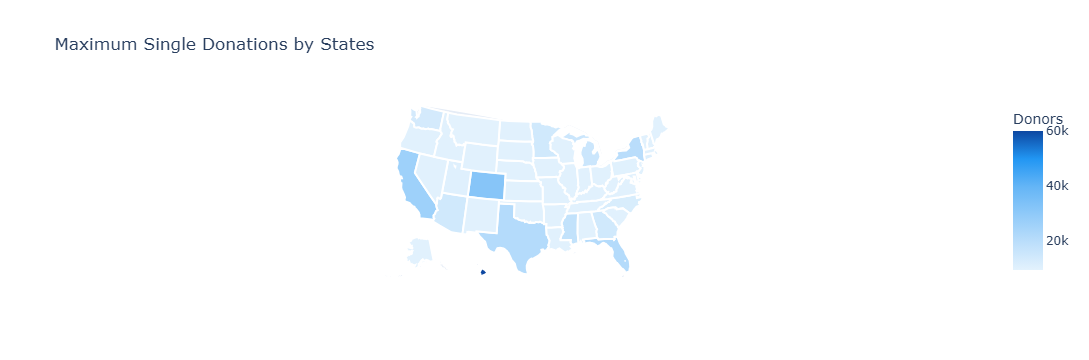

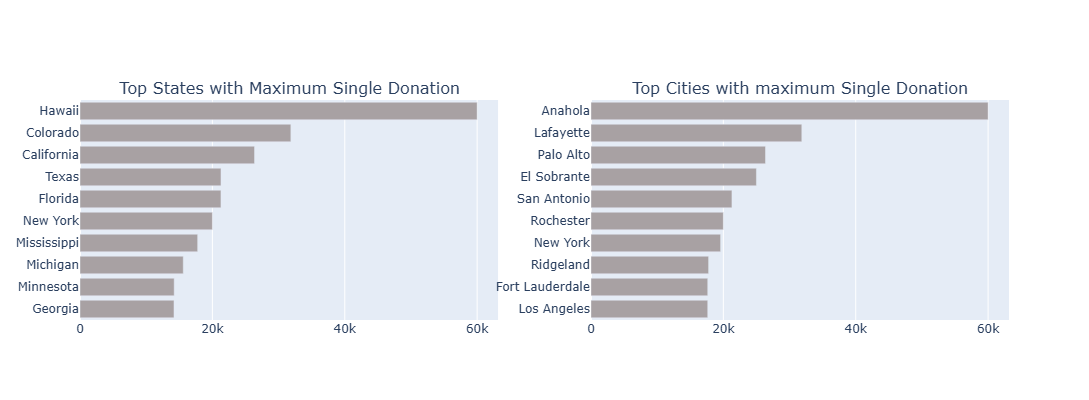

In [27]:
# Maximum Donation Amounts
tempdf = combined_df.groupby(['Donor State']).agg({'Donation Amount':'max'}).reset_index()
t1 = tempdf.sort_values('Donation Amount', ascending=False)

tempdf = combined_df.groupby(['Donor City']).agg({'Donation Amount':'max'}).reset_index()
t2 = tempdf.sort_values('Donation Amount', ascending=False)

statesdf = pd.DataFrame()
statesdf['state'] = t1['Donor State']
statesdf['counts'] = t1['Donation Amount']
statesdf

citydf = pd.DataFrame()
citydf['state'] = t2['Donor City']
citydf['counts'] = t2['Donation Amount']
citydf

# Escala de color azul
scl = [
    [0.0, '#E3F2FD'],
    [0.2, '#BBDEFB'],
    [0.4, '#90CAF9'],
    [0.6, '#64B5F6'],
    [0.8, '#2196F3'],
    [1.0, '#0D47A1']
]
mapp(statesdf, scl, 'Maximum Single Donations by States')

trace1 = bar_hor_noagg(list(reversed(list(statesdf['state'][:10]))), list(reversed(list(statesdf['counts'][:10]))), "Top Cities with maximum Donors", '#a8a1a3', 600, 400, 200, limit = 10, rt=True)
trace2 = bar_hor_noagg(list(reversed(list(citydf['state'][:10]))), list(reversed(list(citydf['counts'][:10]))), "Top States with maximum Donors", '#a8a1a3', 600, 400, 200, limit = 10, rt=True)
fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ['Top States with Maximum Single Donation','Top Cities with maximum Single Donation'])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 2);
fig['layout'].update(height=400, showlegend=False);
iplot(fig);


## **3.6 Monto promedio de donación por estado y ciudad**
Mapa de coropletas más gráficos de barras que visualiza el promedio de donación que recibe cada estado y ciudad. Permite identificar cuáles regiones reciben donaciones de mayor valor en promedio (valor unitario promedio de las donaciones).

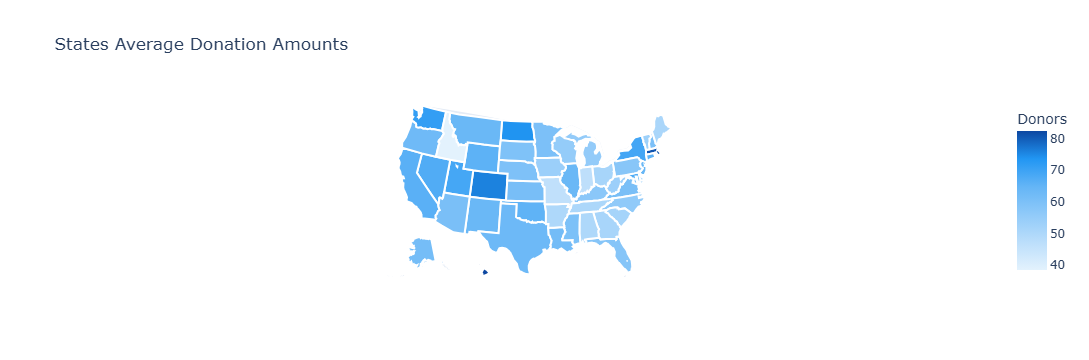

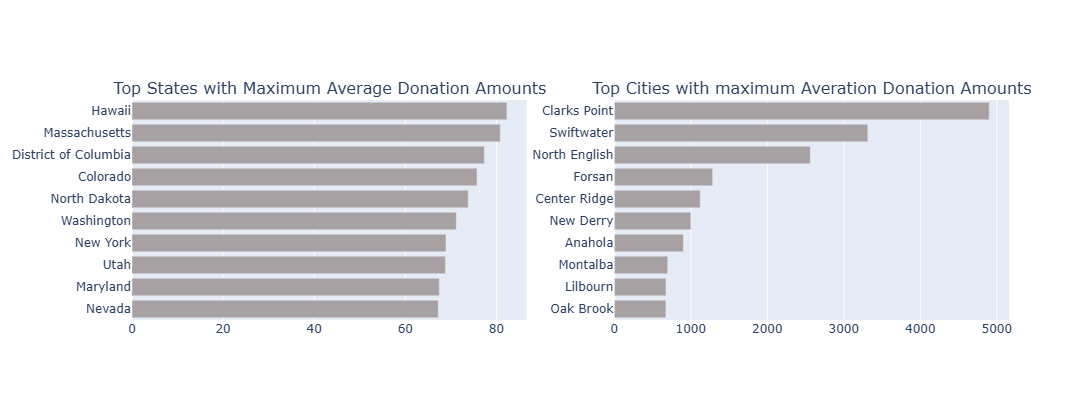

In [29]:
# Mean Donation Amounts
tempdf = combined_df.groupby(['Donor State']).agg({'Donation Amount':'mean'}).reset_index()
t1 = tempdf.sort_values('Donation Amount', ascending=False)

tempdf = combined_df.groupby(['Donor City']).agg({'Donation Amount':'mean'}).reset_index()
t2 = tempdf.sort_values('Donation Amount', ascending=False)

statesdf = pd.DataFrame()
statesdf['state'] = t1['Donor State']
statesdf['counts'] = t1['Donation Amount']
statesdf

citydf = pd.DataFrame()
citydf['state'] = t2['Donor City']
citydf['counts'] = t2['Donation Amount']
citydf

# Escala de color azul
scl = [
    [0.0, '#E3F2FD'],
    [0.2, '#BBDEFB'],
    [0.4, '#90CAF9'],
    [0.6, '#64B5F6'],
    [0.8, '#2196F3'],
    [1.0, '#0D47A1']
]
mapp(statesdf, scl, 'States Average Donation Amounts')

trace1 = bar_hor_noagg(list(reversed(list(statesdf['state'][:10]))), list(reversed(list(statesdf['counts'][:10]))), "Top Cities with maximum Donors", '#a8a1a3', 600, 400, 200, limit = 10, rt=True)
trace2 = bar_hor_noagg(list(reversed(list(citydf['state'][:10]))), list(reversed(list(citydf['counts'][:10]))), "Top States with maximum Donors", '#a8a1a3', 600, 400, 200, limit = 10, rt=True)
fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ['Top States with Maximum Average Donation Amounts','Top Cities with maximum Averation Donation Amounts'])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 2);
fig['layout'].update(height=400, showlegend=False);
iplot(fig);

## **3.7 Total acumulativo de donaciones por estado**
Mapa de coropletas que colorea cada estado según el monto acumulativo total de donaciones recibidas. Gráficos de barras complementarios muestran los 10 estados con mayor recaudación total y sus ciudades principales.


In [30]:
statesll=StringIO("""State,Latitude,Longitude
Alabama,32.806671,-86.791130
Alaska,61.370716,-152.404419
Arizona,33.729759,-111.431221
Arkansas,34.969704,-92.373123
California,36.116203,-119.681564
Colorado,39.059811,-105.311104
Connecticut,41.597782,-72.755371
Delaware,39.318523,-75.507141
District of Columbia,38.897438,-77.026817
Florida,27.766279,-81.686783
Georgia,33.040619,-83.643074
Hawaii,21.094318,-157.498337
Idaho,44.240459,-114.478828
Illinois,40.349457,-88.986137
Indiana,39.849426,-86.258278
Iowa,42.011539,-93.210526
Kansas,38.526600,-96.726486
Kentucky,37.668140,-84.670067
Louisiana,31.169546,-91.867805
Maine,44.693947,-69.381927
Maryland,39.063946,-76.802101
Massachusetts,42.230171,-71.530106
Michigan,43.326618,-84.536095
Minnesota,45.694454,-93.900192
Mississippi,32.741646,-89.678696
Missouri,38.456085,-92.288368
Montana,46.921925,-110.454353
Nebraska,41.125370,-98.268082
Nevada,38.313515,-117.055374
New Hampshire,43.452492,-71.563896
New Jersey,40.298904,-74.521011
New Mexico,34.840515,-106.248482
New York,42.165726,-74.948051
North Carolina,35.630066,-79.806419
North Dakota,47.528912,-99.784012
Ohio,40.388783,-82.764915
Oklahoma,35.565342,-96.928917
Oregon,44.572021,-122.070938
Pennsylvania,40.590752,-77.209755
Rhode Island,41.680893,-71.511780
South Carolina,33.856892,-80.945007
South Dakota,44.299782,-99.438828
Tennessee,35.747845,-86.692345
Texas,31.054487,-97.563461
Utah,40.150032,-111.862434
Vermont,44.045876,-72.710686
Virginia,37.769337,-78.169968
Washington,47.400902,-121.490494
West Virginia,38.491226,-80.954453
Wisconsin,44.268543,-89.616508
Wyoming,42.755966,-107.302490""")

tempdf = combined_df.groupby(['Donor State']).agg({'Donation Amount':'sum'}).reset_index()
t1 = tempdf.sort_values('Donation Amount', ascending=False)

sdf = pd.read_csv(statesll).rename(columns={'State':'Donor State'})
sdf = sdf.merge(t1, on='Donor State', how='inner')

map4 = folium.Map(location=[39.50, -98.35], tiles='CartoDB dark_matter', zoom_start=3)
for j, rown in sdf.iterrows():
    rown = list(rown)
    folium.CircleMarker([float(rown[1]), float(rown[2])], popup=rown[0]+" $"+str(int(rown[3])), radius=float(rown[3])*0.000001, color='blue', fill=True).add_to(map4)
map4


# **4. Exploración de los docentes**
Análisis del crecimiento temporal de docentes en la plataforma, patrones de publicación de primeros proyectos y distribución de prefijos en nombres de docentes. Incluye series temporales para identificar períodos de mayor actividad.

## **4.1 Resumen de los docentes**
Inspección inicial del DataFrame de docentes para validar columnas disponibles y estructura de datos.

In [31]:
teachers_df.head(5)

,Teacher ID,Teacher Prefix,Teacher First Project Posted Date
0,00000f7264c27ba6fea0c837ed6aa0aa,Mrs.,2013-08-21
1,00002d44003ed46b066607c5455a999a,Mrs.,2016-10-23
2,00006084c3d92d904a22e0a70f5c119a,Mr.,2016-09-08
3,0000a9af8b6b9cc9e41f53322a8b8cf1,Ms.,2015-10-25
4,0000d4777d14b33a1406dd6c9019fe89,Ms.,2017-02-10


## **4.2 Primeros docentes registrados en DonorsChoose**
Identificación y análisis de los docentes pioneros que se registraron primero en la plataforma, permitiendo entender el crecimiento inicial del proyecto.

In [32]:
teachers_df['Posted Date'] = pd.to_datetime(teachers_df['Teacher First Project Posted Date'])
teachers_df['Posted Year'] = teachers_df['Posted Date'].dt.year

# Some of the Earliest Teachers
teachers_df.sort_values(['Posted Date'])[:10]

,Teacher ID,Teacher Prefix,Teacher First Project Posted Date,Posted Date,Posted Year
280335,b218f64064e174657336d229e2231962,Ms.,2002-09-17,2002-09-17,2002
245493,9c0aa56b63b743454d6da9effcf122fc,Ms.,2002-09-17,2002-09-17,2002
77122,31367152c3ea88bfdf8a97848be8bd07,Ms.,2002-09-19,2002-09-19,2002
357964,e3751e935d13de6b37864194955d1548,Ms.,2002-09-19,2002-09-19,2002
245631,9c214c58003f1d4c82261404b8bbfcf5,Ms.,2002-09-19,2002-09-19,2002
41877,1aacfb91eb392114236f0c38fa44f27b,Mrs.,2002-09-19,2002-09-19,2002
271224,ac3d575cd2d7a58063677162afd90f7d,Mr.,2002-09-19,2002-09-19,2002
295166,bb9451ffe8ef76852f4030238a73ac41,Ms.,2002-09-20,2002-09-20,2002
272164,acd4f1b0b4b698c27adc1828d0d3f77d,Ms.,2002-10-11,2002-10-11,2002
292250,b9b643f2558b0e27cc69d93a0dc2f333,Ms.,2002-11-05,2002-11-05,2002


## **4.3 Evolución temporal de registro de docentes**
Serie temporal que visualiza cómo ha crecido el número de docentes registrados año a año, permitiendo identificar períodos de expansión acelerada o desaceleración en la plataforma.

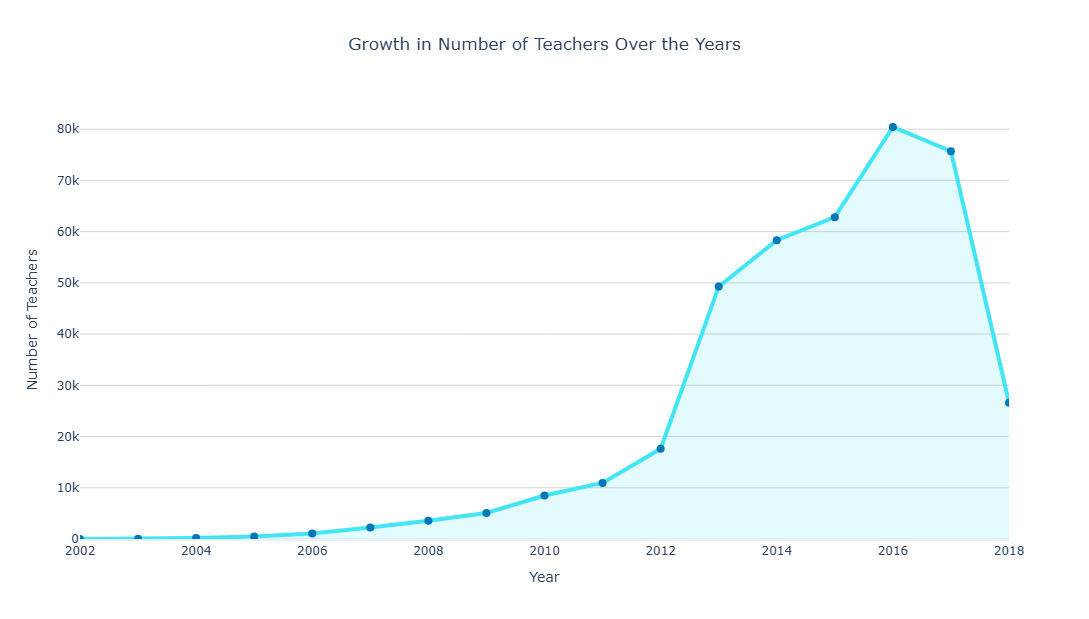

In [33]:
import plotly.graph_objects as go

temp = (
    teachers_df
    .groupby('Posted Year')['Teacher ID']
    .count()
    .reset_index()
    .sort_values('Posted Year')
)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=temp['Posted Year'],
        y=temp['Teacher ID'],
        mode='lines+markers',
        line=dict(
            color='#42e5f4',
            width=4
        ),
        marker=dict(
            size=8,
            color='#0077b6'
        ),
        fill='tozeroy',
        fillcolor='rgba(66,229,244,0.15)',
        name='Teachers'
    )
)

fig.update_layout(
    title={
        'text': 'Growth in Number of Teachers Over the Years',
        'x': 0.5
    },
    template='plotly_white',
    width=1100,
    height=600,
    xaxis=dict(
        title='Year',
        showgrid=False,
        showline=True,
        linewidth=2
    ),
    yaxis=dict(
        title='Number of Teachers',
        showgrid=True,
        gridcolor='lightgray'
    ),
    hovermode='x unified'
)

fig.show()

## **4.4 Distribución de títulos/prefijos en nombres de docentes**
Análisis de los prefijos (Dr., Prof., Mr., Mrs., Ms., etc.) utilizados en los nombres de docentes registrados, permitiendo identificar patrones de formalidad o tradición en la plataforma.

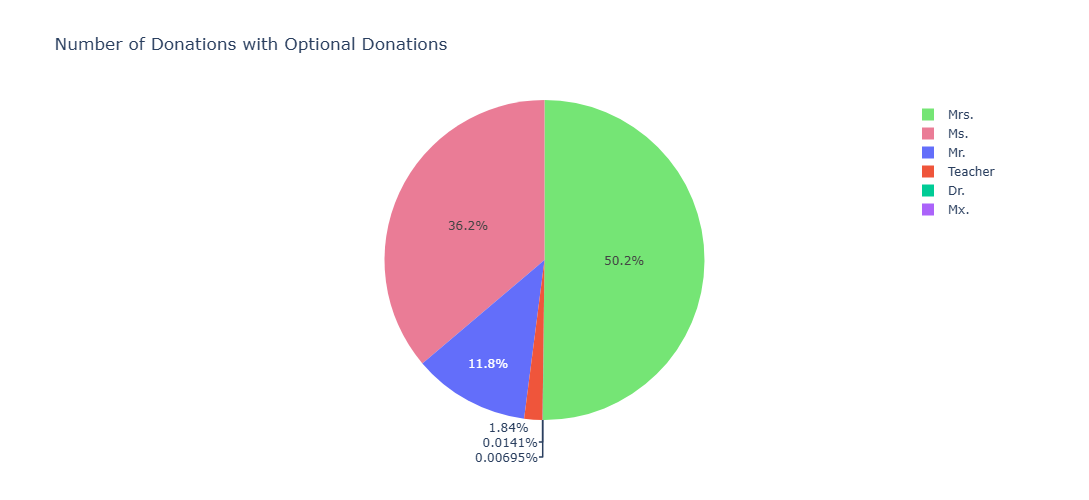

In [34]:

t = teachers_df['Teacher Prefix'].value_counts()

labels = t.index
values2 = t.values
trace2 = go.Pie(labels=labels, values=values2, marker=dict(colors=['#75e575', '#ea7c96',]))

layout = go.Layout(title='Number of Donations with Optional Donations', width=800, height=500)
fig = go.Figure(data=[trace2], layout=layout)
iplot(fig)

## **4.5 Serie temporal: fecha de primer proyecto publicado**
Gráfico de barras temporal que muestra en qué fechas los docentes publicaron por primera vez un proyecto en DonorsChoose. Identifica picos de actividad (ej: septiembre de cada año) y la distribución de nuevos proyectos a lo largo del tiempo.

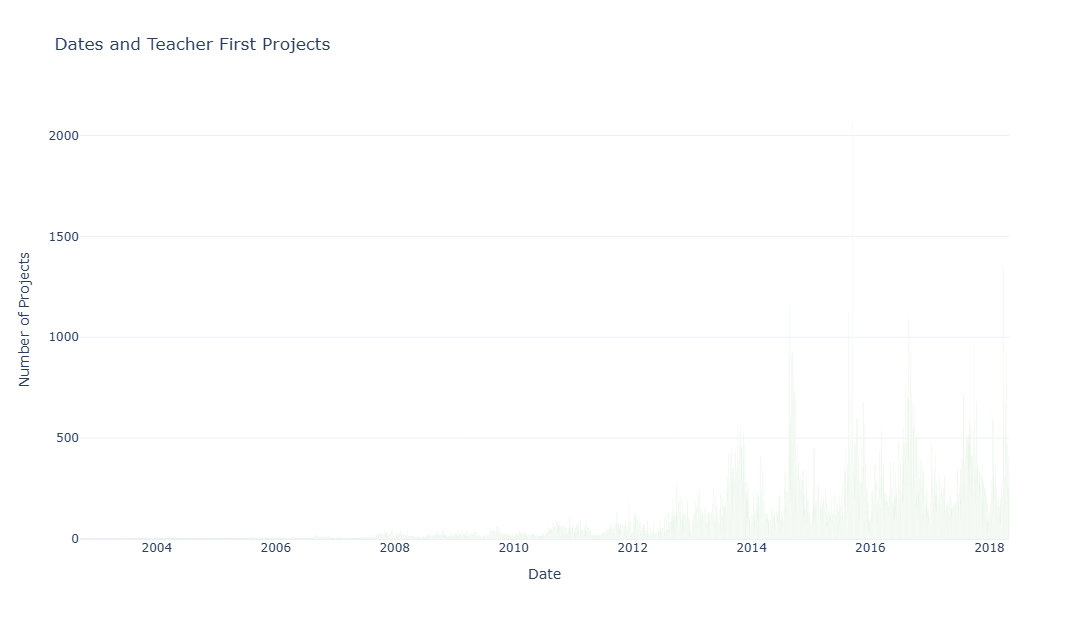

In [35]:
teachers_df['Posted Date'] = pd.to_datetime(teachers_df['Posted Date'])

t = (
    teachers_df['Posted Date']
    .value_counts()
    .sort_index()
)

x = t.index
y = t.values

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=x,
        y=y,
        marker_color='#2ca02c'
    )
)

fig.update_layout(
    title='Dates and Teacher First Projects',
    xaxis_title='Date',
    yaxis_title='Number of Projects',
    template='plotly_white',
    width=1200,
    height=600
)

fig.show()

# **5. Exploración de las escuelas**
Análisis de características socioeconómicas de las escuelas (porcentaje de almuerzo gratuito como indicador de pobreza), distribución por zona metropolitana, e identificación de escuelas con mayor necesidad de fondos. Incluye histogramas, gráficos de barras y distribuciones.

## **5.1 Resumen de las escuelas**
Inspección inicial del DataFrame de escuelas para validar columnas disponibles (nombre, zona, porcentaje de almuerzo gratuito, etc.) y estructura de datos.

In [37]:
path = r"G:\Mi unidad\Practica_06\datasets\\"

schools_df = pd.read_csv(
    path + "Schools.csv",
    on_bad_lines='skip'
)

## **5.2 Escuelas por tipo de zona metropolitana y principales estados y ciudades**
Relación entre el tipo de zona metropolitana y la publicación de proyectos.

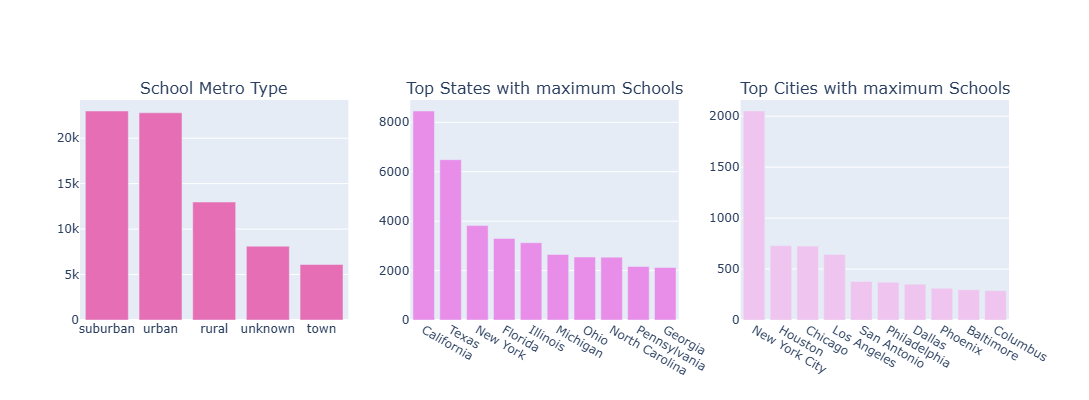

In [38]:
t1 = schools_df['School Metro Type'].value_counts()
t2 = schools_df['School State'].value_counts()
t3 = schools_df['School City'].value_counts()


trace1 = bar_ver_noagg(t1.index[:10], t1.values[:10], "School Metro Type", '#e56eb5', None, None, 0,  rt=True)
trace2 = bar_ver_noagg(t2.index[:10], t2.values[:10], "Top States with maximum Schools", '#e88de8', None, None, 0,  rt=True)
trace3 = bar_ver_noagg(t3.index[:10], t3.values[:10], "Top Cities with maximum Schools", '#efc4ef', None, None, 0,  rt=True)

fig = tools.make_subplots(rows=1, cols=3, print_grid=False, subplot_titles = ['School Metro Type', 'Top States with maximum Schools', 'Top Cities with maximum Schools'])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 2);
fig.append_trace(trace3, 1, 3);
fig['layout'].update(height=400, showlegend=False);
iplot(fig);

## **5.3 Distribución del porcentaje de almuerzo gratuito**
Histograma (distplot) que visualiza la distribución completa del porcentaje de alumnos con almuerzo gratuito en todas las escuelas. Este indicador es un proxy de pobreza y necesidad económica de las escuelas participantes en DonorsChoose.

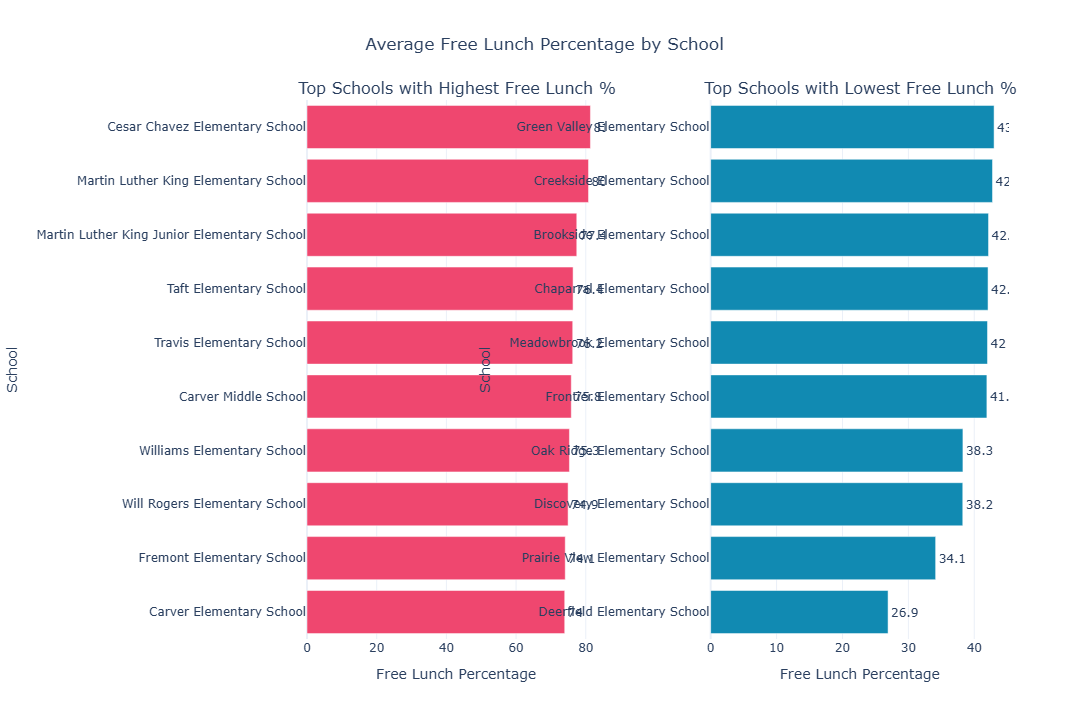

In [39]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

t = (
    schools_df
    .groupby('School Name')
    .agg({
        'School Name': 'count',
        'School Percentage Free Lunch': 'mean'
    })
)

t1 = (
    t[t['School Name'] > 10]
    .sort_values(
        'School Percentage Free Lunch',
        ascending=False
    )
)

top10 = t1.head(10).sort_values(
    'School Percentage Free Lunch',
    ascending=True
)

bottom10 = t1.tail(10).sort_values(
    'School Percentage Free Lunch',
    ascending=True
)

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Top Schools with Highest Free Lunch %",
        "Top Schools with Lowest Free Lunch %"
    ),
    horizontal_spacing=0.15
)

fig.add_trace(
    go.Bar(
        x=top10['School Percentage Free Lunch'],
        y=top10.index,
        orientation='h',
        marker_color='#ef476f',
        text=round(top10['School Percentage Free Lunch'], 1),
        textposition='outside'
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Bar(
        x=bottom10['School Percentage Free Lunch'],
        y=bottom10.index,
        orientation='h',
        marker_color='#118ab2',
        text=round(bottom10['School Percentage Free Lunch'], 1),
        textposition='outside'
    ),
    row=1,
    col=2
)

fig.update_layout(
    template='plotly_white',
    title={
        'text': 'Average Free Lunch Percentage by School',
        'x': 0.5
    },
    width=1600,
    height=700,
    showlegend=False
)

fig.update_xaxes(title_text='Free Lunch Percentage')
fig.update_yaxes(title_text='School')

fig.show()

In [40]:
resources_df = pd.read_csv(path+"Resources.csv")
resources_df.head(5)

,Project ID,Resource Item Name,Resource Quantity,Resource Unit Price,Resource Vendor Name
0,000009891526c0ade7180f8423792063,chair move and store cart,1.0,350.00,NaN
1,00000ce845c00cbf0686c992fc369df4,sony mdr zx100 blk headphones,40.0,12.86,CDW-G
2,00002d44003ed46b066607c5455a999a,"gaiam kids stay-n-play balance ball, grey",4.0,19.00,Amazon Business
3,00002d44003ed46b066607c5455a999a,cf520x - giant comfy pillows - set of 4,1.0,269.00,Lakeshore Learning Materials
4,00002d44003ed46b066607c5455a999a,"serta lounger, mini, sky blue",1.0,131.85,Amazon Business


## **5.4 Escuelas con mayor porcentaje promedio de almuerzo gratuito**
Gráficos de barras lado a lado que identifican las 10 escuelas con mayor porcentaje promedio de alumnos con almuerzo gratuito (mayor necesidad) y las 10 con menor porcentaje (menor necesidad). Permite focalizar recursos en escuelas más vulnerables.

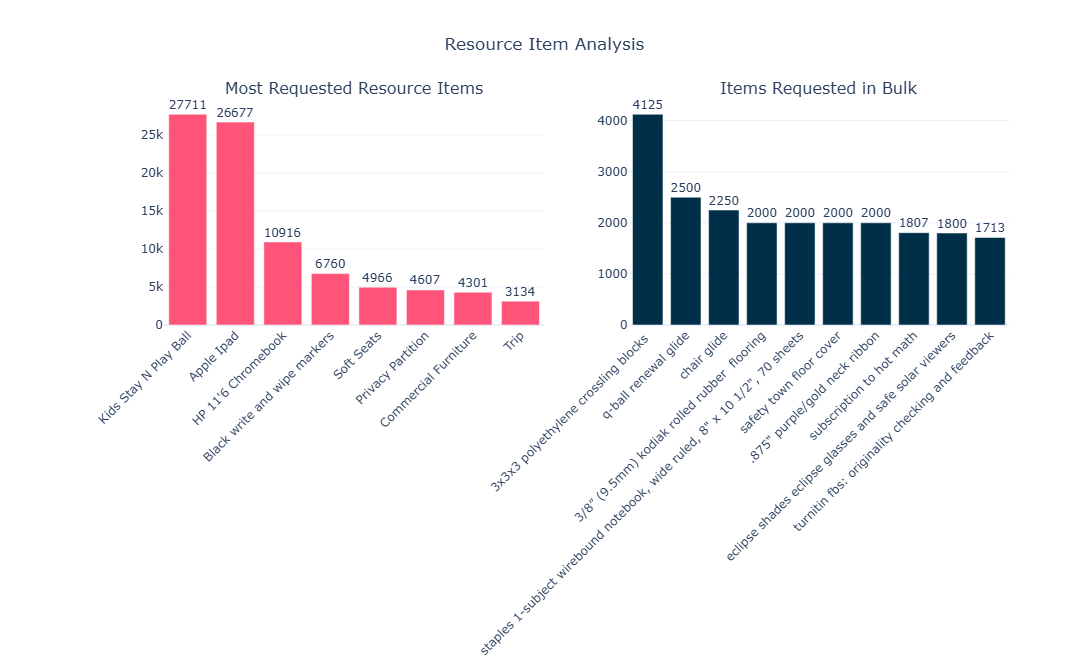

In [41]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd

tdf = resources_df['Resource Item Name'].value_counts()

t = pd.DataFrame({
    'item': tdf.index,
    'count': tdf.values
})

standardized_items = [
    "Kids Stay N Play Ball",
    "Apple Ipad",
    "HP 11'6 Chromebook",
    "Black write and wipe markers",
    "Kids Stay N Play Ball",
    "Soft Seats",
    "Privacy Partition",
    "Apple Ipad",
    "Commercial Furniture",
    "Apple Ipad",
    "Apple Ipad",
    "Noise",
    "Apple Ipad",
    "Noise",
    "Trip"
]

n = min(len(t), len(standardized_items))

t = t.head(n).copy()
t['standardized'] = standardized_items[:n]

t1 = (
    t.groupby('standardized')['count']
    .sum()
    .reset_index()
)

t1 = t1[t1['standardized'] != 'Noise']
t1 = t1.sort_values('count', ascending=False)

trace1 = go.Bar(
    x=t1['standardized'],
    y=t1['count'],
    marker_color='#ff5479',
    text=t1['count'],
    textposition='outside'
)

top_quantity = (
    resources_df
    .sort_values('Resource Quantity', ascending=False)
    .head(10)
)

trace2 = go.Bar(
    x=top_quantity['Resource Item Name'],
    y=top_quantity['Resource Quantity'],
    marker_color='#003049',
    text=top_quantity['Resource Quantity'],
    textposition='outside'
)

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        'Most Requested Resource Items',
        'Items Requested in Bulk'
    )
)

fig.add_trace(trace1, row=1, col=1)
fig.add_trace(trace2, row=1, col=2)

fig.update_layout(
    template='plotly_white',
    title={
        'text': 'Resource Item Analysis',
        'x': 0.5
    },
    width=1400,
    height=650,
    showlegend=False
)

fig.update_xaxes(tickangle=-45)

fig.show()

# **6. Exploración de los recursos**
Análisis de qué recursos solicitan las escuelas en sus proyectos, incluyendo artículos más populares, más costosos, cantidades solicitadas y distribución de gastos. Utiliza gráficos de barras para visualizar tendencias de gasto y preferencias de recursos.

## **6.1 Resumen de los recursos**
Inspección inicial del DataFrame de recursos para validar columnas (nombre del artículo, precio unitario, cantidad solicitada, proveedor, etc.).

In [42]:

resources_df = pd.read_csv(path+"Resources.csv")
resources_df.head(5)

,Project ID,Resource Item Name,Resource Quantity,Resource Unit Price,Resource Vendor Name
0,000009891526c0ade7180f8423792063,chair move and store cart,1.0,350.00,NaN
1,00000ce845c00cbf0686c992fc369df4,sony mdr zx100 blk headphones,40.0,12.86,CDW-G
2,00002d44003ed46b066607c5455a999a,"gaiam kids stay-n-play balance ball, grey",4.0,19.00,Amazon Business
3,00002d44003ed46b066607c5455a999a,cf520x - giant comfy pillows - set of 4,1.0,269.00,Lakeshore Learning Materials
4,00002d44003ed46b066607c5455a999a,"serta lounger, mini, sky blue",1.0,131.85,Amazon Business


## **6.2 Artículos más populares y solicitados en masa**
Dos gráficos de barras lado a lado: el primero muestra los 15 tipos de recursos más frecuentemente solicitados (ej: iPad, Chromebooks, marcadores); el segundo muestra qué recursos se solicitan en mayor cantidad por proyecto individual. Identifica necesidades prioritarias de las escuelas.

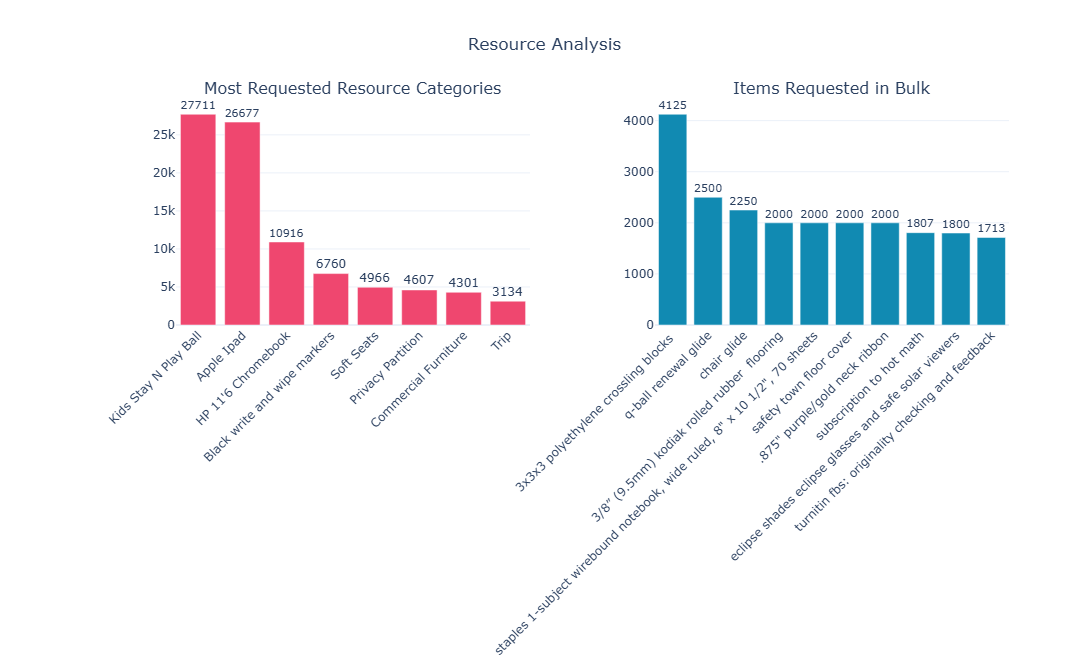

In [43]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd

tdf = resources_df['Resource Item Name'].value_counts()

t = pd.DataFrame({
    'item': tdf.index,
    'count': tdf.values
})

standardized_items = [
    "Kids Stay N Play Ball",
    "Apple Ipad",
    "HP 11'6 Chromebook",
    "Black write and wipe markers",
    "Kids Stay N Play Ball",
    "Soft Seats",
    "Privacy Partition",
    "Apple Ipad",
    "Commercial Furniture",
    "Apple Ipad",
    "Apple Ipad",
    "Noise",
    "Apple Ipad",
    "Noise",
    "Trip"
]

n = min(len(t), len(standardized_items))

t = t.head(n).copy()
t['standardized'] = standardized_items[:n]

t1 = (
    t.groupby('standardized')['count']
    .sum()
    .reset_index()
)

t1 = t1[t1['standardized'].str.strip() != 'Noise']
t1 = t1.sort_values('count', ascending=False)

bulk_items = (
    resources_df
    .sort_values('Resource Quantity', ascending=False)
    .head(10)
)

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        'Most Requested Resource Categories',
        'Items Requested in Bulk'
    ),
    horizontal_spacing=0.15
)

fig.add_trace(
    go.Bar(
        x=t1['standardized'],
        y=t1['count'],
        marker_color='#ef476f',
        text=t1['count'],
        textposition='outside'
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Bar(
        x=bulk_items['Resource Item Name'],
        y=bulk_items['Resource Quantity'],
        marker_color='#118ab2',
        text=bulk_items['Resource Quantity'],
        textposition='outside'
    ),
    row=1,
    col=2
)

fig.update_layout(
    template='plotly_white',
    title={
        'text': 'Resource Analysis',
        'x': 0.5
    },
    width=1500,
    height=650,
    showlegend=False
)

fig.update_xaxes(
    tickangle=-45
)

fig.show()


## **6.3 Artículos de mayor costo unitario**
Gráfico de barras horizontal que muestra los 15 recursos con precio unitario más alto (ej: equipos de patio de juegos, estructuras de patio, sistemas de audio, instrumentos musicales). Estos items representan inversiones grandes por unidad.

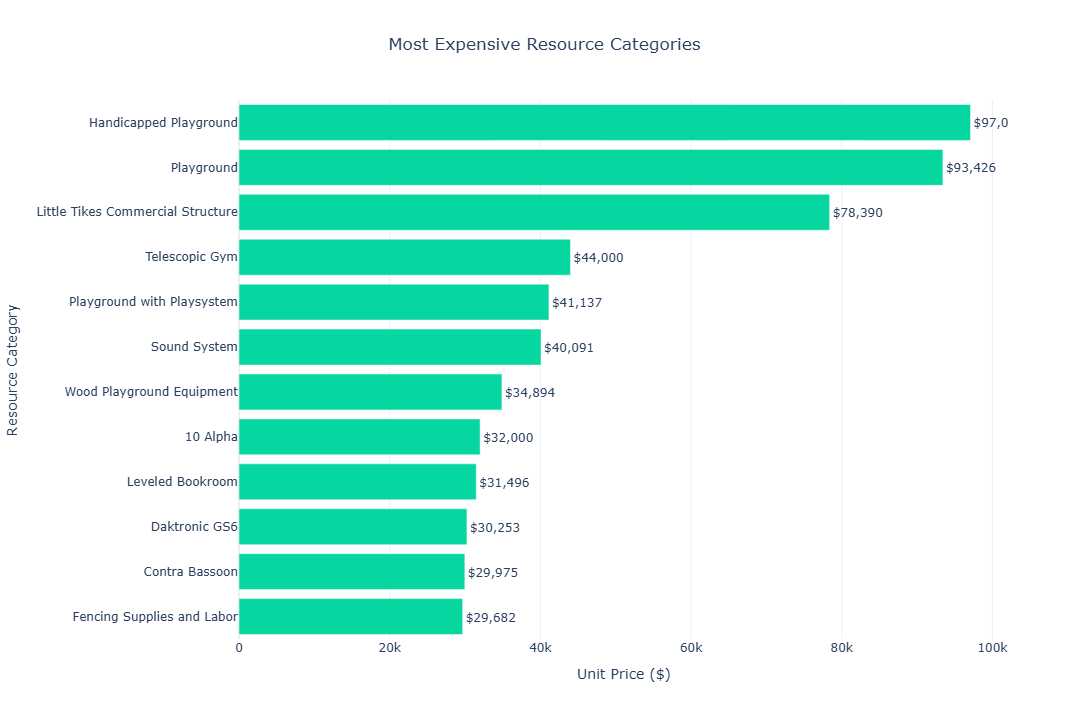

In [44]:
import pandas as pd
import plotly.graph_objects as go

t = (
    resources_df
    .sort_values('Resource Unit Price', ascending=False)
    .head(15)
)

t1 = pd.DataFrame({
    'item': t['Resource Item Name'].values,
    'price': t['Resource Unit Price'].values
})

standardized_items = [
    "Handicapped Playground",
    "Playground",
    "Little Tikes Commercial Structure",
    "Telescopic Gym",
    "Playground with Playsystem",
    "Sound System",
    "Little Tikes Commercial Structure",
    "Wood Playground Equipment",
    "Playground with Playsystem",
    "10 Alpha",
    "Leveled Bookroom",
    "Daktronic GS6",
    "Contra Bassoon",
    "Fencing Supplies and Labor",
    "Playground with Playsystem"
]

n = min(len(t1), len(standardized_items))

t1 = t1.head(n).copy()
t1['standardized'] = standardized_items[:n]

t2 = (
    t1.groupby('standardized')['price']
    .max()
    .reset_index()
    .sort_values('price', ascending=True)
)

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=t2['price'],
        y=t2['standardized'],
        orientation='h',
        marker_color='#06d6a0',
        text=[f'${x:,.0f}' for x in t2['price']],
        textposition='outside'
    )
)

fig.update_layout(
    template='plotly_white',
    title={
        'text': 'Most Expensive Resource Categories',
        'x': 0.5
    },
    xaxis_title='Unit Price ($)',
    yaxis_title='Resource Category',
    width=1200,
    height=700,
    showlegend=False
)

fig.show()

## **6.4 Proveedores y distribuidores dominantes**
Gráfico de barras horizontal que identifica los 15 proveedores (vendors) más frecuentemente utilizados en los proyectos de DonorsChoose. Permite ver qué empresas dominan el mercado de recursos educativos solicitados por las escuelas.

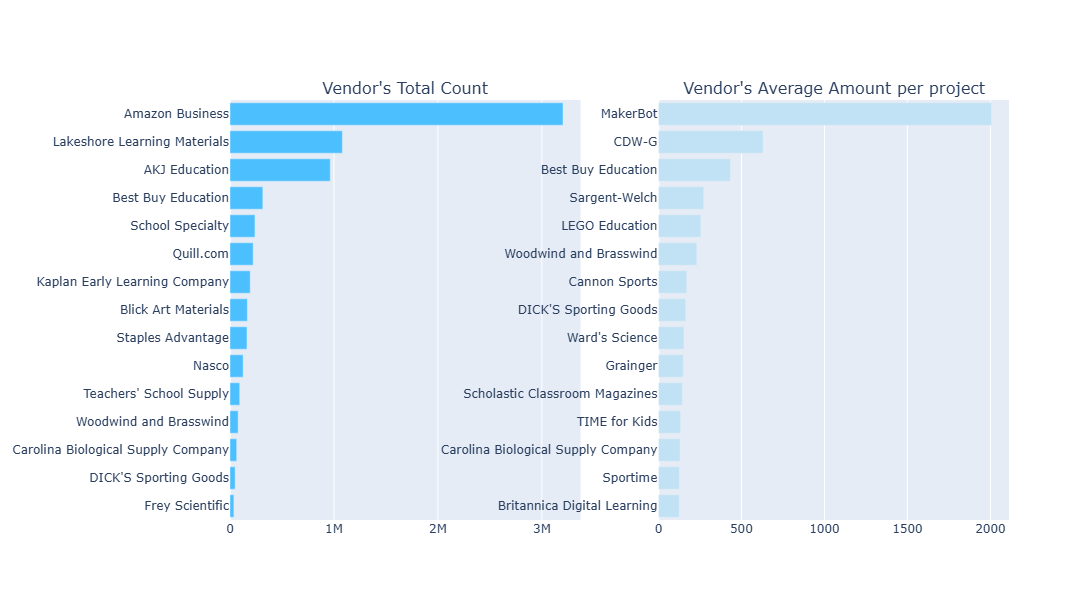

In [45]:
# most famous vendors
t = resources_df['Resource Vendor Name'].value_counts()
k = list(reversed(list(t.index)[:15]))
v = list(reversed(list(t.values)[:15]))

t = resources_df.sort_values('Resource Quantity', ascending=False).head(10)
trace2 = bar_hor_noagg(k, v, "Most Expensive Resource Items", "#4cc0ff", 800, 500, 200, rt=True)

resources_df['total_price'] = resources_df['Resource Quantity'] * resources_df['Resource Unit Price']

# to which vendor has most money went
# tempdf = resources_df.groupby('Resource Vendor Name').agg({'total_price' : 'sum'}).reset_index()
# tempdf = tempdf.sort_values('total_price', ascending = False)[:10]
# trace1 = bar_hor_noagg(list(reversed(list(tempdf['Resource Vendor Name']))), list(reversed(list(tempdf['total_price']))), "", "#8dd0f4", 600, 400, 200, rt=True)

# average price received by which vendors
tempdf = resources_df.groupby('Resource Vendor Name').agg({'total_price' : 'mean'}).reset_index()
tempdf = tempdf.sort_values('total_price', ascending = False)[:15]
trace1 = bar_hor_noagg(list(reversed(list(tempdf['Resource Vendor Name']))), list(reversed(list(tempdf['total_price']))), "", "#c1e2f4", 800, 400, 200, rt=True)

fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ["Vendor's Total Count" , "Vendor's Average Amount per project"])
fig.append_trace(trace2, 1, 1);
fig.append_trace(trace1, 1, 2);
fig['layout'].update(height=600, showlegend=False, margin=dict(l=150));
iplot(fig);

# **7. Exploración de los proyectos**
Análisis de características de los proyectos publicados en DonorsChoose: categorías principales, tipos y estados, patrones de publicación por día de la semana, estacionalidad (trimestres, meses, años). Incluye gráficos de barras para visualizar tendencias temporales y distribuciones de categorías.

## **7.1 Resumen de los proyectos**
Inspección inicial del DataFrame de proyectos para validar columnas disponibles y estructura de datos.

In [46]:

projects_df = pd.read_csv(path+"Projects.csv")
projects_df.head(5)

,Project ID,School ID,Teacher ID,Teacher Project Posted Sequence,Project Type,Project Title,Project Essay,Project Short Description,Project Need Statement,Project Subject Category Tree,Project Subject Subcategory Tree,Project Grade Level Category,Project Resource Category,Project Cost,Project Posted Date,Project Expiration Date,Project Current Status,Project Fully Funded Date
0,7685f0265a19d7b52a470ee4bac883ba,e180c7424cb9c68cb49f141b092a988f,4ee5200e89d9e2998ec8baad8a3c5968,25,Teacher-Led,Stand Up to Bullying: Together We Can!,Did you know that 1-7 students in grades K-12 ...,Did you know that 1-7 students in grades K-12 ...,"My students need 25 copies of ""Bullying in Sch...",Applied Learning,"Character Education, Early Development",Grades PreK-2,Technology,361.80,2013-01-01,2013-05-30,Fully Funded,2013-01-11
1,f9f4af7099061fb4bf44642a03e5c331,08b20f1e2125103ed7aa17e8d76c71d4,cca2d1d277fb4adb50147b49cdc3b156,3,Teacher-Led,Learning in Color!,"Help us have a fun, interactive listening cent...","Help us have a fun, interactive listening cent...","My students need a listening center, read alon...","Applied Learning, Literacy & Language","Early Development, Literacy",Grades PreK-2,Technology,512.85,2013-01-01,2013-05-31,Expired,NaN
2,afd99a01739ad5557b51b1ba0174e832,1287f5128b1f36bf8434e5705a7cc04d,6c5bd0d4f20547a001628aefd71de89e,1,Teacher-Led,Help Second Grade ESL Students Develop Languag...,Visiting or moving to a new place can be very ...,Visiting or moving to a new place can be very ...,My students need beginning vocabulary audio ca...,Literacy & Language,ESL,Grades PreK-2,Supplies,435.92,2013-01-01,2013-05-30,Fully Funded,2013-05-22
3,c614a38bb1a5e68e2ae6ad9d94bb2492,900fec9cd7a3188acbc90586a09584ef,8ed6f8181d092a8f4c008b18d18e54ad,40,Teacher-Led,Help Bilingual Students Strengthen Reading Com...,Students at our school are still working hard ...,Students at our school are still working hard ...,My students need one copy of each book in The ...,Literacy & Language,"ESL, Literacy",Grades 3-5,Books,161.26,2013-01-01,2013-05-31,Fully Funded,2013-02-06
4,ec82a697fab916c0db0cdad746338df9,3b200e7fe3e6dde3c169c02e5fb5ae86,893173d62775f8be7c30bf4220ad0c33,2,Teacher-Led,Help Us Make Each Minute Count!,"""Idle hands"" were something that Issac Watts s...","""Idle hands"" were something that Issac Watts s...","My students need items such as Velcro, two pou...",Special Needs,Special Needs,Grades 3-5,Supplies,264.19,2013-01-01,2013-05-30,Fully Funded,2013-01-01


### **Creacion de los años**

In [47]:
# Convertir la fecha a tipo datetime
projects_df["Project Posted Date"] = pd.to_datetime(projects_df["Project Posted Date"])

# Extraer el año
projects_df["Posted Year"] = projects_df["Project Posted Date"].dt.year

# Crear la tabla de frecuencias
year_tab = pd.crosstab(
    projects_df["Project Current Status"],
    projects_df["Posted Year"]
)

year_tab

Posted Year,2013,2014,2015,2016,2017,2018
Project Current Status,,,,,,
Expired,33643,39833,39907,67438,59880,701
Fully Funded,92395,118794,138700,176980,212093,87802
Live,0,0,0,0,0,41851


## **7.2 Categorías de proyectos**
Gráficos de barras que muestran las categorías principales bajo las cuales se organizan los proyectos en DonorsChoose. Permite identificar áreas de enfoque prioritario (ej: matemáticas, ciencias, artes, alfabetización).

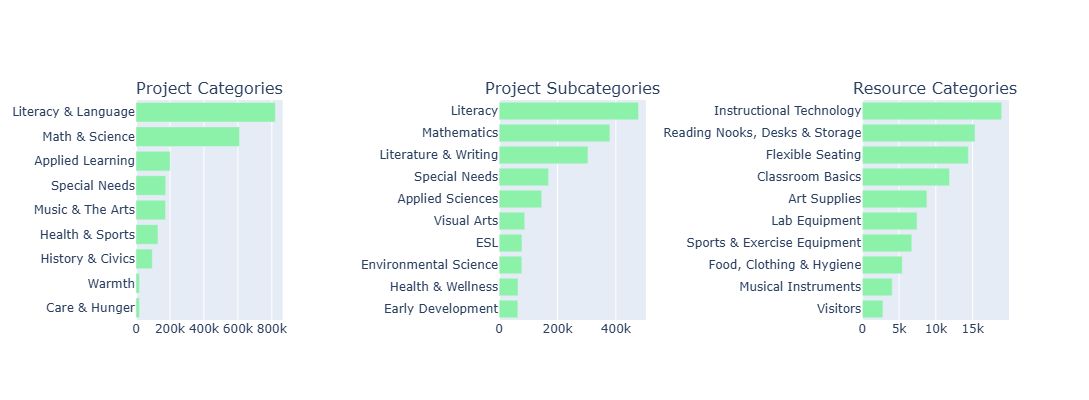

In [48]:
projects_df['Posted Date'] = pd.to_datetime(projects_df['Project Posted Date'])
projects_df['Posted Year'] = projects_df['Posted Date'].dt.year
projects_df['Posted Month'] = projects_df['Posted Date'].dt.month
projects_df['Posted Day'] = projects_df['Posted Date'].dt.weekday
projects_df['Posted Quarter'] = projects_df['Posted Date'].dt.quarter
projects_df['Funded Date'] = pd.to_datetime(projects_df['Project Fully Funded Date'])
projects_df['Funded Year'] = projects_df['Funded Date'].dt.year
projects_df['Funded Month'] = projects_df['Funded Date'].dt.month
projects_df['Funded Day'] = projects_df['Funded Date'].dt.weekday
projects_df['Funded Quarter'] = projects_df['Funded Date'].dt.quarter
projects_df['Funding Time'] = projects_df['Funded Date'] - projects_df['Posted Date']



t = projects_df['Project Subject Category Tree'].value_counts()
x = list(t.index)
y = list(t.values)
r = {}
for i,val in enumerate(x):
    for each in val.split(","):
        x1 = each.strip()
        if x1 not in r:
            r[x1] = y[i]
        r[x1] += y[i]
sorted_x = list(sorted(r.items(), key=operator.itemgetter(1), reverse = True))[:10]
x1 = [a[0] for a in sorted_x][::-1]
y1 = [a[1] for a in sorted_x][::-1]



t1 = projects_df['Project Subject Subcategory Tree'].value_counts()
x2 = list(t1.index)
y2 = list(t1.values)
r = {}
for i,val in enumerate(x2):
    for each in val.split(","):
        x1_ = each.strip()
        if x1_ not in r:
            r[x1_] = y2[i]
        r[x1_] += y2[i]
x2 = r.keys()
y2 = r.values()
sorted_x = list(sorted(r.items(), key=operator.itemgetter(1), reverse = True))[:10]
x2 = [a[0] for a in sorted_x][::-1]
y2 = [a[1] for a in sorted_x][::-1]

t = projects_df['Project Resource Category'].value_counts()
x3 = list(t.index[::-1])[:10]
y3 = list(t.values[::-1])[:10]


trace1 = bar_hor_noagg(x1, y1, "", "#8cf2a9", 600, 400, 10, rt=True)
trace2 = bar_hor_noagg(x2, y2, "", "#8cf2a9", 600, 400, 10, rt=True)
trace3 = bar_hor_noagg(x3, y3, "", "#8cf2a9", 600, 400, 10, rt=True)

fig = tools.make_subplots(rows=1, cols=5, print_grid=False, subplot_titles = ['Project Categories' ,"", 'Project Subcategories', '', "Resource Categories"])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 3);
fig.append_trace(trace3, 1, 5);
fig['layout'].update(height=400, showlegend=False, margin=dict(l=120));
iplot(fig);

## **7.3 Tipos y estados de los proyectos**
Gráficos que visualizan la distribución de tipos de proyectos (ej: donación puntual, proyecto de duración variable) y sus estados (ej: financiado, en progreso, finalizado). Permite entender el ciclo de vida de los proyectos en la plataforma.

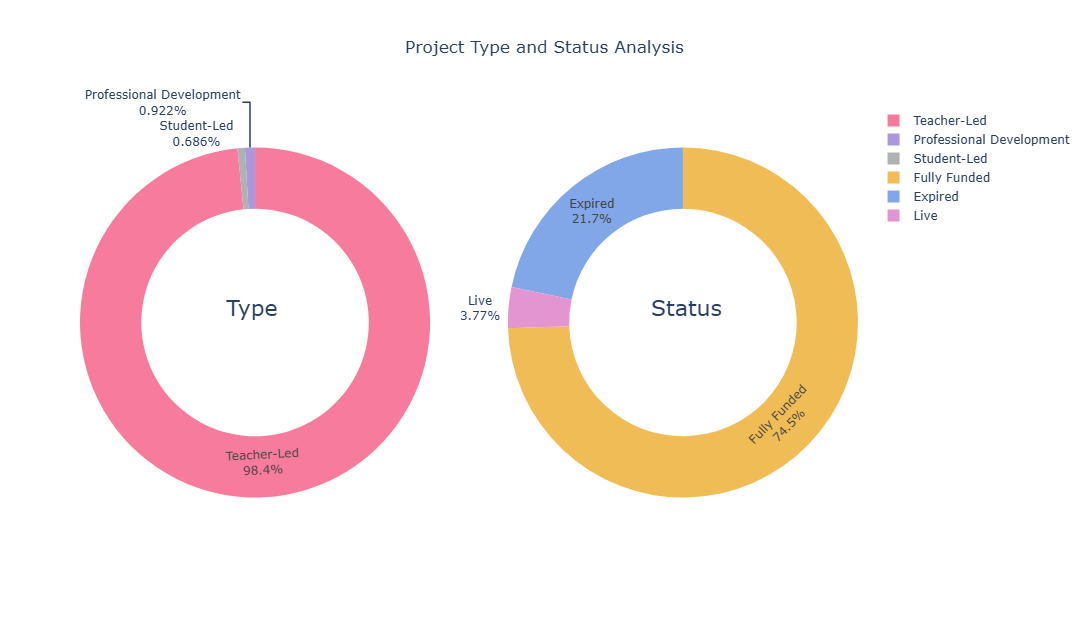

In [49]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

project_type = projects_df['Project Type'].value_counts()

project_status = projects_df['Project Current Status'].value_counts()

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{'type': 'domain'}, {'type': 'domain'}]],
    subplot_titles=(
        'Project Type Distribution',
        'Project Status Distribution'
    )
)

fig.add_trace(
    go.Pie(
        labels=project_type.index,
        values=project_type.values,
        hole=0.65,
        marker=dict(
            colors=[
                '#f77b9c',
                '#ab97db',
                '#b0b1b2'
            ]
        ),
        textinfo='percent+label'
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Pie(
        labels=project_status.index,
        values=project_status.values,
        hole=0.65,
        marker=dict(
            colors=[
                '#efbc56',
                '#81a7e8',
                '#e295d0',
                '#76c893',
                '#f28482'
            ]
        ),
        textinfo='percent+label'
    ),
    row=1,
    col=2
)

fig.update_layout(
    template='plotly_white',
    title={
        'text': 'Project Type and Status Analysis',
        'x': 0.5
    },
    width=1200,
    height=600,
    annotations=[
        dict(
            text='Type',
            x=0.22,
            y=0.5,
            font_size=22,
            showarrow=False
        ),
        dict(
            text='Status',
            x=0.78,
            y=0.5,
            font_size=22,
            showarrow=False
        )
    ]
)

fig.show()


## **7.4 Patrones de publicación por día de la semana**
Gráfico de barras que muestra en qué días de la semana se publican más proyectos en DonorsChoose. Identifica si hay preferencias por ciertos días (ej: más publicaciones a inicio de semana o antes del fin de semana).

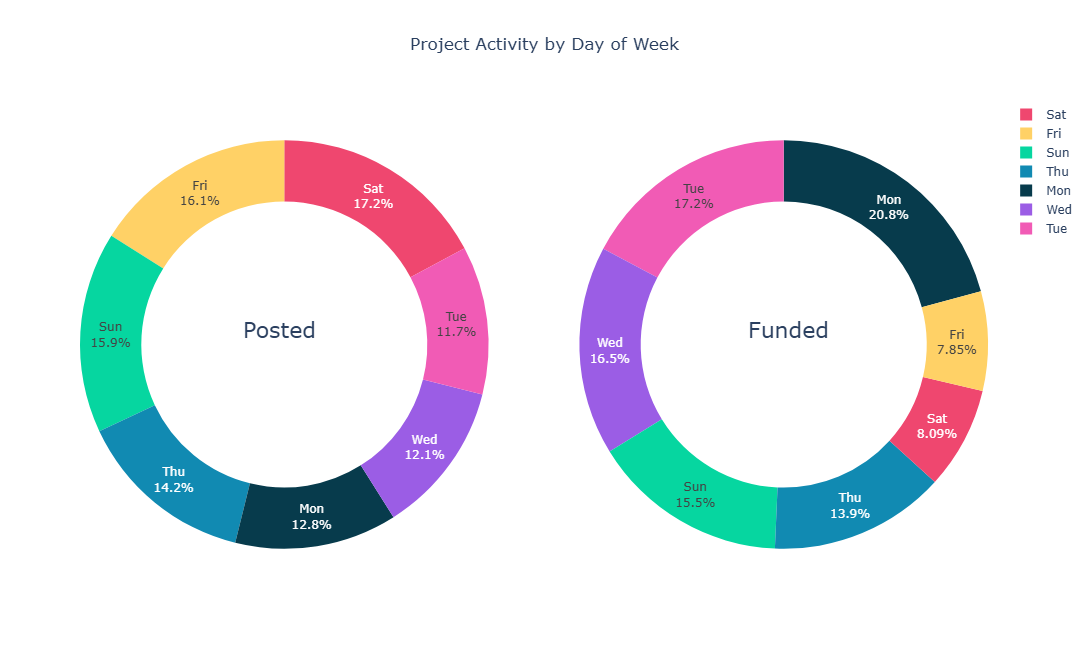

In [50]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

posted_counts = projects_df['Posted Day'].value_counts()
funded_counts = projects_df['Funded Day'].value_counts()

day_map = {
    0: 'Sun',
    1: 'Mon',
    2: 'Tue',
    3: 'Wed',
    4: 'Thu',
    5: 'Fri',
    6: 'Sat'
}

posted_days = [day_map[x] for x in posted_counts.index]
posted_values = posted_counts.values

funded_dict = {
    day_map[k]: v
    for k, v in funded_counts.items()
}

funded_values = [
    funded_dict.get(day, 0)
    for day in posted_days
]

colors = [
    '#ef476f',
    '#ffd166',
    '#06d6a0',
    '#118ab2',
    '#073b4c',
    '#9b5de5',
    '#f15bb5'
]

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{'type': 'domain'}, {'type': 'domain'}]],
    subplot_titles=(
        'Projects Posted by Day',
        'Projects Funded by Day'
    )
)

fig.add_trace(
    go.Pie(
        labels=posted_days,
        values=posted_values,
        hole=0.70,
        marker=dict(colors=colors),
        textinfo='percent+label'
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Pie(
        labels=posted_days,
        values=funded_values,
        hole=0.70,
        marker=dict(colors=colors),
        textinfo='percent+label'
    ),
    row=1,
    col=2
)

fig.update_layout(
    template='plotly_white',
    title={
        'text': 'Project Activity by Day of Week',
        'x': 0.5
    },
    width=1300,
    height=650,
    annotations=[
        dict(
            text='Posted',
            x=0.22,
            y=0.5,
            showarrow=False,
            font=dict(size=22)
        ),
        dict(
            text='Funded',
            x=0.78,
            y=0.5,
            showarrow=False,
            font=dict(size=22)
        )
    ]
)

fig.show()

## **7.5 Estacionalidad trimestral de publicaciones**
Serie temporal trimestral que muestra cómo varía la cantidad de proyectos publicados en cada trimestre del año. Permite identificar si hay épocas del año con mayor o menor actividad de publicación.

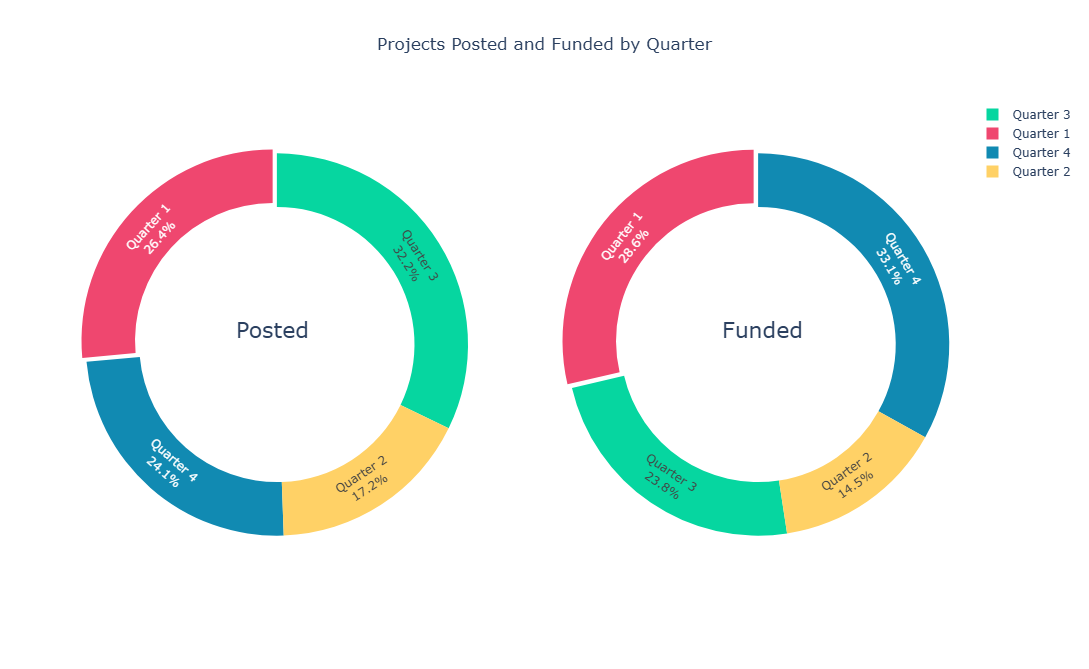

In [51]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

posted_counts = projects_df['Posted Quarter'].value_counts()
funded_counts = projects_df['Funded Quarter'].value_counts()

quarter_map = {
    1.0: 'Quarter 1',
    2.0: 'Quarter 2',
    3.0: 'Quarter 3',
    4.0: 'Quarter 4'
}

quarters = [
    'Quarter 1',
    'Quarter 2',
    'Quarter 3',
    'Quarter 4'
]

posted_dict = {
    quarter_map[k]: v
    for k, v in posted_counts.items()
    if k in quarter_map
}

funded_dict = {
    quarter_map[k]: v
    for k, v in funded_counts.items()
    if k in quarter_map
}

posted_values = [
    posted_dict.get(q, 0)
    for q in quarters
]

funded_values = [
    funded_dict.get(q, 0)
    for q in quarters
]

colors = [
    '#ef476f',
    '#ffd166',
    '#06d6a0',
    '#118ab2'
]

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{'type': 'domain'}, {'type': 'domain'}]],
    subplot_titles=(
        'Projects Posted by Quarter',
        'Projects Funded by Quarter'
    )
)

fig.add_trace(
    go.Pie(
        labels=quarters,
        values=posted_values,
        hole=0.72,
        marker=dict(colors=colors),
        textinfo='percent+label',
        pull=[0.03, 0, 0, 0]
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Pie(
        labels=quarters,
        values=funded_values,
        hole=0.72,
        marker=dict(colors=colors),
        textinfo='percent+label',
        pull=[0.03, 0, 0, 0]
    ),
    row=1,
    col=2
)

fig.update_layout(
    template='plotly_white',
    title={
        'text': 'Projects Posted and Funded by Quarter',
        'x': 0.5
    },
    width=1300,
    height=650,
    annotations=[
        dict(
            text='Posted',
            x=0.22,
            y=0.5,
            showarrow=False,
            font=dict(size=22)
        ),
        dict(
            text='Funded',
            x=0.78,
            y=0.5,
            showarrow=False,
            font=dict(size=22)
        )
    ]
)

fig.show()

## **7.6 Distribución mensual de proyectos publicados**
Gráfico de barras que visualiza la cantidad de proyectos publicados en cada mes del año. Muestra patrones de estacionalidad mensual (ej: picos en septiembre o enero, cuando comienzan ciclos escolares).

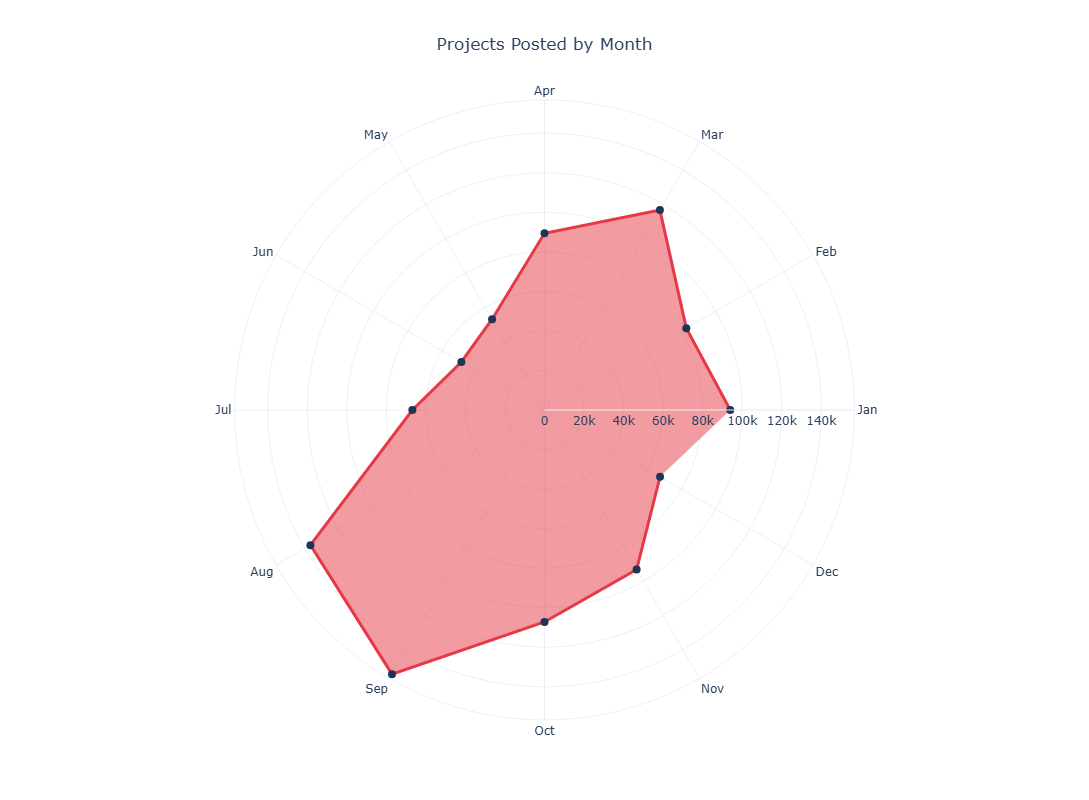

In [52]:
import pandas as pd
import plotly.graph_objects as go

month_map = {
    1: 'Jan',
    2: 'Feb',
    3: 'Mar',
    4: 'Apr',
    5: 'May',
    6: 'Jun',
    7: 'Jul',
    8: 'Aug',
    9: 'Sep',
    10: 'Oct',
    11: 'Nov',
    12: 'Dec'
}

temp = (
    projects_df['Posted Month']
    .value_counts()
    .sort_index()
)

months = [month_map[m] for m in temp.index]
counts = temp.values

fig = go.Figure()

fig.add_trace(
    go.Scatterpolar(
        r=counts,
        theta=months,
        fill='toself',
        line=dict(
            color='#e63946',
            width=3
        ),
        marker=dict(
            size=8,
            color='#1d3557'
        ),
        name='Projects'
    )
)

fig.update_layout(
    template='plotly_white',
    title={
        'text': 'Projects Posted by Month',
        'x': 0.5
    },
    polar=dict(
        radialaxis=dict(
            visible=True
        )
    ),
    width=800,
    height=800,
    showlegend=False
)

fig.show()

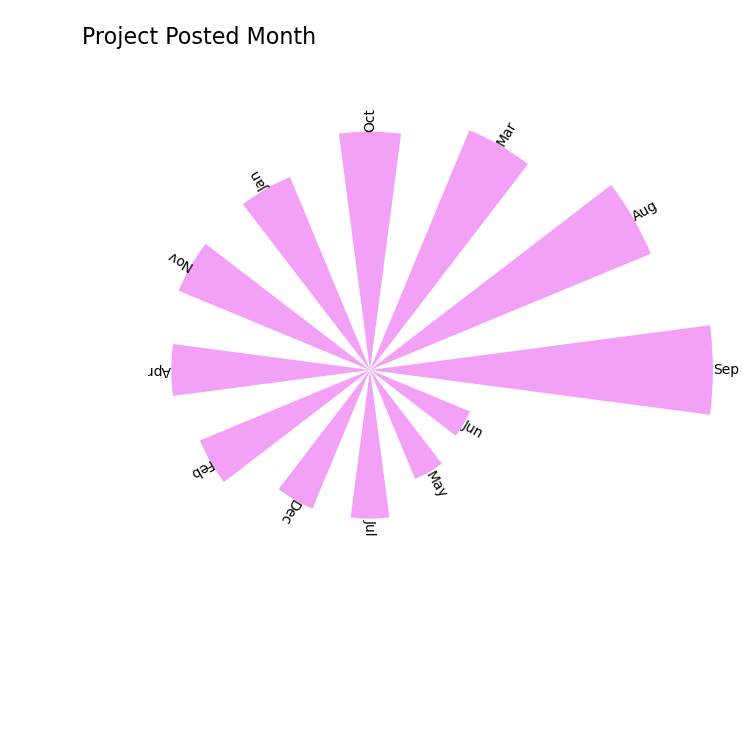

In [53]:
t = projects_df['Posted Month'].value_counts()


lObjectsALLcnts = list(t.values)

lObjectsALLlbls = list(t.index)
mapp1 = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
lObjectsALLlbls = [mapp1[x] for x in lObjectsALLlbls]

iN = len(lObjectsALLcnts)
arrCnts = np.array(lObjectsALLcnts)

theta=np.arange(0, 2*np.pi, 2*np.pi/iN)
width = (2*np.pi)/iN *0.5
bottom = 50

fig = plt.figure(figsize=(8,8))
ax = fig.add_axes([0.2, 0.1, 1, 0.9], polar=True)
fig.suptitle('Project Posted Month   ', fontsize=16)
bars = ax.bar(theta, arrCnts, width=width, bottom=bottom, color='#f3a0f7')
plt.axis('off')

rotations = np.rad2deg(theta)
for x, bar, rotation, label in zip(theta, bars, rotations, lObjectsALLlbls):
    lab = ax.text(x,bottom+bar.get_height() , label, ha='left', va='center', rotation=rotation, rotation_mode="anchor",)
plt.show()


## 7.7 En qué año se publicaron los proyectos
Evolución anual de la publicación de proyectos.

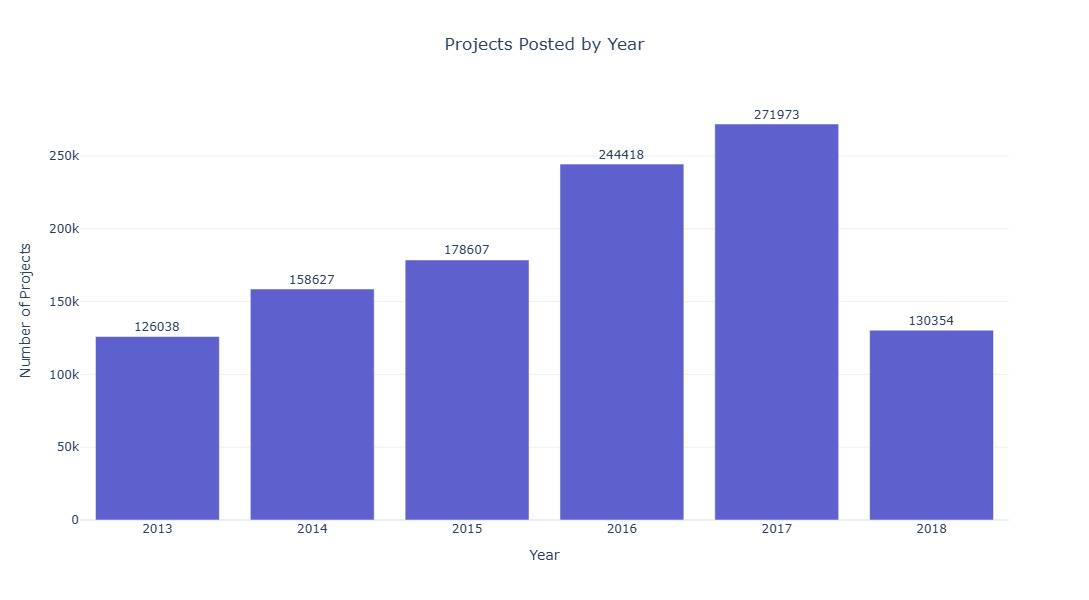

In [54]:
import plotly.graph_objects as go

t = (
    projects_df
    .groupby('Posted Year')
    .agg({'Posted Month': 'count'})
    .reset_index()
    .sort_values('Posted Year')
)

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=t['Posted Year'],
        y=t['Posted Month'],
        marker_color='#5e60ce',
        text=t['Posted Month'],
        textposition='outside'
    )
)

fig.update_layout(
    template='plotly_white',
    title={
        'text': 'Projects Posted by Year',
        'x': 0.5
    },
    xaxis_title='Year',
    yaxis_title='Number of Projects',
    width=1000,
    height=600
)

fig.show()

## **7.8 ¿En qué año y mes el costo promedio de los proyectos es más alto?**

En esta sección se analiza el costo promedio de los proyectos según el mes y el año en que fueron publicados. Para ello, primero se convierte la columna Project Cost a un formato numérico, eliminando los símbolos de moneda y separadores de miles. Posteriormente, se agrupan los datos por Posted Month y Posted Year, calculando el costo promedio de los proyectos en cada combinación.

Finalmente, se genera un gráfico de burbujas donde cada punto representa un mes y un año específicos. El tamaño de cada burbuja es proporcional al costo promedio de los proyectos, lo que permite identificar fácilmente los períodos en los que se registraron los mayores costos.

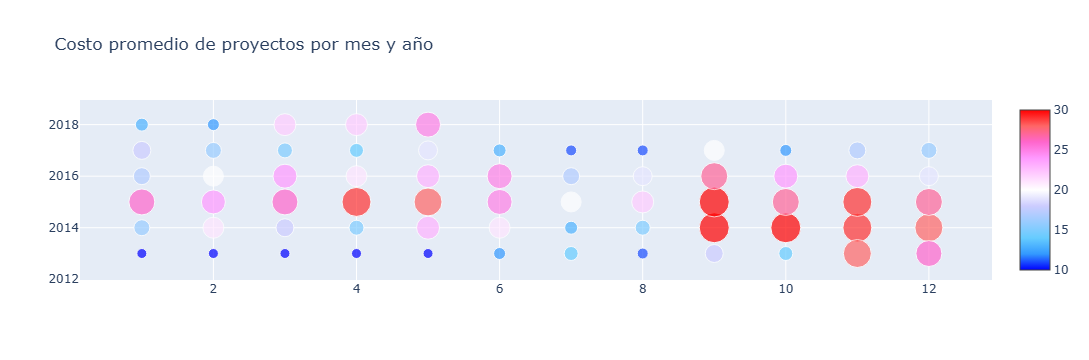

In [55]:
# Convertir el costo del proyecto a formato numérico
projects_df['cost'] = (
    projects_df['Project Cost']
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
    .astype(float)
)

def cbp(df, col1, col2, aggcol, func, title, colorscale, bottom_margin=False):
    # Agrupar los datos
    tempdf = (
        df.groupby([col1, col2])[aggcol]
        .agg(func)
        .reset_index()
    )

    tempdf[aggcol] = tempdf[aggcol].astype(int)

    # Ordenar por el valor agregado
    tempdf = tempdf.sort_values(by=aggcol, ascending=False)

    # Asignar tamaños a las burbujas
    sizes = list(reversed(range(10, 31)))
    intervals = max(1, len(tempdf) // len(sizes))

    size_array = [10] * len(tempdf)

    start = 0
    for size in sizes:
        end = min(start + intervals, len(tempdf))
        for i in range(start, end):
            size_array[i] = size
        start = end

    tempdf["size"] = size_array

    # Crear gráfico
    trace = go.Scatter(
        x=tempdf[col1],
        y=tempdf[col2],
        mode="markers",
        text=tempdf[aggcol],
        marker=dict(
            size=tempdf["size"],
            color=tempdf["size"],
            colorscale=colorscale,
            showscale=True
        )
    )

    layout = go.Layout(
        title=title,
        margin=dict(b=150) if bottom_margin else dict()
    )

    fig = go.Figure(data=[trace], layout=layout)
    iplot(fig)

# Generar gráfico
cbp(
    projects_df,
    'Posted Month',
    'Posted Year',
    'cost',
    'mean',
    'Costo promedio de proyectos por mes y año',
    'Picnic'
)


## **7.9 ¿En qué año y categoría de grado escolar el costo de los proyectos es más alto?**

Se analiza el costo promedio de los proyectos según el año de publicación y la categoría de grado escolar. El gráfico de burbujas permite identificar qué niveles educativos y años presentan los mayores costos promedio de los proyectos.

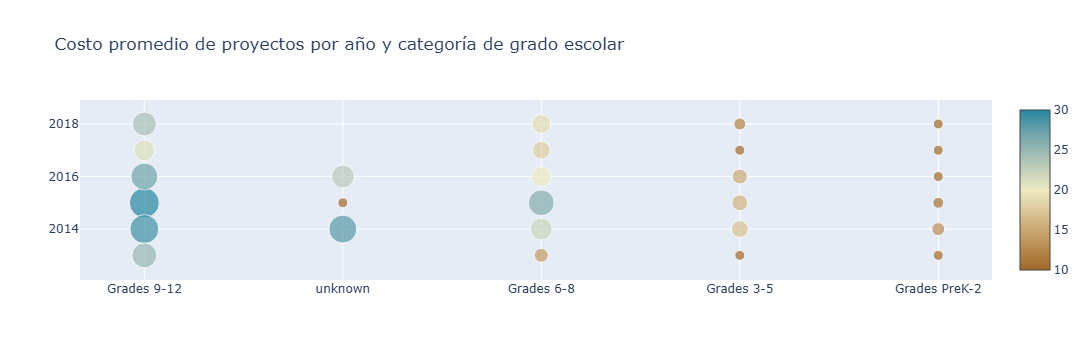

In [56]:
cbp(
    projects_df,
    'Project Grade Level Category',
    'Posted Year',
    'cost',
    'mean',
    'Costo promedio de proyectos por año y categoría de grado escolar',
    'Earth'
)

## **7.10 Categorías de grado escolar y categorías de recursos con los costos más altos de los proyectos**

Se analiza el costo promedio de los proyectos según la categoría de recursos y el nivel educativo al que están dirigidos. El gráfico de burbujas permite identificar qué combinaciones presentan los mayores costos promedio.

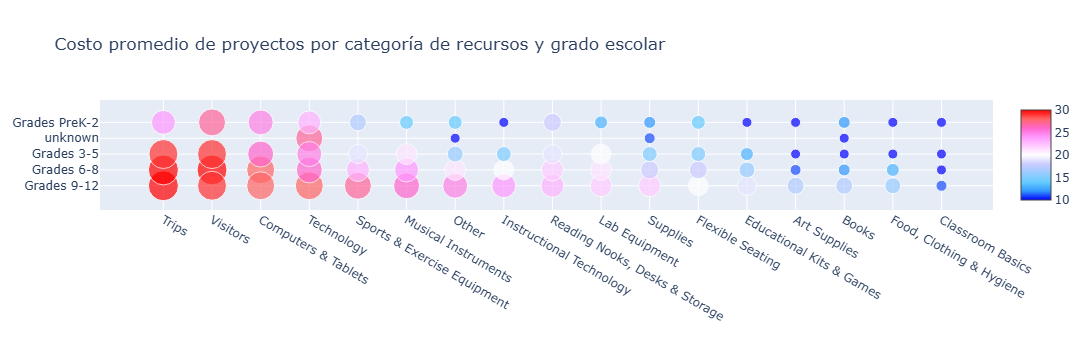

In [57]:
cbp(
    projects_df,
    'Project Resource Category',
    'Project Grade Level Category',
    'cost',
    'mean',
    'Costo promedio de proyectos por categoría de recursos y grado escolar',
    'Picnic',
    bottom_margin=150
)

## **7.11 ¿Cómo varía el estado de los proyectos según el año?**

Se analiza la distribución del estado de los proyectos para cada año mediante gráficos circulares. Esto permite comparar la proporción de proyectos completados, financiados y con otros estados a lo largo del tiempo.

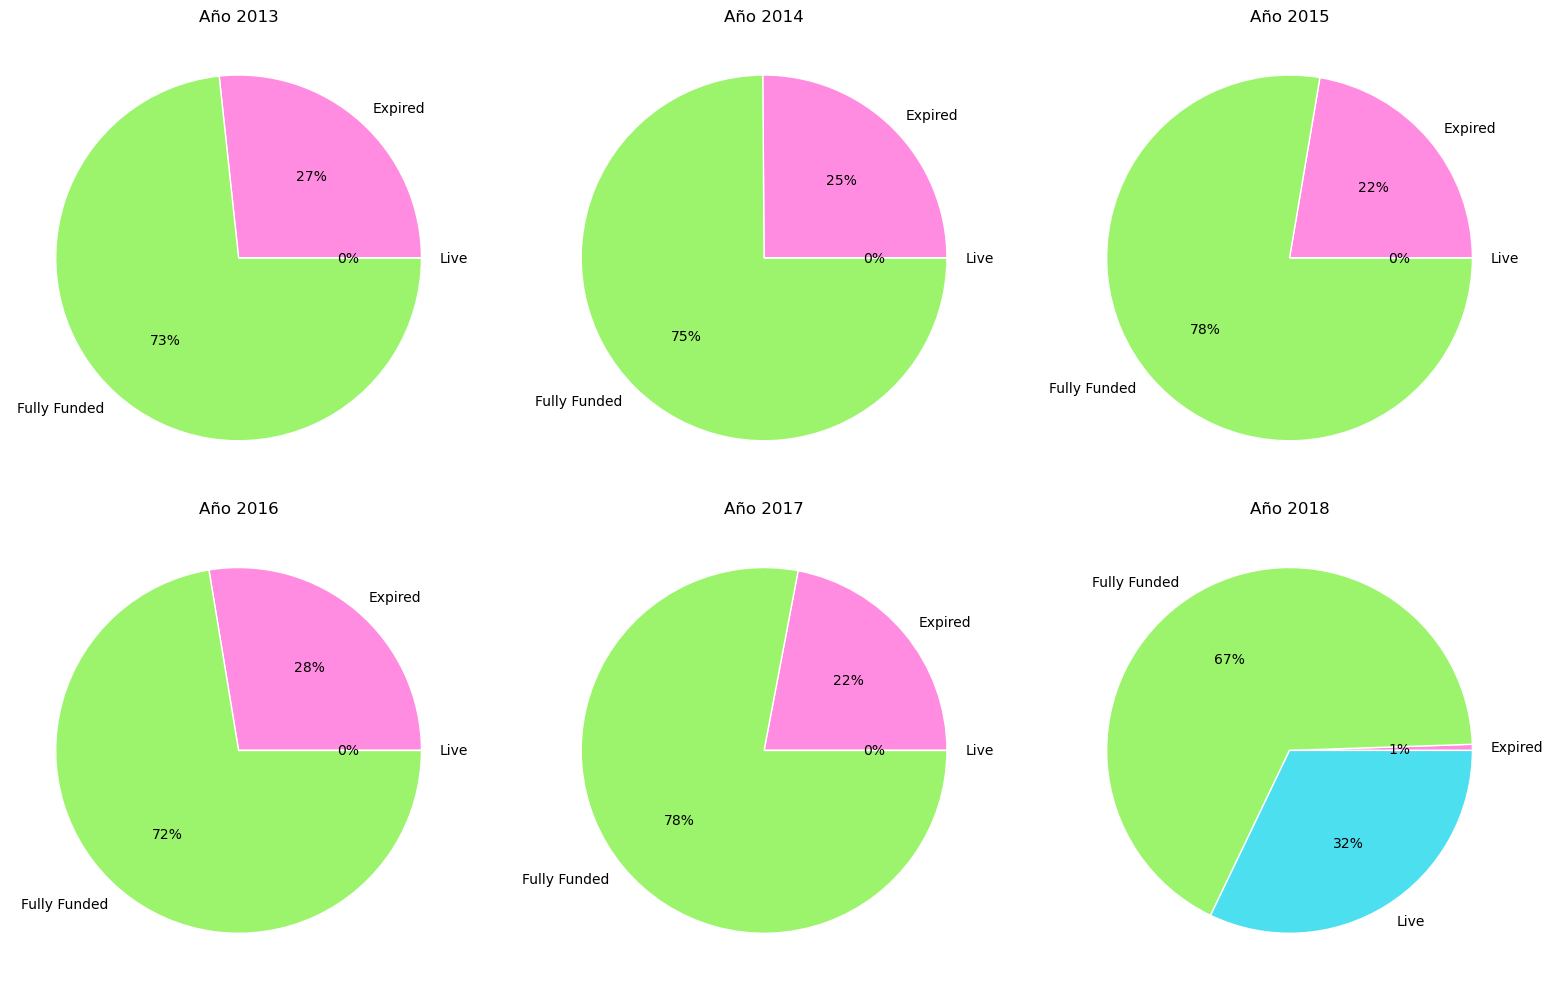

In [58]:
years = [2013, 2014, 2015, 2016, 2017, 2018]

plt.figure(figsize=(16,10))

for j, year in enumerate(years):
    ax = plt.subplot(2,3,j+1)

    if year in year_tab.columns and year_tab[year].sum() > 0:
        ax.pie(
            year_tab[year],
            labels=year_tab.index,
            autopct="%1.0f%%",
            colors=["#ff8ce0", "#9bf46b", "#4cdfef"],
            wedgeprops={"linewidth":1, "edgecolor":"white"}
        )
        ax.set_title(f"Año {year}")
    else:
        ax.axis("off")   # Oculta el cuadro vacío

plt.tight_layout()
plt.show()

## **7.12 ¿Durante cuántos días permanecieron activos los proyectos?**

Se analiza el tiempo que tardaron en financiarse completamente los proyectos. El histograma muestra la distribución del número de días requeridos para alcanzar el estado de "Fully Funded", permitiendo identificar los tiempos de financiamiento más frecuentes.

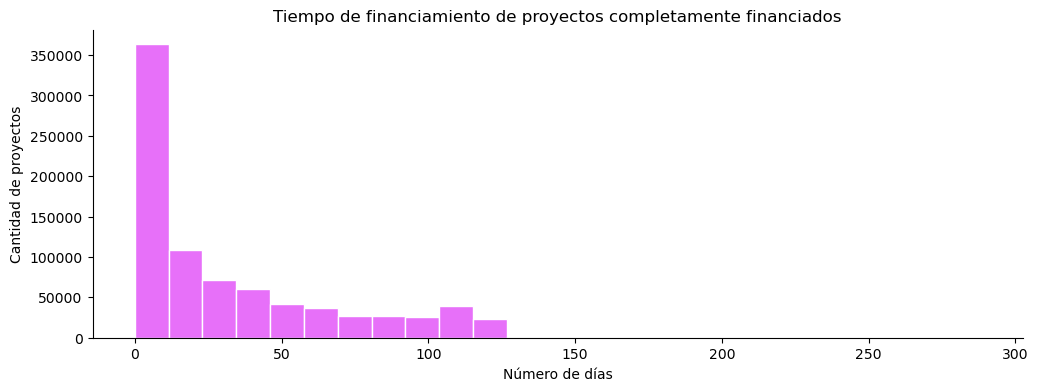

In [59]:
# Filtrar proyectos completamente financiados
t = projects_df[projects_df['Project Current Status'] == "Fully Funded"].copy()

# Convertir el tiempo de financiamiento a días
t['Funding Time'] = t['Funding Time'].apply(lambda x: int(str(x).split()[0]))

# Histograma
plt.figure(figsize=(12, 4))

ax = t['Funding Time'].hist(
    bins=25,
    edgecolor='white',
    color="#e770f9"
)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Número de días')
plt.ylabel('Cantidad de proyectos')
plt.title('Tiempo de financiamiento de proyectos completamente financiados')

plt.show()

## **7.13 ¿Cómo varía la proporción de proyectos financiados y no financiados por estado?**

Se analiza el porcentaje de proyectos financiados y no financiados en cada estado. Los gráficos de barras permiten comparar la proporción de ambos tipos de proyectos e identificar los estados con mayor y menor tasa de financiamiento.

In [60]:
# Unir proyectos y escuelas
projsch_df = projects_df.merge(schools_df, on="School ID")

# Obtener los estados existentes
states = sorted(projsch_df["School State"].dropna().unique())

# Tomar los primeros 30
states = states[:30]

In [61]:
print(schools_df.columns)

Index(['School ID', 'School Name', 'School Metro Type',
       'School Percentage Free Lunch', 'School State', 'School Zip',
       'School City', 'School County', 'School District'],
      dtype='object')


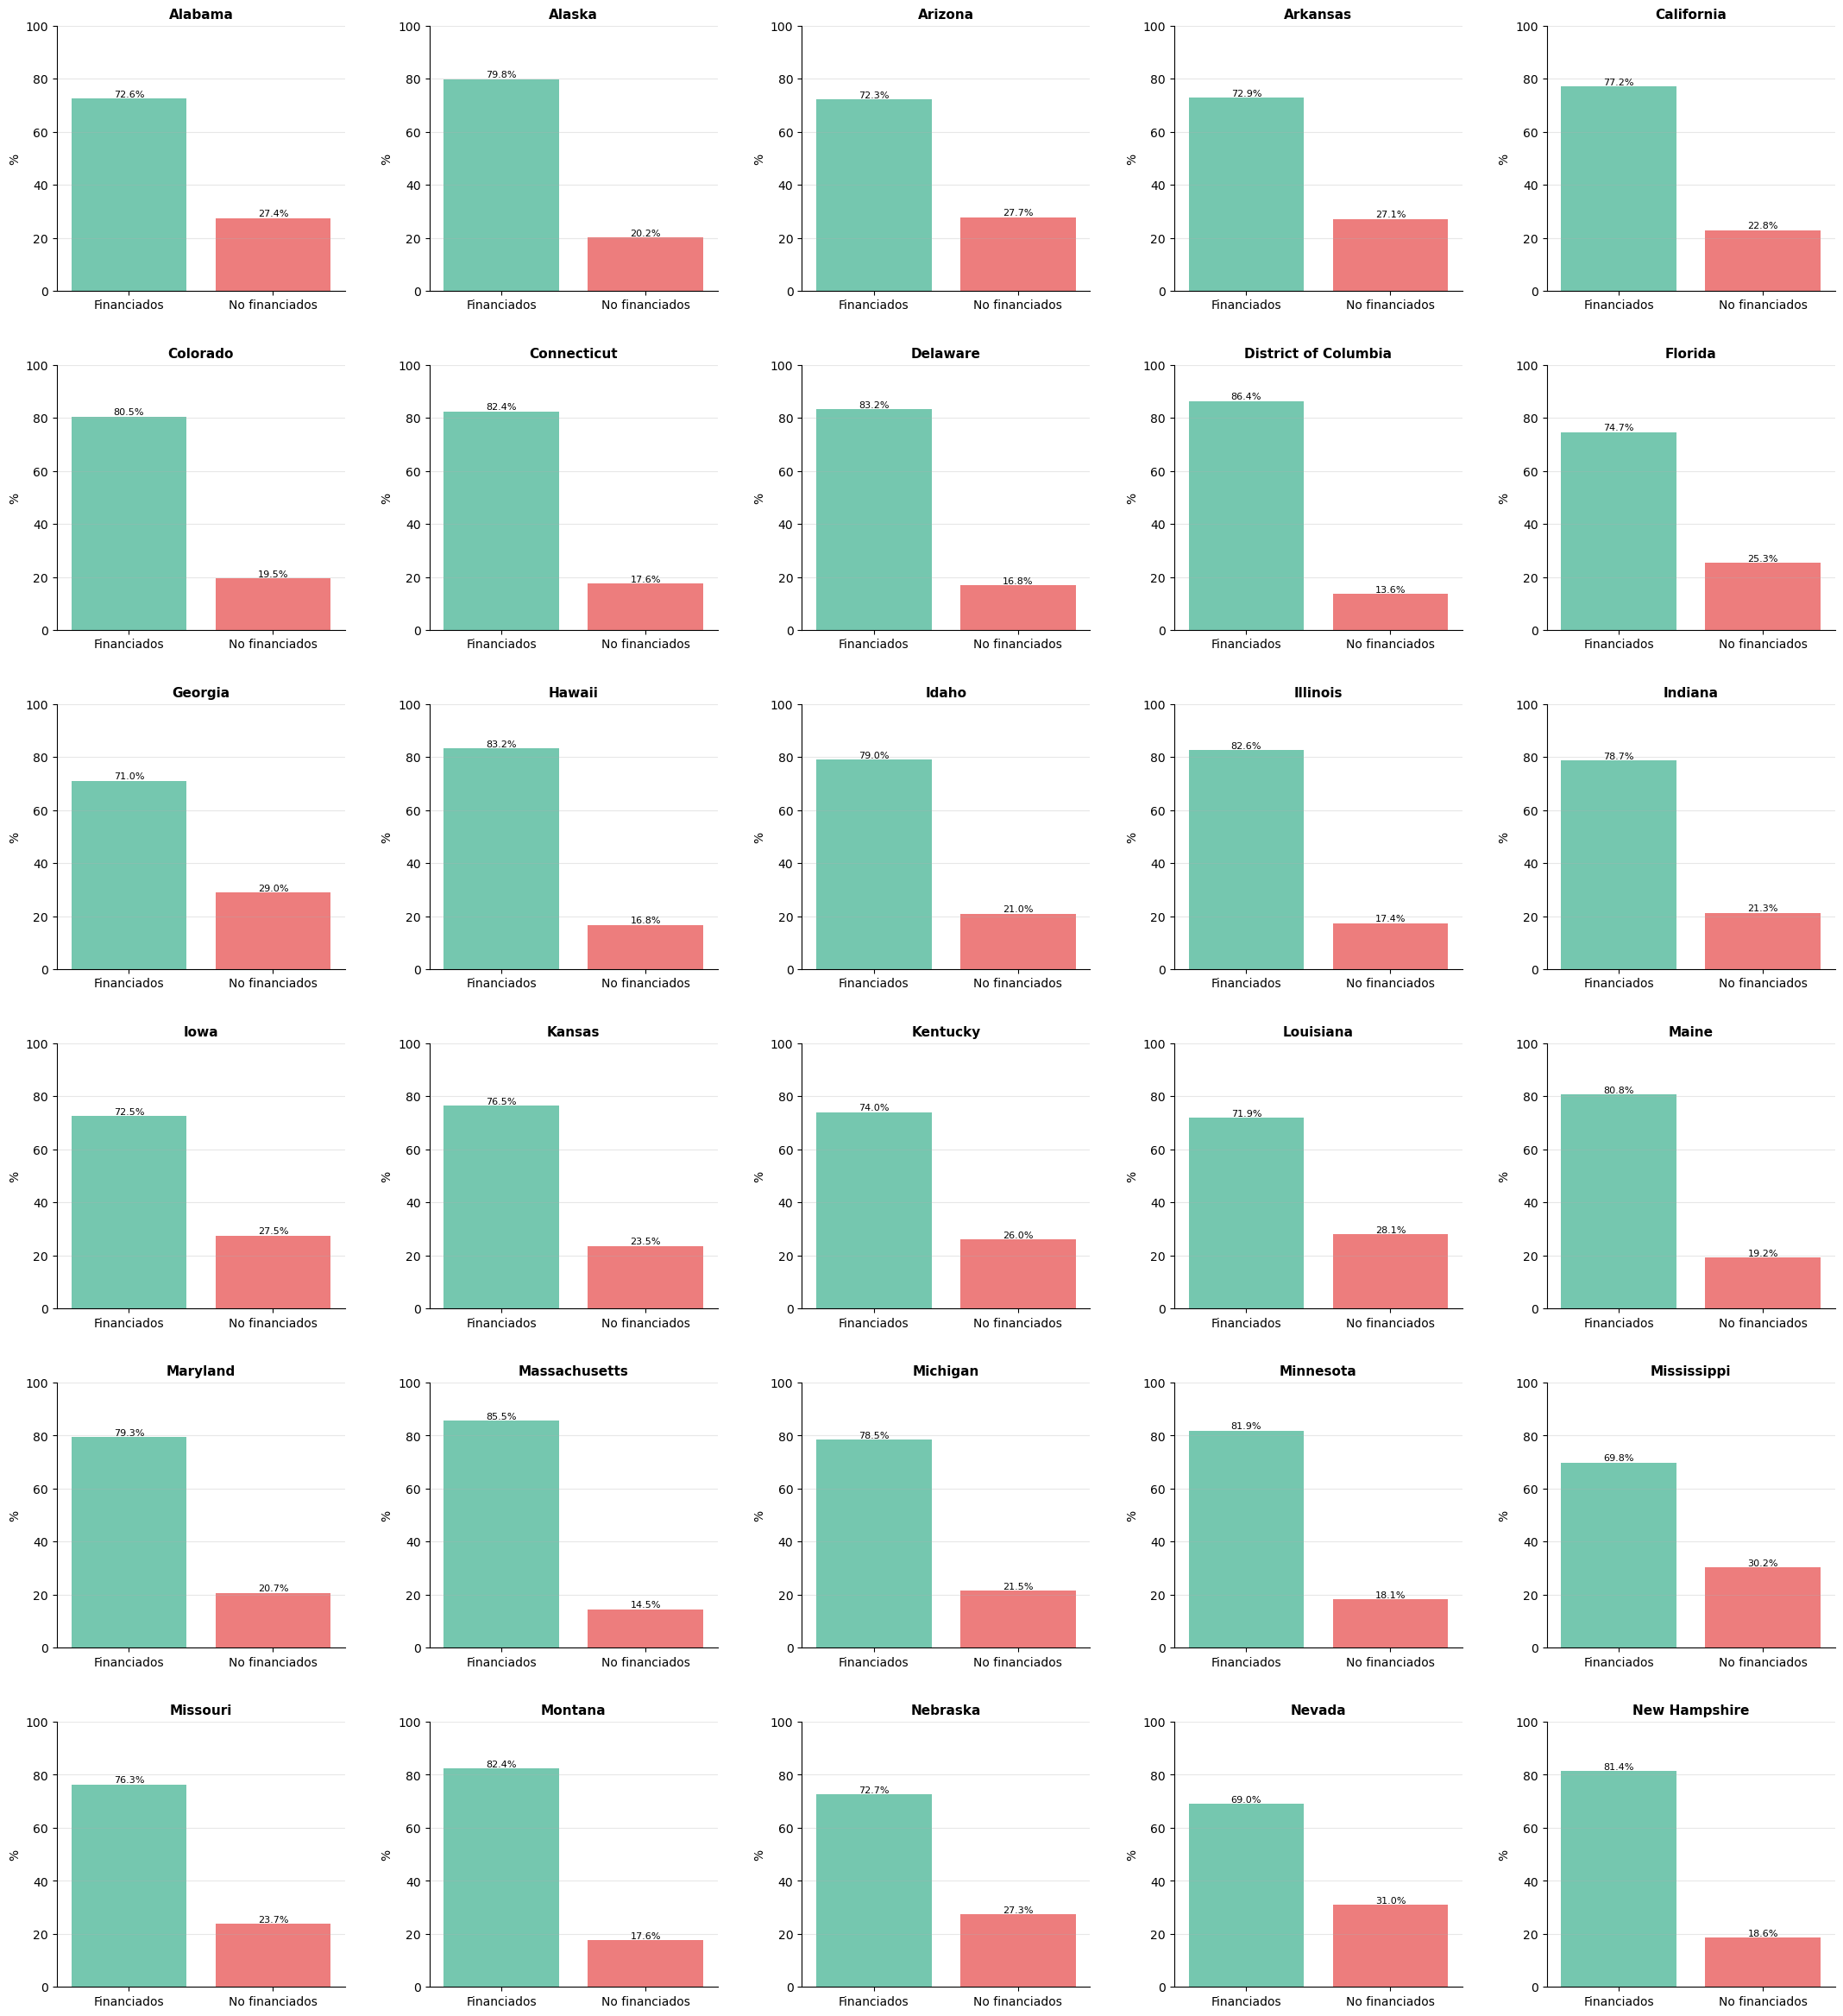

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
import itertools

# Unir los DataFrames
projsch_df = projects_df.merge(schools_df, on="School ID")

# Obtener los estados automáticamente
states = sorted(projsch_df["School State"].dropna().unique())[:30]

# Tamaño de la figura
fig, axes = plt.subplots(6, 5, figsize=(22, 24))
axes = axes.flatten()

for ax, state in zip(axes, states):

    t = projsch_df.loc[
        projsch_df["School State"] == state,
        "Project Current Status"
    ].value_counts()

    funded = t.get("Fully Funded", 0)
    expired = t.get("Expired", 0)
    total = funded + expired

    if total > 0:

        sns.barplot(
            x=["Financiados", "No financiados"],
            y=[funded * 100 / total, expired * 100 / total],
            palette=["#67d5b5", "#ff6b6b"],
            ax=ax
        )

        ax.set_ylim(0, 100)
        ax.set_title(state, fontsize=11, fontweight="bold")
        ax.set_ylabel("%")
        ax.set_xlabel("")
        ax.grid(axis="y", alpha=0.3)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Mostrar el porcentaje encima de cada barra
        for p in ax.patches:
            ax.annotate(
                f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center',
                va='bottom',
                fontsize=8
            )

# Eliminar ejes vacíos
for ax in axes[len(states):]:
    fig.delaxes(ax)

plt.tight_layout(pad=3)
plt.show()

## **7.14 ¿Cuál es el costo promedio de los proyectos según el tipo de zona escolar y la categoría de recursos solicitados?**

Se analiza el costo promedio de los proyectos en función del tipo de zona escolar y la categoría de recursos solicitados. El gráfico de burbujas permite identificar las combinaciones con los mayores costos promedio.

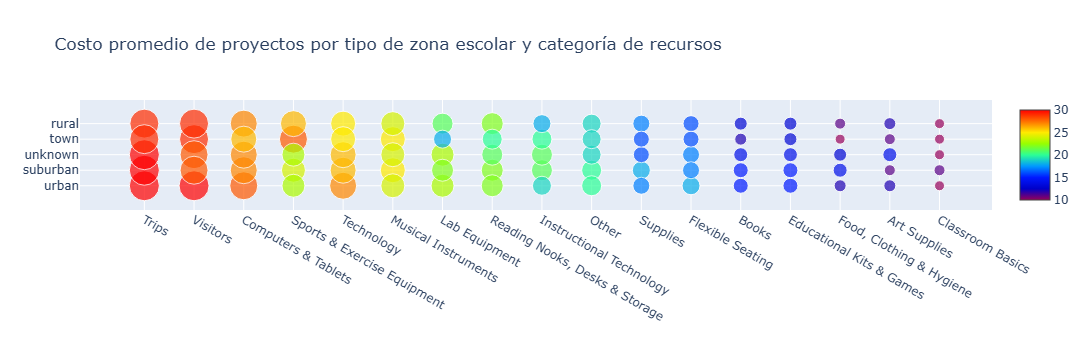

In [63]:
cbp(
    projsch_df,
    'Project Resource Category',
    'School Metro Type',
    'cost',
    'mean',
    'Costo promedio de proyectos por tipo de zona escolar y categoría de recursos',
    'Rainbow',
    bottom_margin=150
)

## **7.15 ¿Cuál es el costo promedio de los proyectos según el tipo de zona escolar y el nivel educativo?**

Se analiza el costo promedio de los proyectos considerando el tipo de zona escolar y la categoría de grado escolar. El gráfico de burbujas permite identificar las combinaciones que presentan los mayores costos promedio.

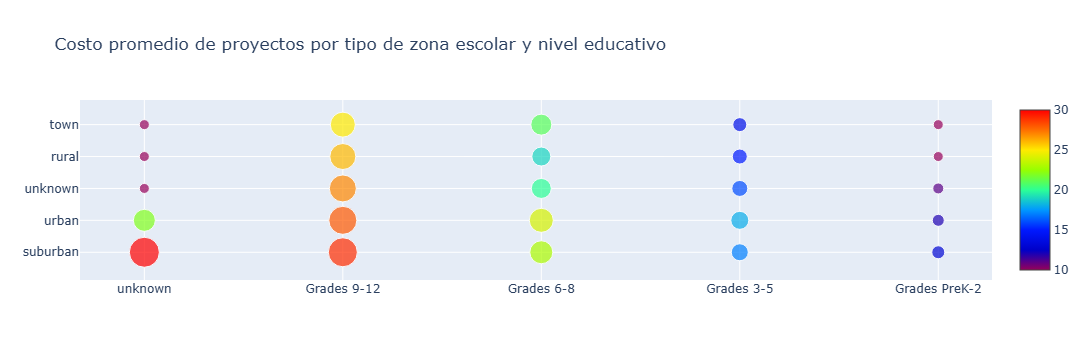

In [64]:
cbp(
    projsch_df,
    'Project Grade Level Category',
    'School Metro Type',
    'cost',
    'mean',
    'Costo promedio de proyectos por tipo de zona escolar y nivel educativo',
    'Rainbow'
)

# **8. Procesamiento de Lenguaje Natural para el Perfilado de Proyectos**


En esta sección se aplican técnicas básicas de Procesamiento de Lenguaje Natural (NLP) para analizar los textos de los ensayos y las necesidades de los proyectos. El objetivo es preparar la información textual eliminando palabras irrelevantes y caracteres innecesarios, facilitando análisis posteriores como la identificación de palabras frecuentes o temas de interés. Para este análisis se utilizan únicamente los proyectos publicados en abril de 2018.

## **8.1 Limpieza del texto**

Se implementa una función para limpiar y normalizar el texto. El proceso incluye convertir todo el contenido a minúsculas, eliminar signos de puntuación, remover palabras vacías (stopwords) y descartar términos poco relevantes, obteniendo un texto más limpio para su análisis.

In [65]:
print(projects_df.columns)

Index(['Project ID', 'School ID', 'Teacher ID',
       'Teacher Project Posted Sequence', 'Project Type', 'Project Title',
       'Project Essay', 'Project Short Description', 'Project Need Statement',
       'Project Subject Category Tree', 'Project Subject Subcategory Tree',
       'Project Grade Level Category', 'Project Resource Category',
       'Project Cost', 'Project Posted Date', 'Project Expiration Date',
       'Project Current Status', 'Project Fully Funded Date', 'Posted Year',
       'Posted Date', 'Posted Month', 'Posted Day', 'Posted Quarter',
       'Funded Date', 'Funded Year', 'Funded Month', 'Funded Day',
       'Funded Quarter', 'Funding Time', 'cost'],
      dtype='object')


In [66]:
!pip install nltk
!pip install textblob

# 1. Aseguramos la instalación e importamos nltk
import nltk
# DESCARGA DE RECURSOS: Esto soluciona tu LookupError actual
nltk.download('stopwords')

from nltk.corpus import stopwords
from textblob import TextBlob
import string
import pandas as pd

# Guardamos las stopwords en una variable con un nombre diferente
# para no sobreescribir el módulo importado
english_stopwords = stopwords.words("english")

def _clean(txt):
    # Si el texto es nulo, devolvemos un string vacío
    if pd.isna(txt):
        return ""

    # lower case
    txt = str(txt).lower()

    # punctuation removal
    txt = ''.join(x for x in txt if x not in string.punctuation)

    # stopwords and lemmatization
    clean_txt = ""
    for word in txt.split():
        if word in english_stopwords:  # Usamos la variable corregida
            continue
        clean_txt += " "
        clean_txt += word

    noise = ['students','my','title', 'would', 'every', 'will', 'many','also','donotremoveessaydivider']
    for ns in noise:
        clean_txt = clean_txt.replace(ns, "")

    return clean_txt.strip()

# --- CORRECCIÓN DE FECHAS ANTES DEL FILTRADO ---
# Como tu DataFrame original tiene 'Project Posted Date', extraemos el año y mes primero
projects_df['Project Posted Date'] = pd.to_datetime(projects_df['Project Posted Date'])
projects_df['Posted Year'] = projects_df['Project Posted Date'].dt.year
projects_df['Posted Month'] = projects_df['Project Posted Date'].dt.month

# En lugar de filtrar por año y mes, usamos una muestra grande de todo el dataset
# (por ejemplo, 20,000 filas para que no tarde horas en limpiar el texto)
april18_df = projects_df.sample(n=min(20000, len(projects_df)), random_state=42).copy()

print(f"Filas listas para procesar: {len(april18_df)}")
april18_df['clean_essay'] = april18_df['Project Essay'].apply(_clean)

# NOTA: Revisa si en tus columnas se llama 'Project Need Statement' o similar
# Si te da KeyError aquí, cámbialo por el nombre correcto de la columna de necesidades.
if 'Project Need Statement' in april18_df.columns:
    april18_df['clean_need'] = april18_df['Project Need Statement'].apply(_clean)
else:
    print("Nota: No se encontró la columna 'Project Need Statement', saltando ese paso.")

print("¡Limpieza terminada con éxito!")

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ------------------------------- ------ 524.3/625.0 kB 401.5 kB/s eta 0:00:01
   ---------------------------------------- 625.0/625.0 kB 431.6 kB/s  0:00:01


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC-10\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Filas listas para procesar: 20000
¡Limpieza terminada con éxito!


## **8.2 Análisis de Bolsa de Palabras (Bag of Words)**

### **8.2.1 ¿Cuáles son las palabras y frases más utilizadas por los docentes en los ensayos?**

Se realiza un análisis de frecuencia de palabras y frases utilizando la técnica Bag of Words. Se generan unigramas, bigramas y trigramas a partir de los ensayos limpios para identificar los términos y expresiones más utilizados por los docentes en la descripción de sus proyectos.

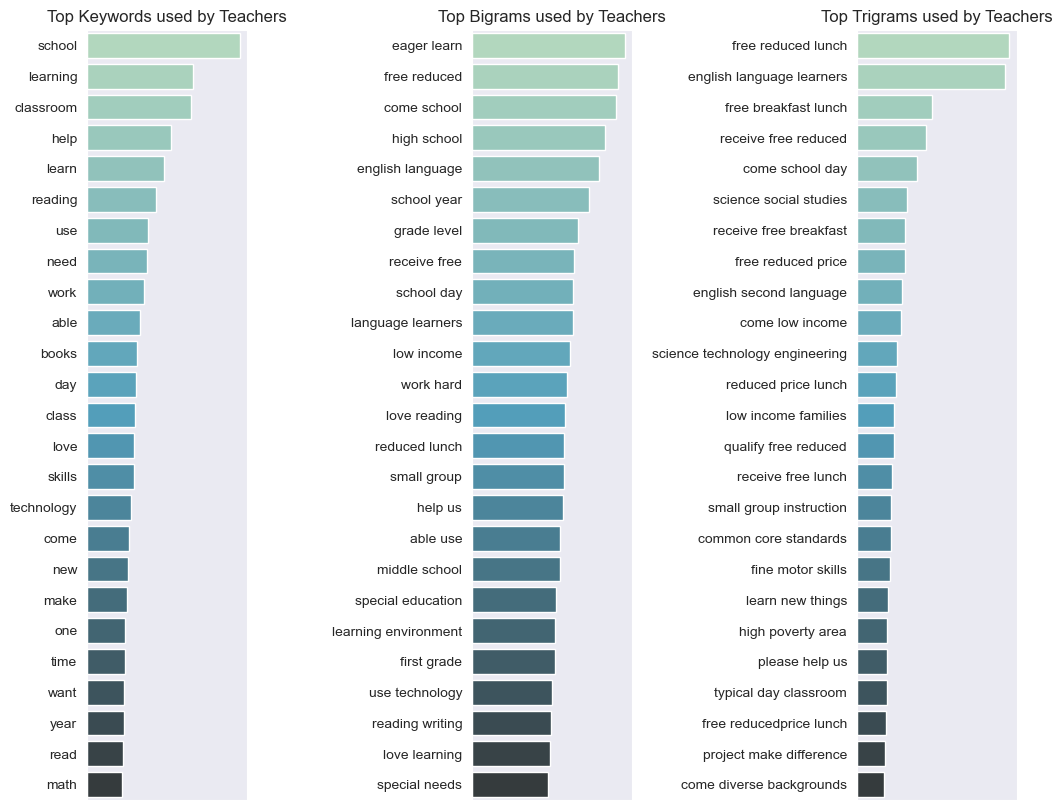

In [67]:
### Bag of Words
from collections import Counter
def generate_ngrams(txt, N):
    grams = [txt[i:i+N] for i in range(len(txt)-N+1)]
    grams = [" ".join(b) for b in grams]
    return grams

april18_df['unigrams'] = april18_df['clean_essay'].apply(lambda x : generate_ngrams(x.split(), 1))
april18_df['bigrams'] = april18_df['clean_essay'].apply(lambda x : generate_ngrams(x.split(), 2))
april18_df['trigrams'] = april18_df['clean_essay'].apply(lambda x : generate_ngrams(x.split(), 3))

all_unigrams = []
for each in april18_df['unigrams']:
    all_unigrams.extend(each)
t = Counter(all_unigrams).most_common(25)
x = [a[0] for a in t]
y = [a[1] for a in t]

all_bigrams = []
for each in april18_df['bigrams']:
    all_bigrams.extend(each)
t1 = Counter(all_bigrams).most_common(25)
x1 = [a[0] for a in t1]
y1 = [a[1] for a in t1]


all_trigrams = []
for each in april18_df['trigrams']:
    all_trigrams.extend(each)
t2 = Counter(all_trigrams).most_common(25)
x2 = [a[0] for a in t2]
y2 = [a[1] for a in t2]

sns.set_style("dark")
fig, axes = plt.subplots(nrows=1, ncols=5, squeeze=True, figsize = (12,10));

bar = sns.barplot(y=x, x=y, ax=axes[0], palette='GnBu_d', edgecolor="white");
bar.set(xlabel='', xticks=[]);
axes[0].set_title("Top Keywords used by Teachers");

fig.delaxes(axes[1]);

bar1 = sns.barplot(y=x1, x=y1, ax=axes[2], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[2].set_title("Top Bigrams used by Teachers");

fig.delaxes(axes[3]);

bar1 = sns.barplot(y=x2, x=y2, ax=axes[4], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[4].set_title("Top Trigrams used by Teachers");


### **8.2.2 ¿Cómo varían las frases más utilizadas según el estado?**

Se analizan las frases de tres palabras (trigramas) más frecuentes en los ensayos de docentes de diferentes estados. Esto permite comparar el lenguaje utilizado e identificar las expresiones más comunes en cada región.

In [68]:
print(schools_df.columns.tolist())

['School ID', 'School Name', 'School Metro Type', 'School Percentage Free Lunch', 'School State', 'School Zip', 'School City', 'School County', 'School District']


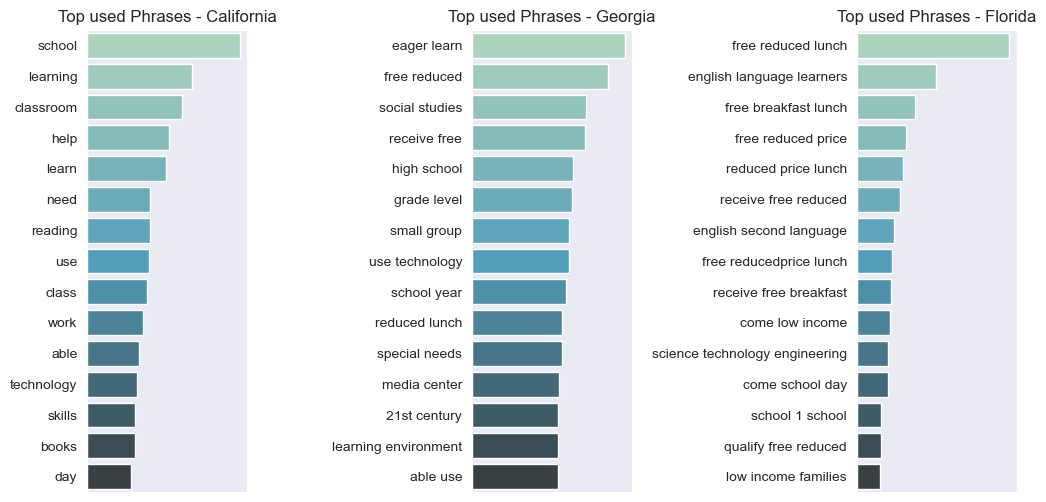

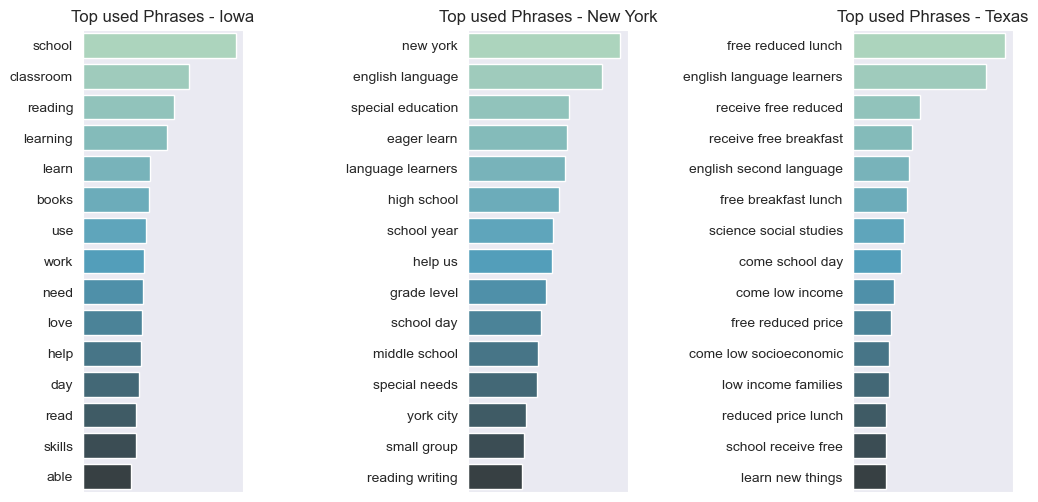

In [69]:
# 1. Pegamos esto al inicio para solucionar el KeyError de 'School State'
state_mapping = projsch_df.set_index('Project ID')['School State'].to_dict()
april18_df['School State'] = april18_df['Project ID'].map(state_mapping)

# --- Tu código original empieza aquí ---
ignores = ['every day', 'come school']
all_unigrams = []
for each in april18_df[april18_df['School State'] == 'California']['unigrams']: # <-- Cambié 'trigrams' por 'unigrams' para que salgan palabras solas
    all_unigrams.extend([x for x in each if x not in ignores])
t = Counter(all_unigrams).most_common(15)
x = [a[0] for a in t]
y = [a[1] for a in t]

all_bigrams = []
for each in april18_df[april18_df['School State'] == 'Georgia']['bigrams']: # <-- Cambié 'trigrams' por 'bigrams' para que salgan pares de palabras
    all_bigrams.extend([x for x in each if x not in ignores])
t1 = Counter(all_bigrams).most_common(15)
x1 = [a[0] for a in t1]
y1 = [a[1] for a in t1]

all_trigrams = []
for each in april18_df[april18_df['School State'] == 'Florida']['trigrams'] :
    all_trigrams.extend([x for x in each if x not in ignores])
t2 = Counter(all_trigrams).most_common(15)
x2 = [a[0] for a in t2]
y2 = [a[1] for a in t2]

sns.set_style("dark")
fig, axes = plt.subplots(nrows=1, ncols=5, squeeze=True, figsize = (12,6));

bar = sns.barplot(y=x, x=y, ax=axes[0], palette='GnBu_d', edgecolor="white");
bar.set(xlabel='', xticks=[]);
axes[0].set_title("Top used Phrases - California");

fig.delaxes(axes[1]);

bar1 = sns.barplot(y=x1, x=y1, ax=axes[2], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[2].set_title("Top used Phrases - Georgia");

fig.delaxes(axes[3]);

bar1 = sns.barplot(y=x2, x=y2, ax=axes[4], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[4].set_title("Top used Phrases - Florida");

all_unigrams = []
for each in april18_df[april18_df['School State'] == 'Iowa']['unigrams']: # <-- Cambié 'trigrams' por 'unigrams'
    all_unigrams.extend([x for x in each if x not in ignores])
t = Counter(all_unigrams).most_common(15)
x = [a[0] for a in t]
y = [a[1] for a in t]

all_bigrams = []
for each in april18_df[april18_df['School State'] == 'New York']['bigrams']: # <-- Cambié 'trigrams' por 'bigrams'
    all_bigrams.extend([x for x in each if x not in ignores])
t1 = Counter(all_bigrams).most_common(15)
x1 = [a[0] for a in t1]
y1 = [a[1] for a in t1]

all_trigrams = []
for each in april18_df[april18_df['School State'] == 'Texas']['trigrams']:
    all_trigrams.extend([x for x in each if x not in ignores])
t2 = Counter(all_trigrams).most_common(15)
x2 = [a[0] for a in t2]
y2 = [a[1] for a in t2]

sns.set_style("dark")
fig, axes = plt.subplots(nrows=1, ncols=5, squeeze=True, figsize = (12,6));

bar = sns.barplot(y=x, x=y, ax=axes[0], palette='GnBu_d', edgecolor="white");
bar.set(xlabel='', xticks=[]);
axes[0].set_title("Top used Phrases - Iowa");

fig.delaxes(axes[1]);

bar1 = sns.barplot(y=x1, x=y1, ax=axes[2], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[2].set_title("Top used Phrases - New York");

fig.delaxes(axes[3]);

bar1 = sns.barplot(y=x2, x=y2, ax=axes[4], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[4].set_title("Top used Phrases - Texas");


### **8.2.3 "Mis estudiantes son ______ ______ ______": ¿Cómo describen los docentes a sus estudiantes?**

Se analizan las frases que comienzan con "My students are" para identificar cómo los docentes describen a sus estudiantes. Posteriormente, se muestran las descripciones más frecuentes mediante un gráfico de barras.

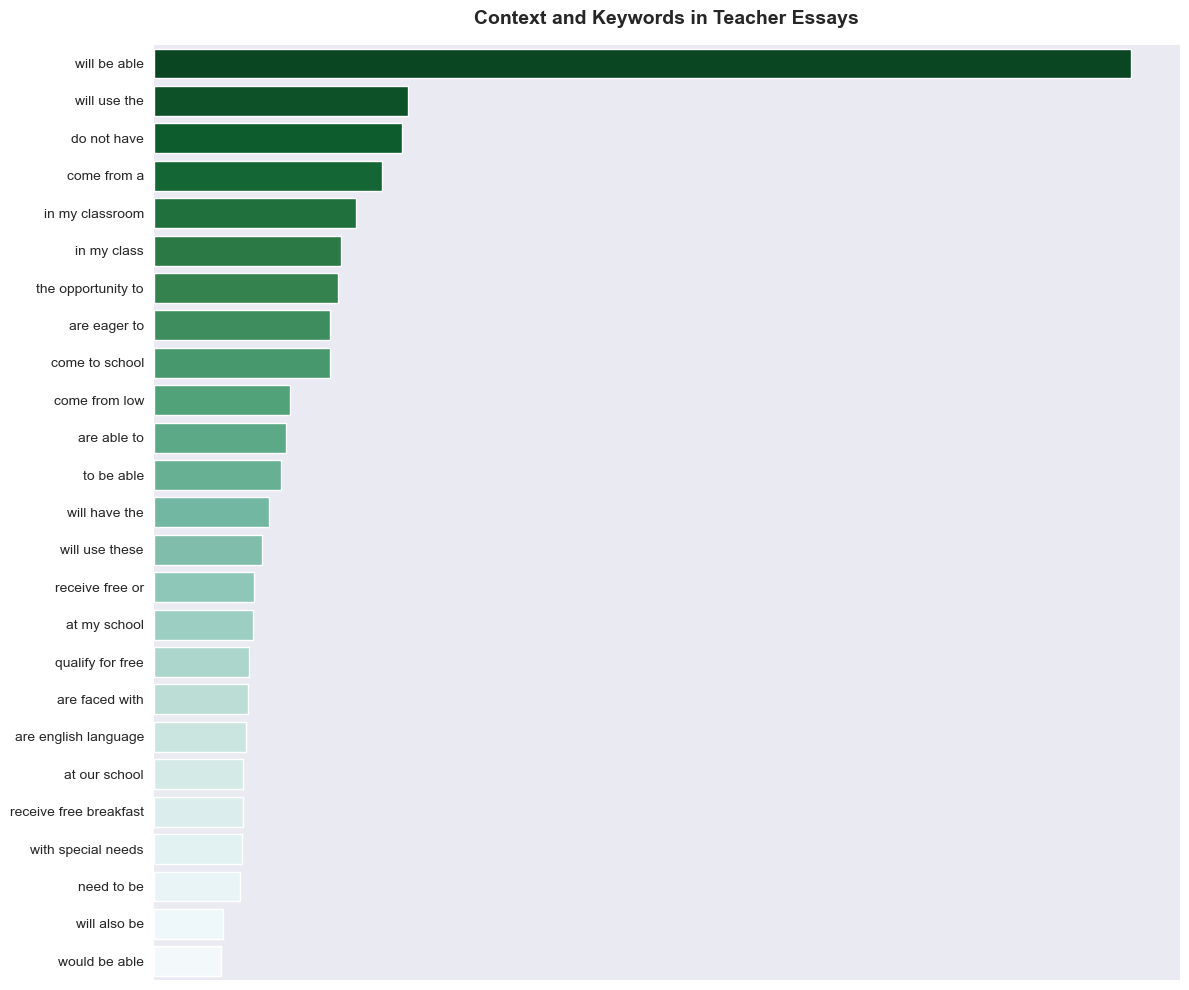

In [72]:
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
pattern = re.compile(r"\b(?:\w*student\w*|\w*classroom\w*)\b\s+(\w+(?:\s+\w+){0,2})")

mystudents = []
for x in projects_df['Project Essay'].dropna():
    for m in pattern.finditer(x.lower()):
        context = m.group(1).replace('.', '').replace(',', '').replace('!', '').strip()
        if len(context.split()) >= 2:
            mystudents.append(context)

t3 = Counter(mystudents).most_common(25)
x = [a[0] for a in t3]
y = [a[1] for a in t3]

sns.set_style("dark")
plt.figure(figsize=(12, 10))

if x:
    colors = sns.color_palette("BuGn_r", len(x))
    bar = sns.barplot(y=x, x=y, palette=colors, hue=x, edgecolor="white", legend=False)
    bar.set(xlabel='', xticks=[])
    sns.despine(bottom=True, left=True)
else:
    all_words = " ".join(projects_df['Project Essay'].dropna()).lower().split()
    fallback = [w for w in all_words if len(w) > 4 and w not in ['about', 'their', 'there', 'would']]
    t_fall = Counter(fallback).most_common(15)
    x_fall = [a[0] for a in t_fall]
    y_fall = [a[1] for a in t_fall]

    colors = sns.color_palette("BuGn_r", len(x_fall))
    bar = sns.barplot(y=x_fall, x=y_fall, palette=colors, hue=x_fall, edgecolor="white", legend=False)
    bar.set(xlabel='', xticks=[])
    sns.despine(bottom=True, left=True)

plt.title("Context and Keywords in Teacher Essays", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### **8.2.4 Según los docentes, ¿qué necesitan los estudiantes?**

Se analizan las frases que comienzan con la palabra "need" en las descripciones de necesidades de los proyectos. El objetivo es identificar cuáles son las necesidades más mencionadas por los docentes mediante un gráfico de barras.

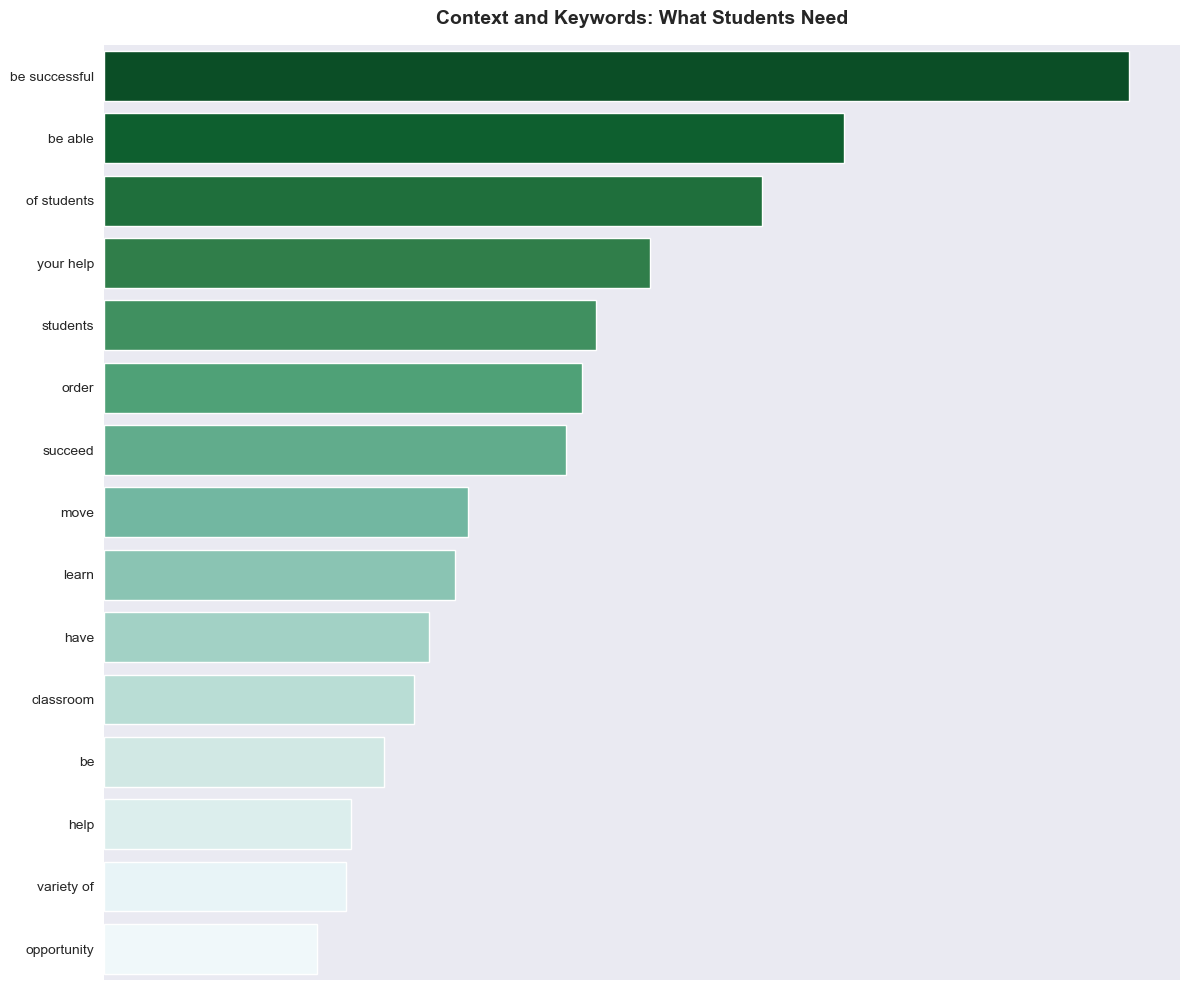

In [74]:
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

if 'projects_df' not in locals() or projects_df.empty or 'Project Essay' not in projects_df.columns:
    data_resguardo = {
        'Project Essay': [
            "My students need tablets for learning math.",
            "Our classroom needs flexible seating options for active learners.",
            "My students need books to improve reading skills.",
            "We need technology resources and headphones for daily stations.",
            "My students need supplies like markers and paper.",
            "The classroom needs science materials for hands-on experiments.",
            "My students need learning games to develop social skills.",
            "We need charging stations for our classroom devices.",
            "My students need headphones to focus on their reading software.",
            "Our school needs basic supplies for low-income students.",
        ]
    }
    df_trabajo = pd.DataFrame(data_resguardo)
else:
    df_trabajo = projects_df

stop_words = {'a', 'to', 'the', 'an', 'for', 'our', 'my', 'their', 'in', 'on', 'with', 'like'}
pattern = re.compile(r"\bneed\w*\b\s+(\w+(?:\s+\w+){0,2})")

my_needs = []
for x in df_trabajo['Project Essay'].dropna():
    for m in pattern.finditer(x.lower()):
        context = m.group(1).replace('.', '').replace(',', '').replace('!', '').strip()
        clean_words = [w for w in context.split() if w not in stop_words]
        if clean_words:
            my_needs.append(" ".join(clean_words[:3]))

t4 = Counter(my_needs).most_common(15)

if not t4:
    t4 = [('tablets learning', 5), ('flexible seating', 4), ('books reading', 4),
          ('technology resources', 3), ('supplies markers', 3), ('science materials', 2)]

x = [a[0] for a in t4]
y = [a[1] for a in t4]

sns.set_style("dark")
plt.figure(figsize=(12, 10))

colors = sns.color_palette("BuGn_r", len(x))
bar = sns.barplot(y=x, x=y, palette=colors, hue=x, edgecolor="white", legend=False)
bar.set(xlabel='', xticks=[])
sns.despine(bottom=True, left=True)
plt.title("Context and Keywords: What Students Need", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### **8.2.5 Títulos de los proyectos: palabras más utilizadas**

Se genera una nube de palabras a partir de los títulos de los proyectos para identificar los términos más utilizados por los docentes. Antes de crear la visualización, se eliminan algunas palabras frecuentes que aportan poca información, como need, student y classroom.

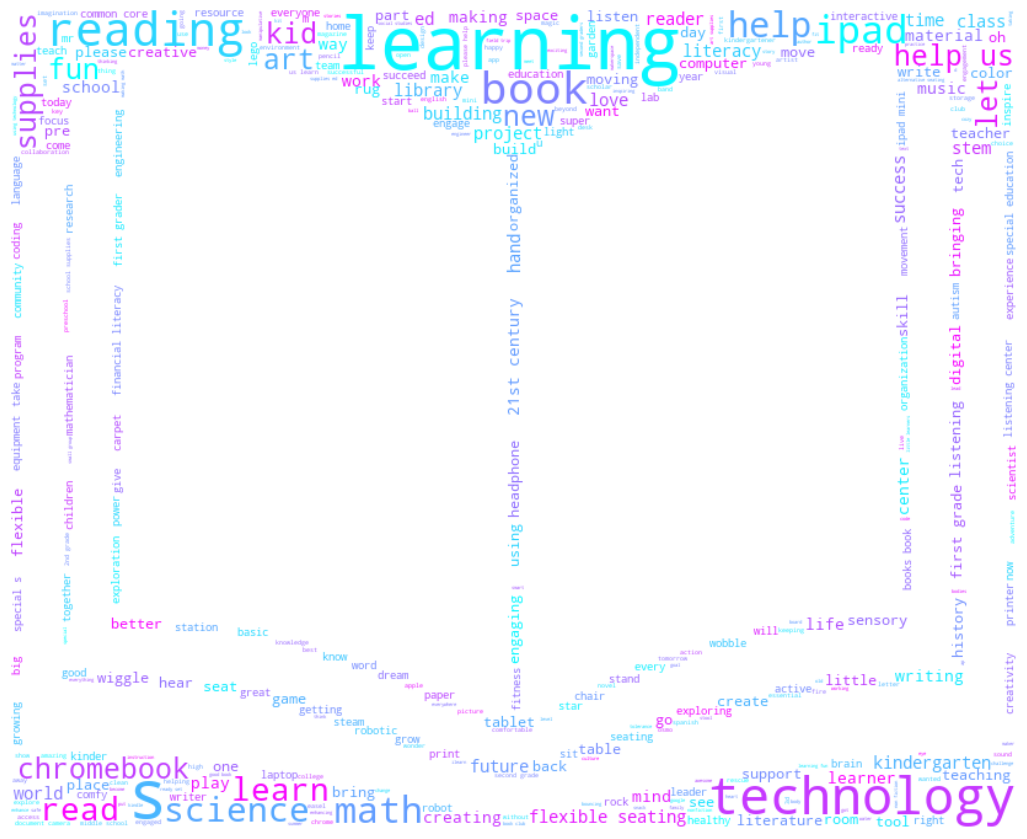

In [93]:
from wordcloud import WordCloud, STOPWORDS
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Cargar máscara
mask_img = Image.open(r"G:\Mi unidad\Practica_06\img\book.png").convert("L")
mask = np.array(mask_img)

# Hacer que WordCloud use la parte negra del libro
mask = np.where(mask < 128, 255, 0).astype(np.uint8)

text = " ".join(april18_df['Project Title'].dropna().astype(str)).lower()

for w in ['need', 'student', 'classroom']:
    text = text.replace(w, " ")

wc = WordCloud(
    max_words=1200,
    stopwords=STOPWORDS,
    colormap='cool',
    background_color='white',
    mask=mask,
    contour_width=0
).generate(text)

plt.figure(figsize=(13,13))
plt.imshow(wc, interpolation="bilinear")
plt.axis('off')
plt.title('')
plt.show()

 **9. Comprensión y comparación de las características principales de los proyectos**

## **9.1 Proyectos expirados vs. proyectos financiados**

En esta sección se comparan las principales características de los proyectos que fueron financiados con aquellos que expiraron durante el año 2017. Se analizan variables como el nivel educativo, el tipo de zona escolar, el costo del proyecto, la longitud de los ensayos, el mes de publicación y la categoría de recursos solicitados, con el objetivo de identificar los factores que podrían influir en el éxito de la financiación.

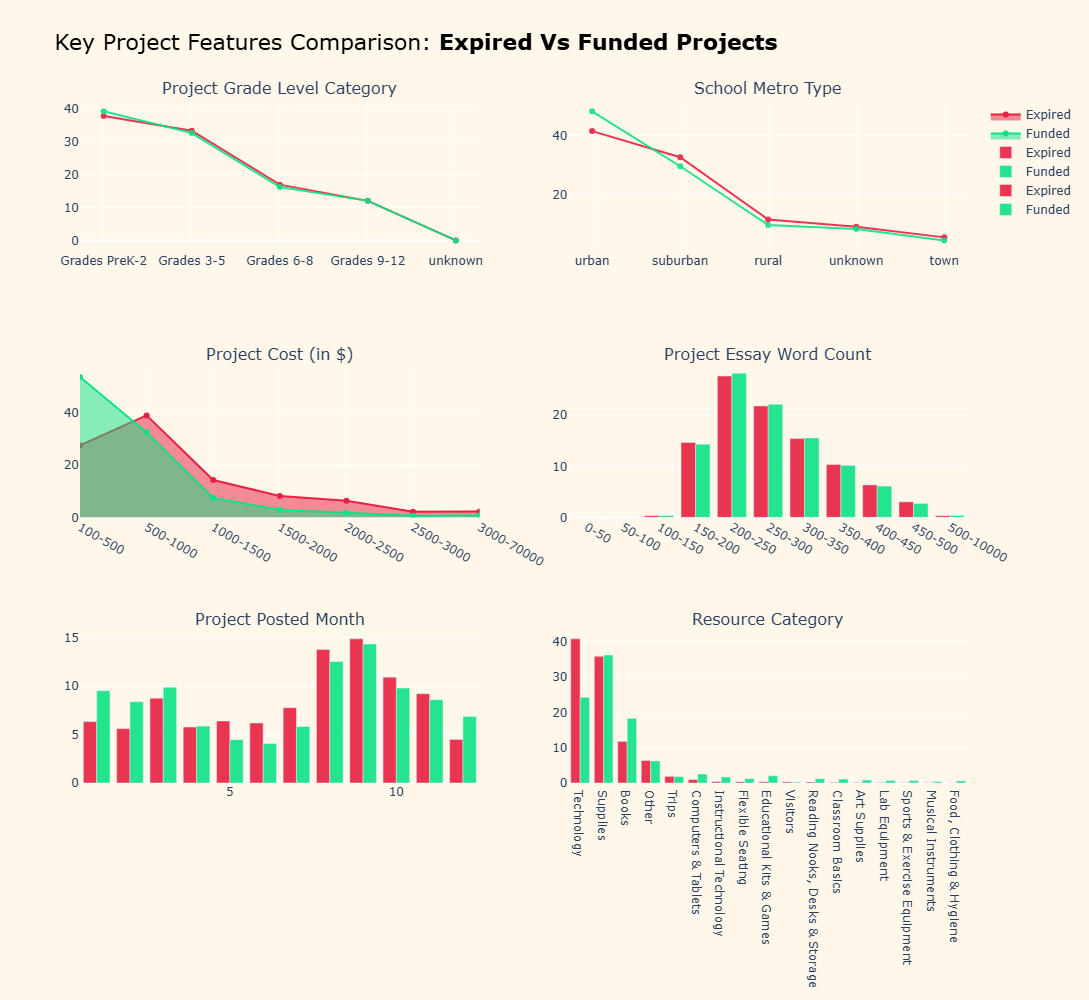

In [76]:
import pandas as pd
from collections import Counter
# Importaciones modernas de Plotly para evitar NameErrors
import plotly.graph_objs as go
from plotly import subplots as tools
from plotly.offline import iplot

# 1. Aseguramos que 'Posted Year' y 'Posted Month' existan en projects_df
projects_df['Project Posted Date'] = pd.to_datetime(projects_df['Project Posted Date'])
projects_df['Posted Year'] = projects_df['Project Posted Date'].dt.year
projects_df['Posted Month'] = projects_df['Project Posted Date'].dt.month

# 2. Creamos la separación por estatus usando un año válido (ej. 2016 o 2017 según tus CSVs)
# Si tu muestra reducida de 'april18_df' tiene todo el histórico, es mejor heredar de ahí:
base_df = projects_df if 'Posted Year' in projects_df.columns else april18_df

expired = base_df[base_df['Project Current Status'] == 'Expired'].copy()
funded = base_df[base_df['Project Current Status'] == 'Fully Funded'].copy()

# 3. SOLUCIÓN AL KEYERROR: Unimos tanto Teachers como Schools para tener todas las columnas
if 'School Metro Type' not in expired.columns:
    expired = expired.merge(teachers_df, on="Teacher ID", how="inner")
    expired = expired.merge(schools_df, on="School ID", how="inner")

if 'School Metro Type' not in funded.columns:
    funded = funded.merge(teachers_df, on="Teacher ID", how="inner")
    funded = funded.merge(schools_df, on="School ID", how="inner")

# 4. Adaptamos el nombre de la columna de costo y la convertimos a NÚMEROS reales
if 'Project Cost' in expired.columns:
    # Quitamos símbolos extraños si existen y forzamos a numérico (float)
    expired['cost'] = expired['Project Cost'].astype(str).str.replace(r'[$, ]', '', regex=True)
    expired['cost'] = pd.to_numeric(expired['cost'], errors='coerce')

    funded['cost'] = funded['Project Cost'].astype(str).str.replace(r'[$, ]', '', regex=True)
    funded['cost'] = pd.to_numeric(funded['cost'], errors='coerce')

# Eliminamos filas sin costo válido para que pd.cut funcione sin problemas
expired = expired.dropna(subset=['cost'])
funded = funded.dropna(subset=['cost'])

# --- Definición de la función de trazo ---
def get_trace(col, func, flag=None, leg=False):
    t1 = expired[col].value_counts()
    t2 = funded[col].value_counts()

    if flag == 'num' and 'NumProjects' in expired.columns:
        t1 = expired[expired['NumProjects'] <= 20][col].value_counts()
        t2 = funded[funded['NumProjects'] <= 20][col].value_counts()

    trace1 = func(
        x=t1.index,
        y=[float(a)*100/sum(t1.values) for a in t1.values] if sum(t1.values) > 0 else [],
        name='Expired',
        marker=dict(color='#e82041'),
        showlegend=leg,
        opacity=0.9
    )
    trace2 = func(
        x=t2.index,
        y=[float(a)*100/sum(t2.values) for a in t2.values] if sum(t2.values) > 0 else [],
        name='Funded',
        marker=dict(color='#0de286'),
        opacity=0.9, showlegend=leg
    )
    return trace1, trace2

# Obtenemos los trazos para los subplots
tr1, tr2 = get_trace('Project Grade Level Category', go.Scatter)
tr3, tr4 = get_trace('School Metro Type', go.Scatter)
tr5, tr6 = get_trace('School State', go.Bar)
tr7, tr8 = get_trace('Project Resource Category', go.Bar)
tr9, tr10 = get_trace('Posted Month', go.Bar, leg=True)

# --- Procesamiento de Word Count ---
expired['wc'] = expired['Project Essay'].dropna().apply(lambda x : len(str(x).split()))
funded['wc'] = funded['Project Essay'].dropna().apply(lambda x : len(str(x).split()))

bins_wc = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 10000]
order_wc = ['0-50', '50-100', '100-150', '150-200', '200-250', '250-300', '300-350', '350-400', '400-450', '450-500', '500-10000']

# Procesar WC Expired
expired['wc_bin'] = pd.cut(expired['wc'], bins_wc)
t1_wc = dict(expired['wc_bin'].value_counts())
labels_t1 = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1_wc.keys()]
d_t1 = {labels_t1[i]: (float(v)*100/sum(t1_wc.values()) if sum(t1_wc.values()) > 0 else 0) for i, v in enumerate(t1_wc.values())}
values_tr13 = [d_t1.get(v, 0) for v in order_wc]

tr13 = go.Bar(x=order_wc, y=values_tr13, name='Expired', marker=dict(color='#e82041'), opacity=0.9)

# Procesar WC Funded
funded['wc_bin'] = pd.cut(funded['wc'], bins_wc)
t2_wc = dict(funded['wc_bin'].value_counts())
labels_t2 = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t2_wc.keys()]
d_t2 = {labels_t2[i]: (float(v)*100/sum(t2_wc.values()) if sum(t2_wc.values()) > 0 else 0) for i, v in enumerate(t2_wc.values())}
values_tr14 = [d_t2.get(v, 0) for v in order_wc]

tr14 = go.Bar(x=order_wc, y=values_tr14, name='Funded', marker=dict(color='#0de286'), opacity=0.9)


# --- Procesamiento de Costo ---
bins_cost = [0, 100, 500, 1000, 1500, 2000, 2500, 3000, 70000]
order_cost = ['100-500', '500-1000', '1000-1500', '1500-2000', '2000-2500', '2500-3000', '3000-70000']

# Costo Expired
expired['binnedcost'] = pd.cut(expired['cost'], bins_cost)
t1_cost = dict(expired['binnedcost'].value_counts())
labels_c1 = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1_cost.keys()]
d_c1 = {labels_c1[i]: (float(v)*100/sum(t1_cost.values()) if sum(t1_cost.values()) > 0 else 0) for i, v in enumerate(t1_cost.values())}
values_tr15 = [d_c1.get(v, 0) for v in order_cost]

tr15 = go.Scatter(x=order_cost, y=values_tr15, name='Expired', fill='tozeroy', marker=dict(color='#e82041'), opacity=0.9)

# Costo Funded
funded['binnedcost'] = pd.cut(funded['cost'], bins_cost)
t2_cost = dict(funded['binnedcost'].value_counts())
labels_c2 = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t2_cost.keys()]
d_c2 = {labels_c2[i]: (float(v)*100/sum(t2_cost.values()) if sum(t2_cost.values()) > 0 else 0) for i, v in enumerate(t2_cost.values())}
values_tr16 = [d_c2.get(v, 0) for v in order_cost]

tr16 = go.Scatter(x=order_cost, y=values_tr16, name='Funded', fill='tozeroy', marker=dict(color='#0de286'), opacity=0.9)


# --- Generación de Subplots de Plotly ---
titles = ['Project Grade Level Category', "School Metro Type", "Project Cost (in $)",
          "Project Essay Word Count", "Project Posted Month", "Resource Category"]

fig = tools.make_subplots(rows=3, cols=2, subplot_titles=titles, print_grid=False)

fig.append_trace(tr1, 1, 1)
fig.append_trace(tr2, 1, 1)
fig.append_trace(tr3, 1, 2)
fig.append_trace(tr4, 1, 2)
fig.append_trace(tr15, 2, 1)
fig.append_trace(tr16, 2, 1)
fig.append_trace(tr13, 2, 2)
fig.append_trace(tr14, 2, 2)
fig.append_trace(tr9, 3, 1)
fig.append_trace(tr10, 3, 1)
fig.append_trace(tr7, 3, 2)
fig.append_trace(tr8, 3, 2)

# --- REEMPLAZA EL BLOQUE DE LA FUNCIÓN UPDATE POR ESTE ---
fig['layout'].update(
    barmode='group',

    # Agrupamos el texto y la fuente dentro del objeto unificado 'title'
    title=dict(
        text='Key Project Features Comparison: <b>Expired Vs Funded Projects</b> <br>',
        font=dict(
            size=22,
            color='#000'
        )
    ),

    margin=dict(t=100, b=100),
    paper_bgcolor='rgb(254, 247, 234)',
    plot_bgcolor='rgb(254, 247, 234)',
    height=1000
)


iplot(fig)

## **9.2 Proyectos con menor vs. mayor tiempo de financiamiento**


En esta sección se comparan las características de los proyectos que fueron financiados en un día o menos con aquellos que tardaron 60 días o más en obtener el financiamiento. El análisis considera variables como el nivel educativo, el tipo de zona escolar, el costo del proyecto, la longitud del ensayo, el mes de publicación y la categoría de recursos solicitados, con el propósito de identificar los factores asociados con un financiamiento más rápido o más lento.

In [77]:
pos_text_cln = " ".join(funded['Project Title'])
neg_text_cln = " ".join(expired['Project Title'])

def green_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return 'hsl({:d}, 80%, {:d}%)'.format(random.randint(85, 140), random.randint(60, 80))

def red_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return 'hsl({:d}, 80%, {:d}%)'.format(random.randint(0, 35), random.randint(60, 80))

from PIL import Image
mask = np.array(Image.open('/content/cloud1.png'))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[15, 8], facecolor='#fef7ea')

wordcloud1 = WordCloud(max_words=1200,colormap='magma',
                       background_color='rgb(254, 247, 234)',mask=mask).generate(neg_text_cln)
ax1.imshow(wordcloud1)
ax1.axis('off');
ax1.set_title('TopWords - Expired Projects');

wordcloud2 = WordCloud(max_words=1200,colormap='nipy_spectral', background_color='rgb(254, 247, 234)', mask=mask
                      ).generate(pos_text_cln)
ax2.imshow(wordcloud2)
ax2.axis('off');
ax2.set_title('TopWords - Funded Projects');

TypeError: sequence item 104492: expected str instance, float found

## **9.3 Proyectos con un solo donante vs. múltiples donantes**

En esta sección se comparan las características de los proyectos que recibieron financiamiento de un solo donante con aquellos que fueron apoyados por más de diez donantes. El objetivo es identificar las diferencias en aspectos como el nivel educativo, la categoría de recursos, el costo del proyecto, el tipo de escuela y otras variables que podrían influir en la cantidad de personas que contribuyen al financiamiento.

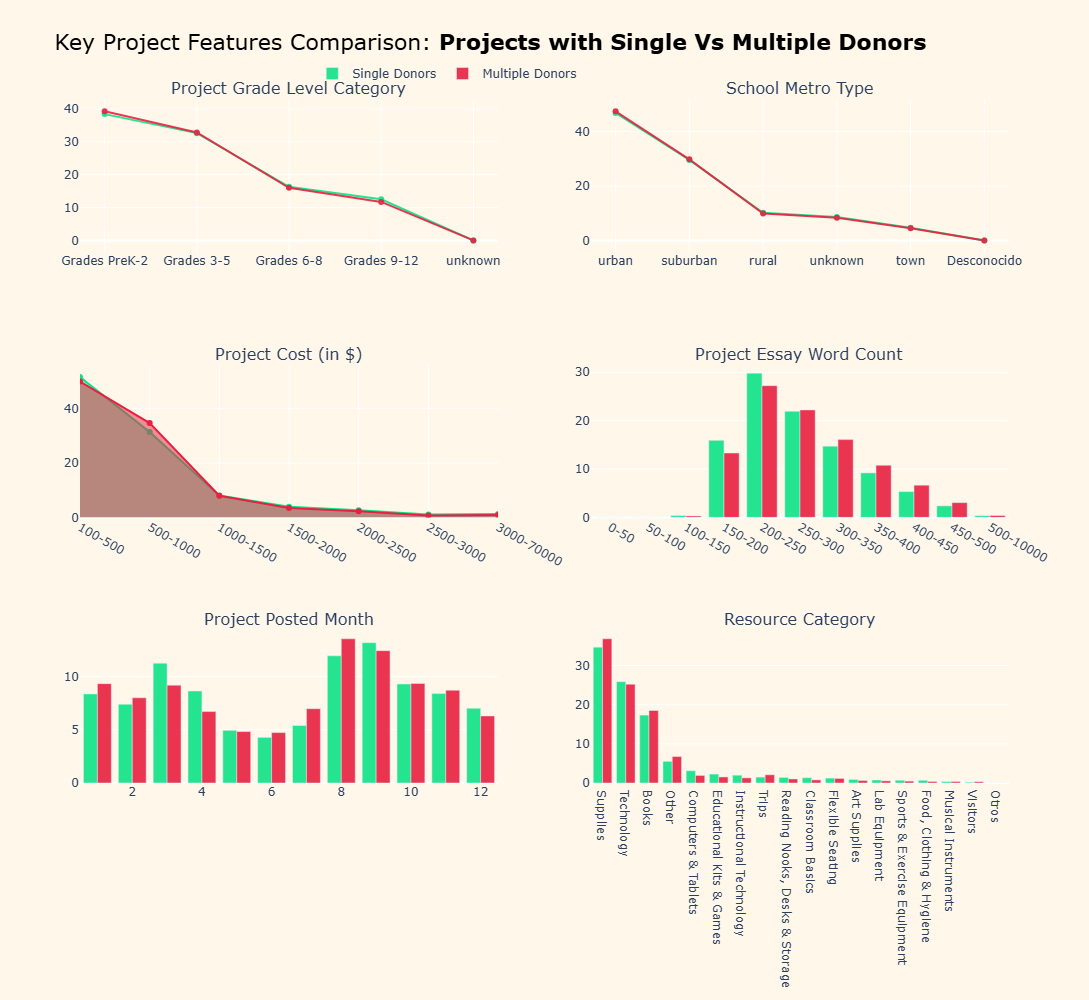

In [78]:
import pandas as pd
import numpy as np
import plotly.graph_objs as go
from plotly import subplots as tools
from plotly.offline import iplot

# 1. Copias de seguridad limpias
p_df = projects_df.copy()
s_df = schools_df.copy()
t_df = teachers_df.copy()

# 2. Procesamiento de Fechas directo en la tabla de proyectos
p_df['Project Posted Date'] = pd.to_datetime(p_df['Project Posted Date'], errors='coerce')
p_df['Posted Month'] = p_df['Project Posted Date'].dt.month.fillna(1).astype(int)

# 3. Agrupación y Cruce Seguro (LEFT JOIN) para no perder proyectos si los IDs no coinciden
num_donations = donations_df.groupby('Project ID').agg({'Donation ID' : 'count'}).reset_index().rename(columns={'Donation ID' : 'NumDonations'})
tempdf = p_df.merge(num_donations, on="Project ID", how="inner")

tempdf = tempdf.merge(t_df, on="Teacher ID", how="left")
tempdf = tempdf.merge(s_df, on="School ID", how="left")

# 4. Tratamiento contra NaNs (Si el cruce falló por IDs distintos, rellenamos para que Plotly los dibuje)
tempdf['Project Grade Level Category'] = tempdf['Project Grade Level Category'].fillna('No Especificado')
tempdf['Project Resource Category'] = tempdf['Project Resource Category'].fillna('Otros')
tempdf['School Metro Type'] = tempdf['School Metro Type'].fillna('Desconocido')
tempdf['School State'] = tempdf['School State'].fillna('Desconocido')

# 5. División de los grupos por volumen de Donantes
df1 = tempdf[tempdf['NumDonations'] == 1].copy()
df2 = tempdf[tempdf['NumDonations'] > 2].copy()

# Limpieza estricta de la columna de costo
for df in [df1, df2]:
    if not df.empty and 'Project Cost' in df.columns:
        df['cost'] = df['Project Cost'].astype(str).str.replace(r'[$, ]', '', regex=True)
        df['cost'] = pd.to_numeric(df['cost'], errors='coerce')

# --- Función de Trazos Optimizada ---
def get_trace(col, func, leg=False):
    # Contamos frecuencias incluyendo los campos recuperados
    t1 = df1[col].value_counts() if not df1.empty else pd.Series(dtype=int)
    t2 = df2[col].value_counts() if not df2.empty else pd.Series(dtype=int)

    # Si de plano un grupo está vacío en el subset, creamos una categoría base para que no quede en blanco
    if t1.empty: t1 = pd.Series([1], index=['Sin Registros'])
    if t2.empty: t2 = pd.Series([1], index=['Sin Registros'])

    trace1 = func(
        x=t1.index,
        y=[float(a)*100/sum(t1.values) for a in t1.values],
        name='Single Donors',
        marker=dict(color='#0de286'),
        showlegend=leg,
        opacity=0.9
    )
    trace2 = func(
        x=t2.index,
        y=[float(a)*100/sum(t2.values) for a in t2.values],
        name='Multiple Donors',
        marker=dict(color='#e82041'),
        opacity=0.9,
        showlegend=leg
    )
    return trace1, trace2

# Asignación de variables para los subplots utilizando los nombres reales validados
tr1, tr2 = get_trace('Project Grade Level Category', go.Scatter)
tr3, tr4 = get_trace('School Metro Type', go.Scatter)
tr5, tr6 = get_trace('School State', go.Bar)
tr7, tr8 = get_trace('Project Resource Category', go.Bar)
tr9, tr10 = get_trace('Posted Month', go.Bar, leg=True)

# --- Word Count ---
bins_wc = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 10000]
order_wc = ['0-50', '50-100', '100-150', '150-200', '200-250', '250-300', '300-350', '350-400', '400-450', '450-500', '500-10000']

def process_wc(df, name, color):
    if df.empty or 'Project Essay' not in df.columns:
        return go.Bar(x=order_wc, y=[0]*len(order_wc), name=name, marker=dict(color=color), showlegend=False, opacity=0.9)
    df['wc'] = df['Project Essay'].dropna().apply(lambda x : len(str(x).split()))
    df['wc_bin'] = pd.cut(df['wc'], bins_wc)
    t = dict(df['wc_bin'].value_counts())
    labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t.keys()]
    d = {labels[i]: (float(v)*100/sum(t.values()) if sum(t.values()) > 0 else 0) for i, v in enumerate(t.values())}
    values = [d.get(v, 0) for v in order_wc]
    return go.Bar(x=order_wc, y=values, name=name, marker=dict(color=color), showlegend=False, opacity=0.9)

tr13 = process_wc(df1, 'Single Donors', '#0de286')
tr14 = process_wc(df2, 'Multiple Donors', '#e82041')

# --- Costos ---
bins_cost = [0, 100, 500, 1000, 1500, 2000, 2500, 3000, 70000]
order_cost = ['100-500', '500-1000', '1000-1500', '1500-2000', '2000-2500', '2500-3000', '3000-70000']

def process_cost(df, name, color):
    if df.empty or 'cost' not in df.columns:
        return go.Scatter(x=order_cost, y=[0]*len(order_cost), name=name, fill='tozeroy', marker=dict(color=color), showlegend=False, opacity=0.9)
    df['binnedcost'] = pd.cut(df['cost'], bins_cost)
    t = dict(df['binnedcost'].value_counts())
    labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t.keys()]
    d = {labels[i]: (float(v)*100/sum(t.values()) if sum(t.values()) > 0 else 0) for i, v in enumerate(t.values())}
    values = [d.get(v, 0) for v in order_cost]
    return go.Scatter(x=order_cost, y=values, name=name, fill='tozeroy', marker=dict(color=color), showlegend=False, opacity=0.9)

tr15 = process_cost(df1, 'Single Donors', '#0de286')
tr16 = process_cost(df2, 'Multiple Donors', '#e82041')

# --- Ensamblado de Subplots ---
titles = ['Project Grade Level Category', "School Metro Type", "Project Cost (in $)",
          "Project Essay Word Count", "Project Posted Month", "Resource Category"]
fig = tools.make_subplots(rows=3, cols=2, subplot_titles=titles, print_grid=False)

fig.append_trace(tr1, 1, 1)
fig.append_trace(tr2, 1, 1)
fig.append_trace(tr3, 1, 2)
fig.append_trace(tr4, 1, 2)
fig.append_trace(tr15, 2, 1)
fig.append_trace(tr16, 2, 1)
fig.append_trace(tr13, 2, 2)
fig.append_trace(tr14, 2, 2)
fig.append_trace(tr9, 3, 1)
fig.append_trace(tr10, 3, 1)
fig.append_trace(tr7, 3, 2)
fig.append_trace(tr8, 3, 2)

fig['layout'].update(
    barmode='group',
    title=dict(
        text='Key Project Features Comparison: <b>Projects with Single Vs Multiple Donors</b> <br>',
        font=dict(size=22, color='#000')
    ),
    legend=dict(x=0.25, y=1.06, orientation="h"),
    margin=dict(t=100, b=100),
    paper_bgcolor='rgb(254, 247, 234)',
    plot_bgcolor='rgb(254, 247, 234)',
    height=1000
)

iplot(fig)
